# Decoupling Model and Scaffold Performance

## Research Questions

1. **Decomposition:** How much of an agent's performance is attributable to the model vs. the scaffold vs. their interaction?
2. **First-party advantage:** Do model developers (OpenAI, Anthropic) have an advantage building scaffolds for their own models?
3. **Scaffold effect:** Same model, different scaffolds — how much does performance differ, and on which tasks?
4. **Model effect:** Same scaffold, different models — how much does performance differ, and on which tasks?
5. **Crossovers:** Can a better scaffold compensate for a weaker model? When and why?
6. **Failure modes:** Do different scaffolds/models fail differently? (error types, written vs vision, efficiency)
7. **Leaderboards:** Should leaderboards report model-scaffold pairs instead of just models?

In [35]:
import json
import os
from pathlib import Path
import re, math, copy, warnings, hashlib, time, textwrap
from collections import Counter, defaultdict
from dotenv import load_dotenv
from docent import Docent

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

from adjustText import adjust_text
import seaborn as sns
# define mpatches


from scipy import stats as sp_stats
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar
import statsmodels.api as sm
from statsmodels.formula.api import ols

load_dotenv()

DATA_DIR = Path("data")
FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 100)

In [36]:
# plot style config 
sns.set_theme(
    context="paper",
    style="white",
    palette="colorblind",
    font="Times New Roman",
)

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.titleweight": 500,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

SCAFFOLD_COLORS = {
    "Codex CLI":    "#0173b2",
    "Claude Code":  "#de8f05",
    "OpenCode":     "#029e73",
    "CORE-Agent":   "#cc78bc",
}
HEATMAP_CMAP = "viridis"
DIVERGING_CMAP = "RdYlGn"

def savefig(name):
    plt.savefig(FIGDIR / name)

## Helper Functions

In [37]:
# Parse scaffold string into components
def parse_scaffold(s: str) -> dict:
    if s.startswith("Codex Agent"):
        family = "Codex CLI"
    elif s.startswith("Claude Code"):
        family = "Claude Code"
    elif s.startswith("Open Code"):
        family = "OpenCode"
    elif s.startswith("Core Agent"):
        family = "CORE-Agent"
    else:
        family = s.split("(")[0].strip()

    # extract reasoning
    re_val = "default"
    if "re=" in s:
        re_val = s.split("re=")[1].split(",")[0].split(")")[0]
    elif "think=" in s:
        re_val = "think=" + s.split("think=")[1].split(",")[0].split(")")[0]

    # extract max threads (subagents)
    mt_val = None
    if "mt=" in s:
        mt_val = int(s.split("mt=")[1].split(",")[0].split(")")[0])

    # extract max steps
    steps_val = None
    if "steps=" in s:
        steps_val = int(s.split("steps=")[1].split(",")[0].split(")")[0])

    return {"scaffold_family": family, "reasoning_effort": re_val,
            "max_threads": mt_val, "steps": steps_val}

# Clean config labels
def make_config_label(row):
    parts = [row["scaffold_family"], row["model_clean"]]
    if row["reasoning_effort"] not in ("default", None):
        parts.append(row["reasoning_effort"])
    if pd.notna(row.get("max_threads")):
        parts.append(f"mt={int(row['max_threads'])}")
    if pd.notna(row.get("steps")):
        parts.append(f"steps={int(row['steps'])}")
    return " / ".join(parts)

def compare_paired(df, config_a, config_b, capsule_col="capsule_id"):
    """McNemar's test for two configs on the same capsules."""
    a = df[df["config"] == config_a].set_index(capsule_col)["accuracy"]
    b = df[df["config"] == config_b].set_index(capsule_col)["accuracy"]
    merged = pd.DataFrame({"a": a, "b": b}).dropna()
    # Contingency: a_right_b_wrong, a_wrong_b_right
    a1_b0 = ((merged["a"] == 1) & (merged["b"] == 0)).sum()
    a0_b1 = ((merged["a"] == 0) & (merged["b"] == 1)).sum()
    if a1_b0 + a0_b1 == 0:
        return None
    result = mcnemar([[0, a1_b0], [a0_b1, 0]], exact=True)
    return {"a1_b0": a1_b0, "a0_b1": a0_b1, "p_value": result.pvalue}
from dotenv import load_dotenv

## Load Dataset

In [38]:
with open(DATA_DIR / "raw_transcripts.json") as f:
    rows_all = json.load(f)
print(f"Loaded {len(rows_all)} runs")

Loaded 780 runs


### Transform the data

In [39]:
def rows_to_df(rows: list[dict]) -> pd.DataFrame:
    records = []
    for row in rows:
        meta = row.get("transcript_metadata", row.get("agent_run_metadata", {}))
        scores = meta.get("scores", {})
        scoring = meta.get("scoring_metadata", {}) or {}
        records.append({
            "agent_run_id": row["agent_run_id"],
            "model": meta.get("model", "unknown"),
            "scaffold": meta.get("scaffold", "unknown"),
            "capsule_id": meta.get("capsule_id", ""),
            "accuracy": scores.get("accuracy", None),
            "message_count": meta.get("message_count", None),
            "source": meta.get("source", ""),
            "correct_written": scoring.get("correct_written_answers", None),
            "total_written": scoring.get("total_written_questions", None),
            "correct_vision": scoring.get("correct_vision_answers", None),
            "total_vision": scoring.get("total_vision_questions", None),
            "error": scoring.get("error", None),
        })
    return pd.DataFrame(records)

df = rows_to_df(rows_all)
print(f"Shape: {df.shape}")
print(f"Capsules: {df['capsule_id'].nunique()}, Scaffolds: {df['scaffold'].nunique()}")

Shape: (780, 12)
Capsules: 39, Scaffolds: 20


In [40]:
parsed = pd.DataFrame([parse_scaffold(s) for s in df["scaffold"]])
df = pd.concat([df, parsed], axis=1)

# Normalize model and provider names
df["model_clean"] = df["model"].str.replace("anthropic/", "").str.replace("openai/", "")
df["model_provider"] = df["model_clean"].apply(lambda m: "Anthropic" if "claude" in m or "opus" in m else "OpenAI")

df["config"] = df.apply(make_config_label, axis=1)
# print before and after examples to verify parsing and label construction
print("Example scaffolds:", df["scaffold"].unique()[:5])
print("Example configs:", df["config"].unique()[:5])

Example scaffolds: <StringArray>
['Claude Code (anthropic/claude-opus-4-5, think=10000)',
                     'Codex Agent (gpt-5.2, re=medium)',
                  'Open Code (openai/gpt-5.4, re=high)',
               'Codex Agent (gpt-5.3-codex, re=medium)',
                        'Codex Agent (gpt-5.4, re=low)']
Length: 5, dtype: str
Example configs: <StringArray>
['Claude Code / claude-opus-4-5 / think=10000',
                'Codex CLI / gpt-5.2 / medium',
                   'OpenCode / gpt-5.4 / high',
          'Codex CLI / gpt-5.3-codex / medium',
                   'Codex CLI / gpt-5.4 / low']
Length: 5, dtype: str


In [41]:
# Derived fields
df["has_error"] = df["error"].notna() & (df["error"] != "")
df["has_vision"] = df["total_vision"] > 0
df["has_written"] = df["total_written"] > 0

In [42]:
MODEL_DISPLAY = {
    "gpt-5": "GPT-5",
    "gpt-5.1": "GPT-5.1",
    "gpt-5.2": "GPT-5.2",
    "gpt-5.3-codex": "GPT-5.3-Codex",
    "gpt-5.4": "GPT-5.4",
    "claude-opus-4-5": "Claude Opus 4.5",
    "claude-opus-4-6": "Claude Opus 4.6",
}

df["model_display"] = df["model_clean"].map(MODEL_DISPLAY).fillna(df["model_clean"])

In [43]:
assert df["capsule_id"].nunique() == 39, f"Expected 39 capsules, got {df['capsule_id'].nunique()}"
print(f"Loaded {len(df)} runs across {df['config'].nunique()} configurations")

# Create a "default config" subset: drop subagent sweep variants to avoid double-counting
# Keep mt=None (default) and drop explicit mt=1,3,6,9 for the cross-scaffold analyses
df_default = df[df["max_threads"].isna()].copy()
print(f"Default configs (no subagent variants): {len(df_default)} runs, {df_default['config'].nunique()} configs")
print(f"Configs in default set: {df_default['scaffold_family'].nunique()}")

# Also create the full set for Codex-internal analyses
# what does this one include? 
df_codex_full = df[df["scaffold_family"] == "Codex CLI"].copy()
print(f"All Codex CLI runs (incl. sweeps): {len(df_codex_full)} runs")
print(f"Configs in Codex CLI subset: {df_codex_full['config'].nunique()}")

Loaded 780 runs across 20 configurations
Default configs (no subagent variants): 624 runs, 16 configs
Configs in default set: 4
All Codex CLI runs (incl. sweeps): 468 runs
Configs in Codex CLI subset: 12


In [44]:
# Canonical-config slice: one row per (capsule, model, scaffold_family) cell.
# Comparison frame: each (model, scaffold) pair is represented by ONE configuration
#
# from df_default (already drops subagent variants), within each (model, scaffold_family) cell that has multiple reasoning_effort values, keep
# only re=medium
# Cells with a single reasoning_effort pass through unchanged.

re_counts = df_default.groupby(["model_clean", "scaffold_family"])["reasoning_effort"].nunique()
multi_re_cells = set(re_counts[re_counts > 1].index)

def _is_multi_re(row):
    return (row["model_clean"], row["scaffold_family"]) in multi_re_cells

mask_multi = df_default.apply(_is_multi_re, axis=1)
mask_keep = (~mask_multi) | (df_default["reasoning_effort"] == "medium")
df_canonical = df_default[mask_keep].copy().reset_index(drop=True)
print(f"Canonical configs: {len(df_canonical)} runs across "
      f"{df_canonical.groupby(['model_clean','scaffold_family']).ngroups} (model,scaffold) cells")
# Sanity: every (model, scaffold, capsule) triple appears exactly once
assert df_canonical.groupby(["model_clean", "scaffold_family", "capsule_id"]).size().max() == 1, \
    "df_canonical is not unique per (model, scaffold, capsule)"
print("Per-cell counts (should all be 39):")
print(df_canonical.groupby(["model_clean","scaffold_family"]).size().to_string())


Canonical configs: 507 runs across 13 (model,scaffold) cells
Per-cell counts (should all be 39):
model_clean      scaffold_family
claude-opus-4-5  CORE-Agent         39
                 Claude Code        39
                 OpenCode           39
claude-opus-4-6  CORE-Agent         39
                 Claude Code        39
                 OpenCode           39
gpt-5            Codex CLI          39
gpt-5.1          Codex CLI          39
gpt-5.2          Codex CLI          39
gpt-5.3-codex    Codex CLI          39
gpt-5.4          CORE-Agent         39
                 Codex CLI          39
                 OpenCode           39


In [45]:
def print_unique_counts(df_in, exclude_contains=("message",), max_values=100):
    """
    Print unique values and counts for each column in a DataFrame.

    exclude_contains skips columns whose names contain any listed substring.
    max_values prevents huge high-cardinality columns from flooding output.
    """
    for col in df_in.columns:
        col_lower = col.lower()
        if any(token.lower() in col_lower for token in exclude_contains):
            continue

        counts = df_in[col].value_counts(dropna=False)

        print("=" * 80)
        print(f"{col}  |  unique={df_in[col].nunique(dropna=False)}  |  rows={len(df_in)}")

        if len(counts) > max_values:
            print(f"Too many unique values ({len(counts)}); showing top {max_values}:")
            print(counts.head(max_values).to_string())
        else:
            print(counts.to_string())

    print("=" * 80)

In [46]:
print_unique_counts(df_default)

agent_run_id  |  unique=624  |  rows=624
Too many unique values (624); showing top 100:
agent_run_id
eb32af3a-7b6a-4cf8-8153-66764caa612f    1
41e88ef2-ef0e-49bf-ba13-824fbdfffc7c    1
3247c4d9-4120-4609-8072-7dd65525ee85    1
86c0172a-a203-4857-a44e-0d64359cc20c    1
64f6cb7d-c258-4c92-a409-faf624acc42d    1
ff9917a2-7ed3-460d-ad6d-d14cb6c387d0    1
7534dca5-9abd-4e74-b395-08b7c8d82597    1
84755140-4317-45e3-ac8c-12b477d2c27e    1
c9e8b10c-e011-4e34-8407-ea413cd9a126    1
92915570-d46d-4650-b5e2-6efb8d87d566    1
5894340f-62f7-45dc-82bb-bb8bd1323c01    1
490344fd-37ca-4e12-967b-992d3da6bcbd    1
a6f1bfea-6770-4afc-9585-7ca69881bd2f    1
11824a55-a202-48e8-9560-bfff6ade9f09    1
a21e57a1-eae6-4ee8-bf8f-b870dd83ccb9    1
33de85b8-5091-4c5e-9785-4556214984c9    1
668eb2ff-7b68-43ec-9027-dd0dafdaa37e    1
9273806c-b86f-48af-8a1c-84d513a159af    1
6cfca948-30b9-429b-8564-3a9102b132af    1
58e97247-3aa0-4ba6-b481-761f2569c24a    1
b243e862-e36a-43a8-ab2d-7e620cbcac95    1
6c735729-7631-4c2

In [47]:
df_default = df[df["max_threads"].isna()].copy()

## create Focus DF

In [48]:
# Decoupling-analysis focus slice
# 10 (model, scaffold) cells: 3 models on Core Agent + Open Code, plus each model on its
# first-party scaffold. gpt-5.4 appears twice on Codex Agent (re=medium and re=high) so
# cross-scaffold pairs stay matched on reasoning effort:
#   - Core Agent (gpt-5.4)        ↔ Codex Agent (gpt-5.4, re=medium)   [both medium]
#   - Open Code (openai/gpt-5.4)  ↔ Codex Agent (gpt-5.4, re=high)     [both high]
KEEP = {
    ("anthropic/claude-opus-4-5", "Core Agent (anthropic/claude-opus-4-5, steps=200)"),
    ("anthropic/claude-opus-4-5", "Open Code (anthropic/claude-opus-4-5, think=10000)"),
    ("claude-opus-4-5",           "Claude Code (anthropic/claude-opus-4-5, think=10000)"),
    ("anthropic/claude-opus-4-6", "Core Agent (anthropic/claude-opus-4-6, steps=200)"),
    ("anthropic/claude-opus-4-6", "Open Code (anthropic/claude-opus-4-6)"),
    ("claude-opus-4-6",           "Claude Code (anthropic/claude-opus-4-6)"),
    ("gpt-5.4",                   "Core Agent (gpt-5.4, steps=200)"),
    ("openai/gpt-5.4",            "Open Code (openai/gpt-5.4, re=high)"),
    ("gpt-5.4",                   "Codex Agent (gpt-5.4, re=medium)"),
    ("gpt-5.4",                   "Codex Agent (gpt-5.4, re=high)"),
}

# Normalized reasoning-effort field. parse_scaffold returns "default" for Core Agent gpt-5.4
# (the scaffold string has no re=...) but it was actually run at re=medium — override here.
def _re_effort(model, scaffold):
    if "re=" in scaffold:
        return scaffold.split("re=")[1].split(",")[0].split(")")[0]
    if model == "gpt-5.4" and scaffold.startswith("Core Agent"):
        return "medium"
    return None  # Anthropic — uses think= budget instead, not a comparable axis

df["re_effort"] = df.apply(lambda r: _re_effort(r["model"], r["scaffold"]), axis=1)

df_focus = df[df.set_index(["model", "scaffold"]).index.isin(KEEP)].copy().reset_index(drop=True)

print(f"df_focus: {len(df_focus)} runs across {df_focus.groupby(['model','scaffold']).ngroups} cells")
print("Per-cell counts (should all be 39):")
print(df_focus.groupby(["model", "scaffold", "re_effort"], dropna=False).size().to_string())

df_focus: 390 runs across 10 cells
Per-cell counts (should all be 39):
model                      scaffold                                              re_effort
anthropic/claude-opus-4-5  Core Agent (anthropic/claude-opus-4-5, steps=200)     NaN          39
                           Open Code (anthropic/claude-opus-4-5, think=10000)    NaN          39
anthropic/claude-opus-4-6  Core Agent (anthropic/claude-opus-4-6, steps=200)     NaN          39
                           Open Code (anthropic/claude-opus-4-6)                 NaN          39
claude-opus-4-5            Claude Code (anthropic/claude-opus-4-5, think=10000)  NaN          39
claude-opus-4-6            Claude Code (anthropic/claude-opus-4-6)               NaN          39
gpt-5.4                    Codex Agent (gpt-5.4, re=high)                        high         39
                           Codex Agent (gpt-5.4, re=medium)                      medium       39
                           Core Agent (gpt-5.4, steps=200)    

## Experimental design overview

In [49]:
# which model-scaffold combinations exist?
design = df_default.groupby(["model_clean", "scaffold_family"]).size().unstack(fill_value=0)
print("Experimental design (runs per model x scaffold; configs differ for anything over 39):")
print(design)
print(f"\nTotal cells filled: {(design > 0).sum().sum()} / {design.shape[0] * design.shape[1]} possible")

Experimental design (runs per model x scaffold; configs differ for anything over 39):
scaffold_family  CORE-Agent  Claude Code  Codex CLI  OpenCode
model_clean                                                  
claude-opus-4-5          39           39          0        39
claude-opus-4-6          39           39          0        39
gpt-5                     0            0         39         0
gpt-5.1                   0            0         39         0
gpt-5.2                   0            0         39         0
gpt-5.3-codex             0            0         39         0
gpt-5.4                  39            0        156        39

Total cells filled: 13 / 28 possible


In [50]:
# which models span multiple scaffolds? Which scaffolds span multiple models?
models_across_scaffolds = design.apply(lambda row: (row > 0).sum(), axis=1)
scaffolds_across_models = design.apply(lambda col: (col > 0).sum(), axis=0)

multi_scaffold_models = models_across_scaffolds[models_across_scaffolds > 1].index.tolist()
multi_model_scaffolds = scaffolds_across_models[scaffolds_across_models > 1].index.tolist()

print(f"Models tested on multiple scaffolds: {multi_scaffold_models}")
print(f"Scaffolds tested on multiple models: {multi_model_scaffolds}")
print("Note these models didn't have the same/a static config across scaffolds")
print(f"\nModels only on one scaffold: {models_across_scaffolds[models_across_scaffolds == 1].index.tolist()}")

Models tested on multiple scaffolds: ['claude-opus-4-5', 'claude-opus-4-6', 'gpt-5.4']
Scaffolds tested on multiple models: ['CORE-Agent', 'Claude Code', 'Codex CLI', 'OpenCode']
Note these models didn't have the same/a static config across scaffolds

Models only on one scaffold: ['gpt-5', 'gpt-5.1', 'gpt-5.2', 'gpt-5.3-codex']


## Accuracy

In [51]:
# Accuracy per config with Wilson CIs
config_stats = []
for config, grp in df_default.groupby("config"):
    n = len(grp)
    k = int(grp["accuracy"].sum())
    acc = k / n
    lo, hi = proportion_confint(k, n, method="wilson")
    config_stats.append({
        "config": config,
        "scaffold_family": grp["scaffold_family"].iloc[0],
        "model_clean": grp["model_clean"].iloc[0],
        "model_provider": grp["model_provider"].iloc[0],
        "reasoning_effort": grp["reasoning_effort"].iloc[0],
        "n": n,
        "correct": k,
        "accuracy": acc,
        "ci_lo": lo,
        "ci_hi": hi,
        "msg_mean": grp["message_count"].mean(),
        "msg_median": grp["message_count"].median(),
        "error_rate": grp["has_error"].mean(),
    })

df_configs = pd.DataFrame(config_stats).sort_values("accuracy", ascending=False).reset_index(drop=True)

df_configs_print = df_configs.copy()

df_configs_print["acc"] = df_configs_print.apply(
    lambda r: f"{r['correct']}/{r['n']} ({r['accuracy']:.1%})",
    axis=1,
)
df_configs_print["95% CI"] = df_configs_print.apply(
    lambda r: f"[{r['ci_lo']:.1%}, {r['ci_hi']:.1%}]",
    axis=1,
)
df_configs_print["msg_mean"] = df_configs_print["msg_mean"].round(0).astype(int)
df_configs_print["error_rate"] = df_configs_print["error_rate"].map(lambda x: f"{x:.1%}")
print("Configuration accuracy over 39 capsules; Wilson 95% CI")

print(
    df_configs_print[
        ["config", "acc", "95% CI", "msg_mean", "error_rate"]
    ].to_string(index=False)
)

Configuration accuracy over 39 capsules; Wilson 95% CI
                                     config           acc         95% CI  msg_mean error_rate
   CORE-Agent / claude-opus-4-6 / steps=200 38/39 (97.4%) [86.8%, 99.5%]        93       0.0%
         Codex CLI / gpt-5.3-codex / medium 38/39 (97.4%) [86.8%, 99.5%]        55       0.0%
                 Codex CLI / gpt-5.4 / high 38/39 (97.4%) [86.8%, 99.5%]        85       0.0%
                Codex CLI / gpt-5.4 / xhigh 38/39 (97.4%) [86.8%, 99.5%]        90       0.0%
               Codex CLI / gpt-5.2 / medium 37/39 (94.9%) [83.1%, 98.6%]        97       0.0%
               Codex CLI / gpt-5.4 / medium 37/39 (94.9%) [83.1%, 98.6%]        74       0.0%
                  Codex CLI / gpt-5.4 / low 36/39 (92.3%) [79.7%, 97.3%]        64       0.0%
Claude Code / claude-opus-4-5 / think=10000 35/39 (89.7%) [76.4%, 95.9%]       129       7.7%
              Claude Code / claude-opus-4-6 35/39 (89.7%) [76.4%, 95.9%]        91       5.1%
     

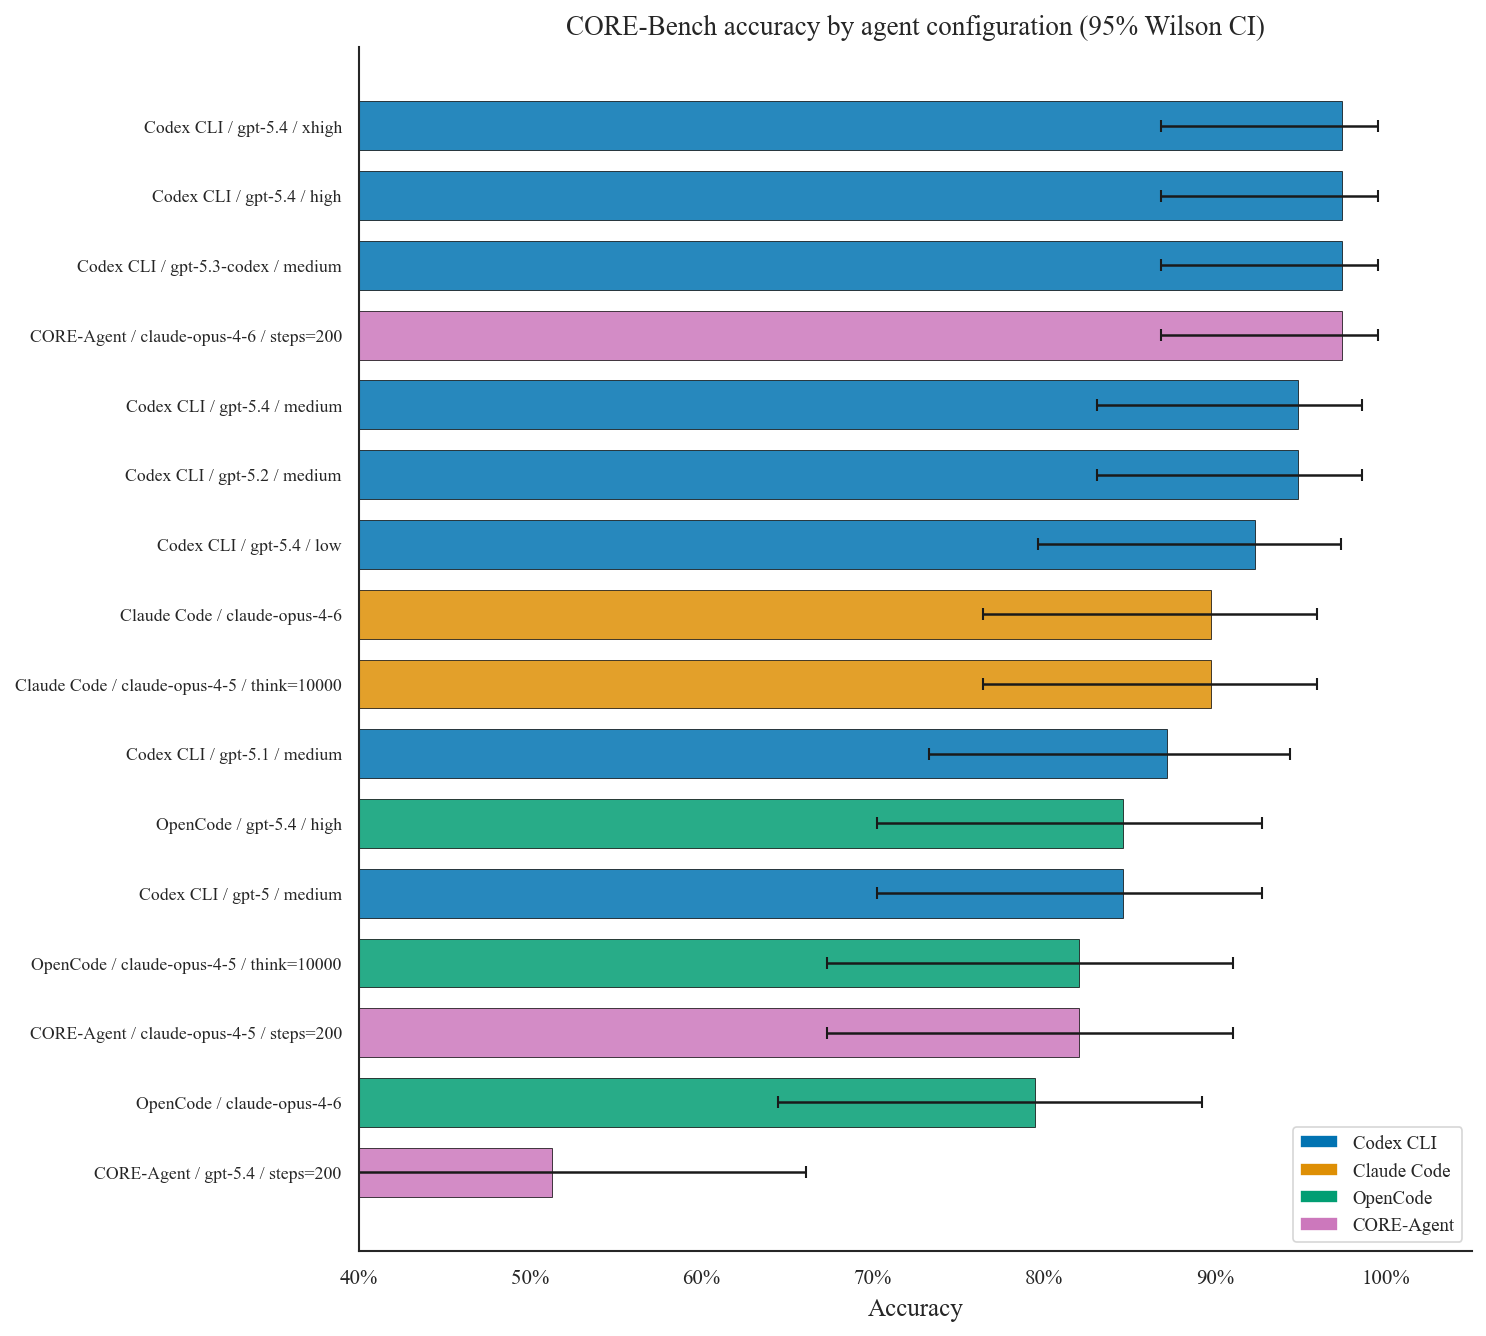

In [52]:
df_plot = df_configs.sort_values("accuracy", ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, len(df_plot) * 0.5 + 1))

colors = [SCAFFOLD_COLORS.get(s, "gray") for s in df_plot["scaffold_family"]]
y = range(len(df_plot))
xerr_lo = df_plot["accuracy"] - df_plot["ci_lo"]
xerr_hi = df_plot["ci_hi"] - df_plot["accuracy"]

ax.barh(y, df_plot["accuracy"], xerr=[xerr_lo, xerr_hi],
        color=colors, alpha=0.85, edgecolor="black", linewidth=0.4, capsize=3, height=0.7)
ax.set_yticks(y)
ax.set_yticklabels(df_plot["config"], fontsize=8.5)
ax.set_xlabel("Accuracy")
ax.set_xlim(0.4, 1.05)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("CORE-Bench accuracy by agent configuration (95% Wilson CI)")

from matplotlib.patches import Patch
legend = [Patch(facecolor=c, label=l) for l, c in SCAFFOLD_COLORS.items()]
ax.legend(handles=legend, loc="lower right", fontsize=9)
plt.tight_layout()
savefig("accuracy_forest.png")
plt.show()

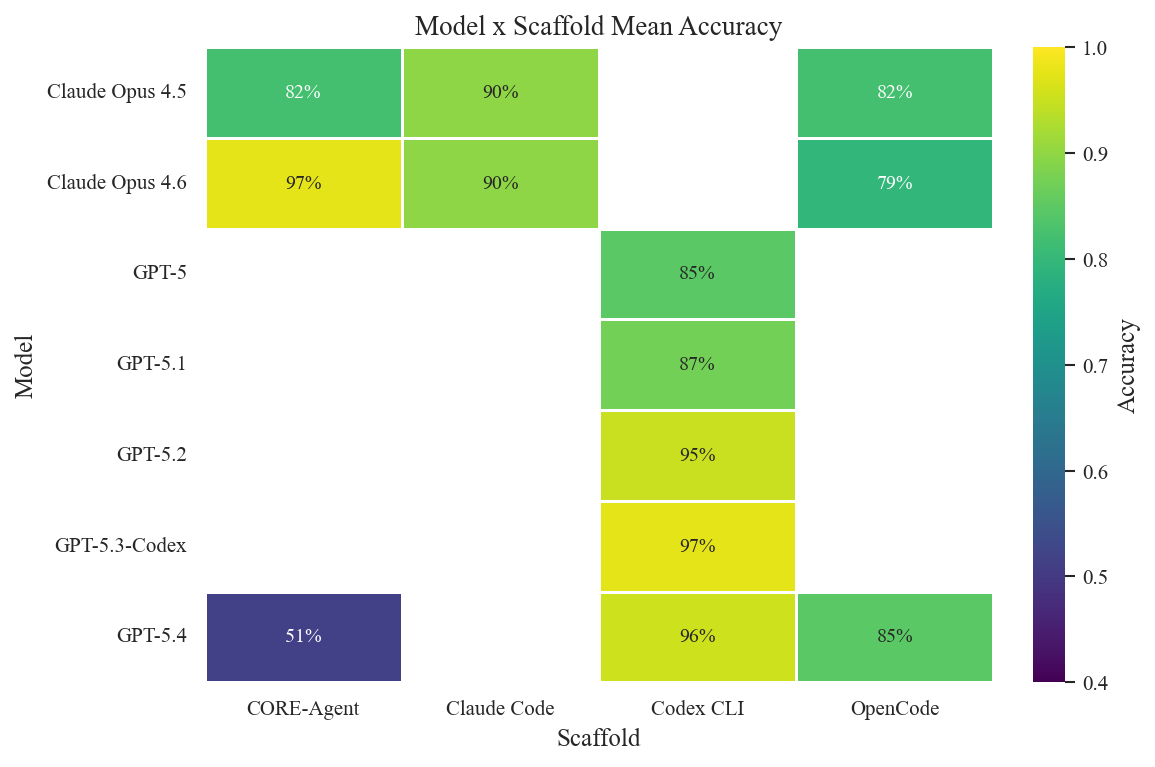

In [53]:
fig, ax = plt.subplots(figsize=(7.6, 5.0), constrained_layout=True)

acc_matrix = df_default.pivot_table(
    index="model_display", columns="scaffold_family", values="accuracy", aggfunc="mean"
)

sns.heatmap(
    acc_matrix, annot=True, fmt=".0%", cmap="viridis",
    vmin=0.4, vmax=1.0, linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Accuracy"}, ax=ax,
)
ax.set_title("Model x Scaffold Mean Accuracy")
ax.set_xlabel("Scaffold")
ax.set_ylabel("Model")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
savefig("accuracy_heatmap.png")
plt.show()

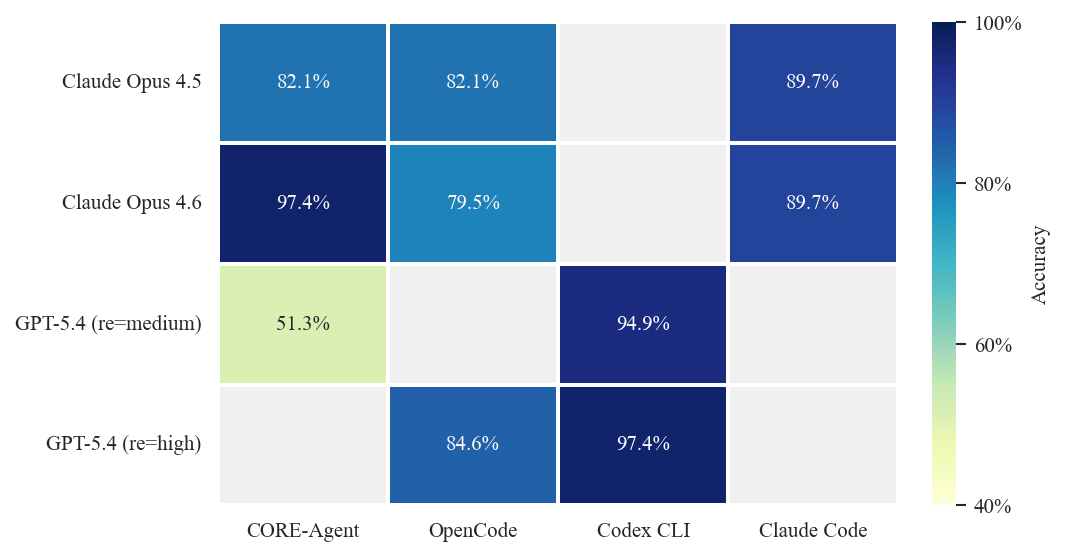

scaffold_family      CORE-Agent  OpenCode  Codex CLI  Claude Code
row_label                                                        
Claude Opus 4.5        0.820513  0.820513        NaN     0.897436
Claude Opus 4.6        0.974359  0.794872        NaN     0.897436
GPT-5.4 (re=medium)    0.512821       NaN   0.948718          NaN
GPT-5.4 (re=high)           NaN  0.846154   0.974359          NaN


In [54]:
def _row_label(model_clean, re_effort):
    base = MODEL_DISPLAY.get(model_clean, model_clean)
    if model_clean == "gpt-5.4":
        return f"{base} (re={re_effort})"
    return base

df_focus_plot = df_focus.copy()
df_focus_plot["row_label"] = df_focus_plot.apply(
    lambda r: _row_label(r["model_clean"], r["re_effort"]), axis=1
)

acc_matrix_focus = df_focus_plot.pivot_table(
    index="row_label", columns="scaffold_family", values="accuracy", aggfunc="mean"
)

row_order = [
    "Claude Opus 4.5",
    "Claude Opus 4.6",
    "GPT-5.4 (re=medium)",
    "GPT-5.4 (re=high)",
]
col_order = ["CORE-Agent", "OpenCode", "Codex CLI", "Claude Code"]
acc_matrix_focus = acc_matrix_focus.reindex(index=row_order, columns=col_order)

annot = acc_matrix_focus.map(lambda x: "N/A" if pd.isna(x) else f"{x:.1%}")

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"]  = ["Times New Roman"]

fig, ax = plt.subplots(figsize=(7.0, 3.6), constrained_layout=True)

sns.heatmap(
    acc_matrix_focus,
    annot=annot,
    fmt="",
    cmap="YlGnBu",
    vmin=0.4, vmax=1.0,
    linewidths=1.0, linecolor="white",
    cbar_kws={
        "label": "Accuracy",
        "ticks": [0.4, 0.6, 0.8, 1.0],
        "format": mticker.PercentFormatter(xmax=1.0, decimals=0),
    },
    ax=ax,
    annot_kws={"fontsize": 10},
)

ax.set_facecolor("#f0f0f0")
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(10)
cbar.ax.tick_params(labelsize=10)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=10, rotation=0, length=0, pad=8)
ax.tick_params(axis="y", labelsize=10, rotation=0, length=0, pad=8)

savefig("accuracy_heatmap_all.png")
plt.show()

print(acc_matrix_focus.to_string())

## Model vs. Scaffold Decomposition

In [55]:
# Effect of SCAFFOLD (holding model constant)
# For each model tested on 2+ scaffolds, how much does scaffold choice swing accuracy?
print("=" * 70)
print("EFFECT OF SCAFFOLD (holding model constant)")
print("=" * 70)

scaffold_effect = []
for model in multi_scaffold_models:
    m_df = df_default[df_default["model_clean"] == model]
    accs = m_df.groupby("scaffold_family")["accuracy"].mean().sort_values(ascending=False)
    spread = accs.max() - accs.min()
    best = accs.idxmax()
    worst = accs.idxmin()
    scaffold_effect.append({
        "model": model, "best_scaffold": best, "best_acc": accs.max(),
        "worst_scaffold": worst, "worst_acc": accs.min(),
        "spread": spread, "n_scaffolds": len(accs),
    })
    print(f"\n  {model} ({len(accs)} scaffolds, spread = {spread:.1%}):")
    for scaffold, acc in accs.items():
        n = len(m_df[m_df["scaffold_family"] == scaffold])
        msg = m_df[m_df["scaffold_family"] == scaffold]["message_count"].mean()
        print(f"    {scaffold:15s}  acc={acc:.1%}  ({int(acc*n)}/{n})  msg_count={msg:.0f}")

scaffold_effect_df = pd.DataFrame(scaffold_effect).sort_values("spread", ascending=False)
print(f"\n\nSummary: scaffold spread per model")
print(scaffold_effect_df.to_string(index=False))

EFFECT OF SCAFFOLD (holding model constant)

  claude-opus-4-5 (3 scaffolds, spread = 7.7%):
    Claude Code      acc=89.7%  (35/39)  msg_count=129
    CORE-Agent       acc=82.1%  (32/39)  msg_count=85
    OpenCode         acc=82.1%  (32/39)  msg_count=47

  claude-opus-4-6 (3 scaffolds, spread = 17.9%):
    CORE-Agent       acc=97.4%  (38/39)  msg_count=93
    Claude Code      acc=89.7%  (35/39)  msg_count=91
    OpenCode         acc=79.5%  (30/39)  msg_count=49

  gpt-5.4 (3 scaffolds, spread = 44.2%):
    Codex CLI        acc=95.5%  (149/156)  msg_count=78
    OpenCode         acc=84.6%  (33/39)  msg_count=44
    CORE-Agent       acc=51.3%  (20/39)  msg_count=36


Summary: scaffold spread per model
          model best_scaffold  best_acc worst_scaffold  worst_acc   spread  n_scaffolds
        gpt-5.4     Codex CLI  0.955128     CORE-Agent   0.512821 0.442308            3
claude-opus-4-6    CORE-Agent  0.974359       OpenCode   0.794872 0.179487            3
claude-opus-4-5   Claude 

In [56]:
# Effect of MODEL (holding scaffold constant)
# For each scaffold tested on 2+ models, how much does model choice swing accuracy?
print("=" * 70)
print("EFFECT OF MODEL (holding scaffold constant)")
print("=" * 70)

model_effect = []
for scaffold in multi_model_scaffolds:
    s_df = df_default[df_default["scaffold_family"] == scaffold]
    accs = s_df.groupby("model_clean")["accuracy"].mean().sort_values(ascending=False)
    spread = accs.max() - accs.min()
    model_effect.append({
        "scaffold": scaffold, "best_model": accs.idxmax(), "best_acc": accs.max(),
        "worst_model": accs.idxmin(), "worst_acc": accs.min(),
        "spread": spread, "n_models": len(accs),
    })
    print(f"\n  {scaffold} ({len(accs)} models, spread = {spread:.1%}):")
    for model, acc in accs.items():
        n = len(s_df[s_df["model_clean"] == model])
        msg = s_df[s_df["model_clean"] == model]["message_count"].mean()
        print(f"    {model:20s}  acc={acc:.1%}  ({int(acc*n)}/{n})  msg_count={msg:.0f}")

model_effect_df = pd.DataFrame(model_effect).sort_values("spread", ascending=False)
print(f"\n\nSummary: model spread per scaffold")
print(model_effect_df.to_string(index=False))

EFFECT OF MODEL (holding scaffold constant)

  CORE-Agent (3 models, spread = 46.2%):
    claude-opus-4-6       acc=97.4%  (38/39)  msg_count=93
    claude-opus-4-5       acc=82.1%  (32/39)  msg_count=85
    gpt-5.4               acc=51.3%  (20/39)  msg_count=36

  Claude Code (2 models, spread = 0.0%):
    claude-opus-4-5       acc=89.7%  (35/39)  msg_count=129
    claude-opus-4-6       acc=89.7%  (35/39)  msg_count=91

  Codex CLI (5 models, spread = 12.8%):
    gpt-5.3-codex         acc=97.4%  (38/39)  msg_count=55
    gpt-5.4               acc=95.5%  (149/156)  msg_count=78
    gpt-5.2               acc=94.9%  (37/39)  msg_count=97
    gpt-5.1               acc=87.2%  (34/39)  msg_count=89
    gpt-5                 acc=84.6%  (33/39)  msg_count=73

  OpenCode (3 models, spread = 5.1%):
    gpt-5.4               acc=84.6%  (33/39)  msg_count=44
    claude-opus-4-5       acc=82.1%  (32/39)  msg_count=47
    claude-opus-4-6       acc=79.5%  (30/39)  msg_count=49


Summary: model sprea

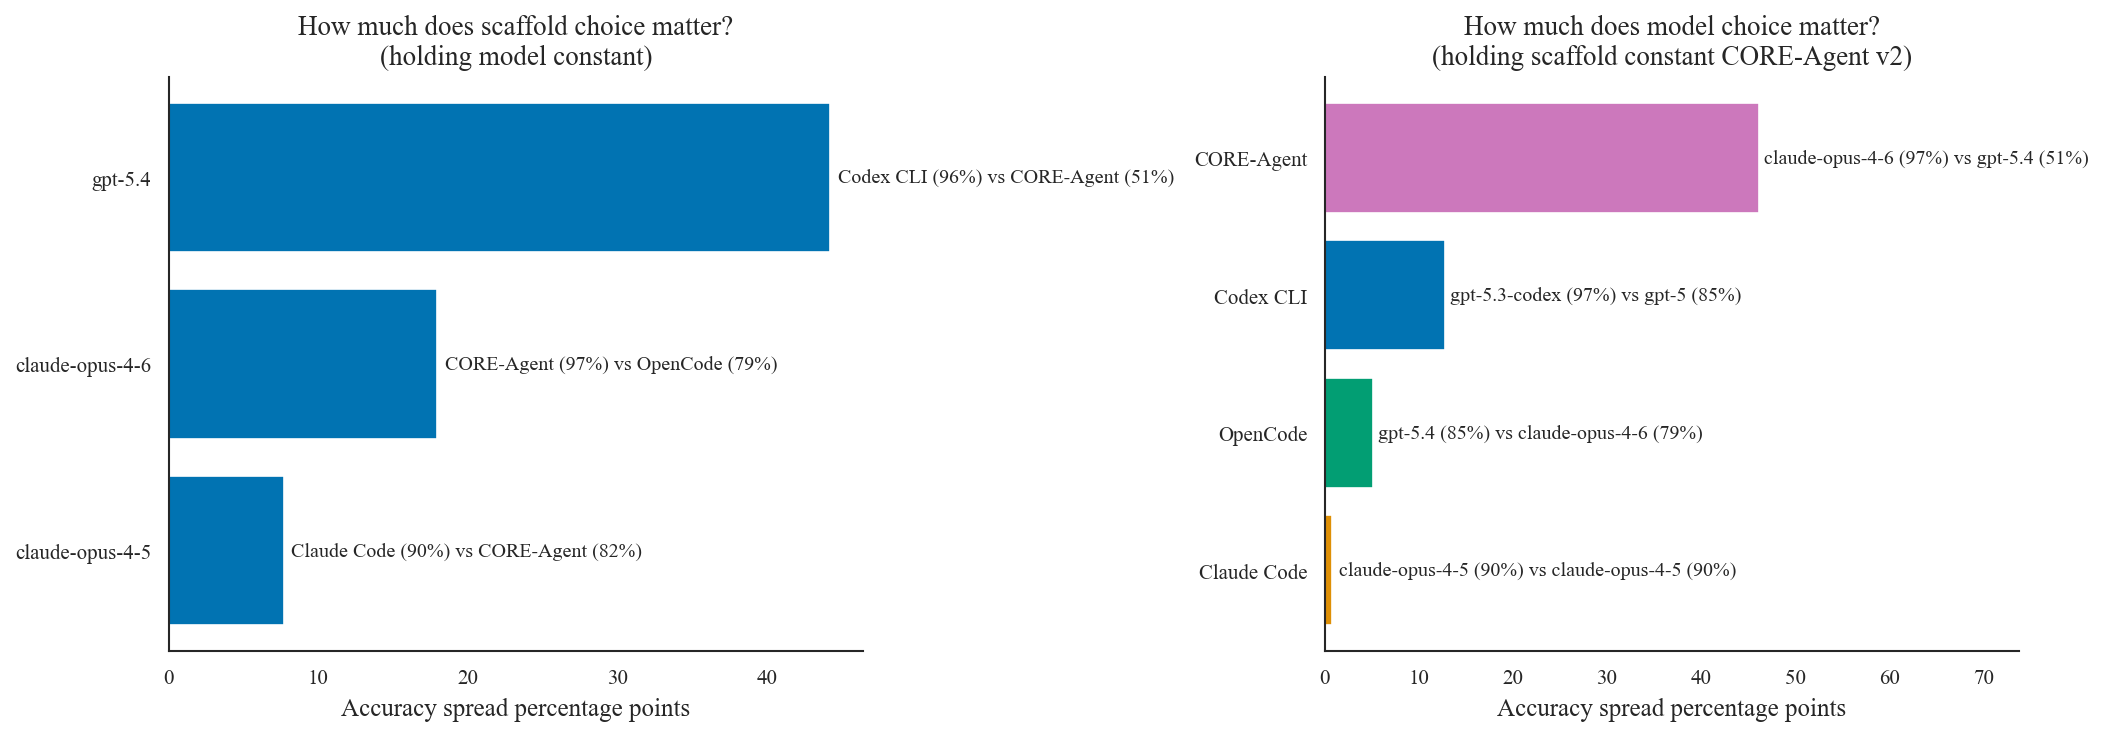

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scaffold effect (left) — single color, not scaffold-coded
se = scaffold_effect_df.sort_values("spread")
axes[0].barh(se["model"], se["spread"] * 100, color="#0173b2")
axes[0].set_xlabel("Accuracy spread percentage points")
axes[0].set_title("How much does scaffold choice matter?\n(holding model constant)")
for i, (_, row) in enumerate(se.iterrows()):
    axes[0].text(
        row["spread"] * 100 + 0.5, i,
        f"{row['best_scaffold']} ({row['best_acc']:.0%}) vs "
        f"{row['worst_scaffold']} ({row['worst_acc']:.0%})",
        va="center",
    )

# Model effect (right) — color by scaffold
# Model effect (right) — color by scaffold
me = model_effect_df.sort_values("spread")
bar_colors = [SCAFFOLD_COLORS.get(s, "gray") for s in me["scaffold"]]
spread_display = me["spread"].apply(lambda x: max(x * 100, 0.8))  # min visible width
axes[1].barh(me["scaffold"], spread_display, color=bar_colors)
# Set a minimum x-axis range so tiny bars and their labels are visible
axes[1].set_xlim(0, max(me["spread"] * 100) * 1.6)
axes[1].set_xlabel("Accuracy spread percentage points")
axes[1].set_title("How much does model choice matter?\n(holding scaffold constant CORE-Agent v2)")
# Move labels for near-zero bars so they're readable
for i, (_, row) in enumerate(me.iterrows()):
    spread_pp = row["spread"] * 100
    axes[1].text(
        max(spread_pp, 1) + 0.5, i,
        f"{row['best_model']} ({row['best_acc']:.0%}) vs "
        f"{row['worst_model']} ({row['worst_acc']:.0%})",
        va="center",
    )
plt.tight_layout()
savefig("model_vs_scaffold_spread.pdf")
plt.show()

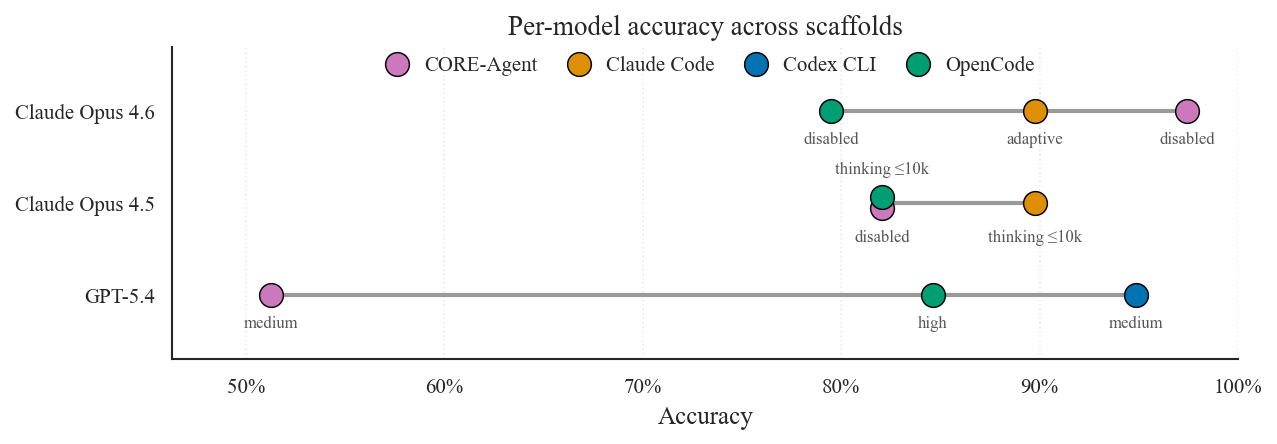

In [58]:
# Per-model accuracy across scaffolds — dots = scaffolds, gray line = best-worst scaffold range.
multi = (
    df_canonical.groupby("model_clean")["scaffold_family"]
    .nunique()
    .pipe(lambda s: s[s >= 2])
    .index
    .tolist()
)

cell_acc = (
    df_canonical[df_canonical["model_clean"].isin(multi)]
    .groupby(["model_clean", "model_display", "scaffold_family"])
    .agg(
        accuracy=("accuracy", "mean"),
        reasoning_effort=("reasoning_effort", "first"),
    )
    .reset_index()
)

spread = (
    cell_acc.groupby(["model_clean", "model_display"])["accuracy"]
    .agg(min_acc="min", max_acc="max", mean_acc="mean")
    .reset_index()
    .sort_values("mean_acc", ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(8.4, max(2.6, 0.95 * len(spread))),
    constrained_layout=True,
)

y_pos = {m: i for i, m in enumerate(spread["model_clean"])}
y_labels = dict(zip(spread["model_clean"], spread["model_display"]))

# Spread bar
for _, r in spread.iterrows():
    ax.hlines(
        y_pos[r["model_clean"]],
        r["min_acc"],
        r["max_acc"],
        color="#9a9a9a",
        linewidth=2,
        zorder=1,
    )

def _re_label(re_eff: str, model_clean: str, scaffold_family: str):
    """Display label for a model/scaffold cell's reasoning/thinking config."""
    if model_clean.startswith("gpt-"):
        if re_eff in {"medium", "high", "low", "xhigh"}:
            return re_eff
        if re_eff == "default":
            return "medium"
        return None

    if model_clean == "claude-opus-4-5":
        if re_eff.startswith("think="):
            try:
                n = int(re_eff.split("=", 1)[1])
                return f"thinking ≤{n // 1000}k" if n >= 1000 else f"thinking ≤{n}"
            except ValueError:
                return re_eff
        if re_eff == "default":
            return "disabled"
        return None

    if model_clean == "claude-opus-4-6":
        if scaffold_family == "Claude Code":
            return "adaptive"
        return "disabled"

    return None

TIE_OFFSET = 0.12
LABEL_GAP = 0.22

row_below_y = {}
row_above_y = {}

for model_clean, mrows in cell_acc.groupby("model_clean"):
    min_dy_row, max_dy_row = 0.0, 0.0

    for _, grp in mrows.groupby(mrows["accuracy"].round(6)):
        n = len(grp)
        if n > 1:
            offs = np.linspace(
                -TIE_OFFSET * (n - 1) / 2,
                TIE_OFFSET * (n - 1) / 2,
                n,
            )
            min_dy_row = min(min_dy_row, float(offs[0]))
            max_dy_row = max(max_dy_row, float(offs[-1]))

    row_below_y[model_clean] = y_pos[model_clean] + min_dy_row - LABEL_GAP
    row_above_y[model_clean] = y_pos[model_clean] + max_dy_row + LABEL_GAP

for model_clean, mrows in cell_acc.groupby("model_clean"):
    mrows = mrows.sort_values("scaffold_family")

    for _, grp in mrows.groupby(mrows["accuracy"].round(6)):
        n = len(grp)
        offsets = [0.0] if n == 1 else np.linspace(
            -TIE_OFFSET * (n - 1) / 2,
            TIE_OFFSET * (n - 1) / 2,
            n,
        )

        for (_, row), dy in zip(grp.iterrows(), offsets):
            ax.scatter(
                row["accuracy"],
                y_pos[model_clean] + dy,
                color=SCAFFOLD_COLORS.get(row["scaffold_family"], "gray"),
                s=130,
                edgecolor="black",
                linewidth=0.7,
                zorder=3,
                label=row["scaffold_family"],
            )

            lbl = _re_label(
                row["reasoning_effort"],
                row["model_clean"],
                row["scaffold_family"],
            )

            if lbl:
                if n > 1 and dy > 0:
                    ax.text(
                        row["accuracy"],
                        row_above_y[model_clean],
                        lbl,
                        ha="center",
                        va="bottom",
                        fontsize=8,
                        color="#555",
                    )
                else:
                    ax.text(
                        row["accuracy"],
                        row_below_y[model_clean],
                        lbl,
                        ha="center",
                        va="top",
                        fontsize=8,
                        color="#555",
                    )

handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h

legend_order = ["CORE-Agent", "Claude Code", "Codex CLI", "OpenCode"]
legend_items = [(name, seen[name]) for name in legend_order if name in seen]

ax.legend(
    [h for name, h in legend_items],
    [name for name, h in legend_items],
    loc="upper center",
    ncol=len(legend_items),
    handletextpad=0.3,
    columnspacing=1.0,
    borderaxespad=0.0,
    frameon=False,
)


ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels([y_labels[m] for m in y_pos.keys()])
ax.set_ylim(-0.7, len(spread) - 0.3)

xmin = max(0.0, cell_acc["accuracy"].min() - 0.05)
ax.set_xlim(xmin, 1.0)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

ax.set_xlabel("Accuracy")
ax.set_title("Per-model accuracy across scaffolds")
ax.grid(axis="x", linestyle=":", alpha=0.4)

savefig("model_scaffold_spread.pdf")
savefig("model_scaffold_spread.png")
plt.show()

## First-party advantage analysis

- **OpenAI models + Codex CLI** = first-party
- **Anthropic models + Claude Code** = first-party
- OpenCode, CORE-Agent = third-party for both

In [59]:
def classify_party(row):
    model, scaffold = row["model_clean"], row["scaffold_family"]
    if model.startswith("gpt-") and scaffold == "Codex CLI":
        return "First-party"
    if ("claude" in model or "opus" in model) and scaffold == "Claude Code":
        return "First-party"
    return "Third-party"

df_default["party"] = df_default.apply(classify_party, axis=1)

# Only models tested on both first-party and third-party
party_by_model = df_default.groupby(["model_clean", "scaffold_family", "party"]).agg(
    accuracy=("accuracy", "mean"),
    n=("accuracy", "count"),
    msg_mean=("message_count", "mean"),
).reset_index()

both_parties = party_by_model.groupby("model_clean")["party"].nunique()
both_parties = both_parties[both_parties == 2].index.tolist()

print("Models with both first-party and third-party scaffold data:")
fp_data = party_by_model[party_by_model["model_clean"].isin(both_parties)]
print(fp_data.sort_values(["model_clean", "party"]).to_string(index=False))

Models with both first-party and third-party scaffold data:
    model_clean scaffold_family       party  accuracy   n   msg_mean
claude-opus-4-5     Claude Code First-party  0.897436  39 128.666667
claude-opus-4-5      CORE-Agent Third-party  0.820513  39  85.333333
claude-opus-4-5        OpenCode Third-party  0.820513  39  47.230769
claude-opus-4-6     Claude Code First-party  0.897436  39  90.641026
claude-opus-4-6      CORE-Agent Third-party  0.974359  39  92.666667
claude-opus-4-6        OpenCode Third-party  0.794872  39  48.564103
        gpt-5.4       Codex CLI First-party  0.955128 156  78.051282
        gpt-5.4      CORE-Agent Third-party  0.512821  39  36.410256
        gpt-5.4        OpenCode Third-party  0.846154  39  44.179487


In [60]:
fp_summary = []
for model in both_parties:
    m_data = fp_data[fp_data["model_clean"] == model]
    fp_acc = m_data[m_data["party"] == "First-party"]["accuracy"].values[0]
    fp_scaffold = m_data[m_data["party"] == "First-party"]["scaffold_family"].values[0]
    tp = m_data[m_data["party"] == "Third-party"]
    for _, tp_row in tp.iterrows():
        fp_summary.append({
            "model": model,
            "first_party": f"{fp_scaffold} ({fp_acc:.1%})",
            "third_party": f"{tp_row['scaffold_family']} ({tp_row['accuracy']:.1%})",
            "advantage_pp": (fp_acc - tp_row["accuracy"]) * 100,
            "fp_acc": fp_acc,
            "tp_acc": tp_row["accuracy"],
        })

fp_summary_df = pd.DataFrame(fp_summary)
print("First-party advantage (percentage points):")
print(fp_summary_df[["model", "first_party", "third_party", "advantage_pp"]].to_string(index=False))

# Is first-party always better?
n_fp_wins = (fp_summary_df["advantage_pp"] > 0).sum()
n_fp_loses = (fp_summary_df["advantage_pp"] < 0).sum()
print(f"\nFirst-party wins: {n_fp_wins}/{len(fp_summary_df)}")
print(f"First-party loses: {n_fp_loses}/{len(fp_summary_df)}")
print(f"Mean advantage: {fp_summary_df['advantage_pp'].mean():.1f} pp")

First-party advantage (percentage points):
          model         first_party        third_party  advantage_pp
claude-opus-4-5 Claude Code (89.7%) CORE-Agent (82.1%)      7.692308
claude-opus-4-5 Claude Code (89.7%)   OpenCode (82.1%)      7.692308
claude-opus-4-6 Claude Code (89.7%) CORE-Agent (97.4%)     -7.692308
claude-opus-4-6 Claude Code (89.7%)   OpenCode (79.5%)     10.256410
        gpt-5.4   Codex CLI (95.5%) CORE-Agent (51.3%)     44.230769
        gpt-5.4   Codex CLI (95.5%)   OpenCode (84.6%)     10.897436

First-party wins: 5/6
First-party loses: 1/6
Mean advantage: 12.2 pp


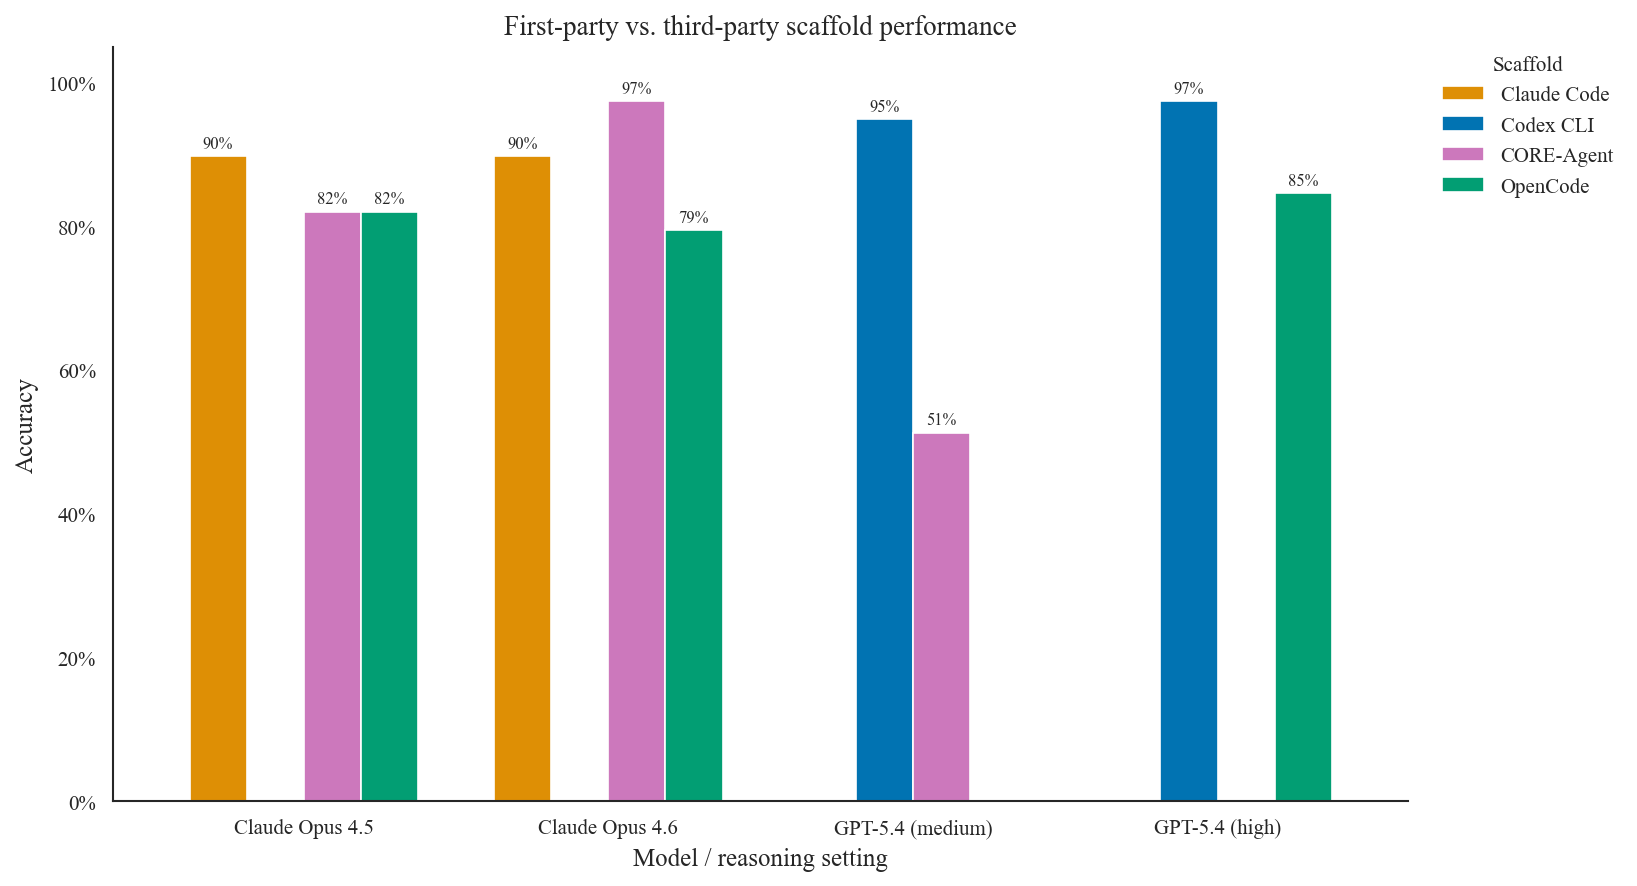

In [61]:
df_fp_plot = df_focus.copy()

def _model_panel_key(row):
    if row["model_clean"] == "gpt-5.4":
        return f"gpt-5.4::{row['re_effort']}"
    return row["model_clean"]

def _model_panel_label(panel):
    if panel == "gpt-5.4::medium":
        return "GPT-5.4 (medium)"
    if panel == "gpt-5.4::high":
        return "GPT-5.4 (high)"
    return MODEL_DISPLAY.get(panel, panel)

df_fp_plot["model_panel"] = df_fp_plot.apply(_model_panel_key, axis=1)

fp_summary = (
    df_fp_plot
    .groupby(["model_panel", "scaffold_family"], as_index=False)
    .agg(accuracy=("accuracy", "mean"), n=("accuracy", "size"))
)

model_order = [
    "claude-opus-4-5",
    "claude-opus-4-6",
    "gpt-5.4::medium",
    "gpt-5.4::high",
]

scaffold_order = ["Claude Code", "Codex CLI", "CORE-Agent", "OpenCode"]

fp_pivot = fp_summary.pivot_table(
    index="model_panel",
    columns="scaffold_family",
    values="accuracy",
).reindex(index=model_order, columns=scaffold_order)

fp_pivot.index = [_model_panel_label(m) for m in fp_pivot.index]

fig, ax = plt.subplots(figsize=(11, 6))

fp_pivot.plot(
    kind="bar",
    ax=ax,
    width=0.75,
    color=[SCAFFOLD_COLORS.get(c, "gray") for c in fp_pivot.columns],
)

ax.set_ylabel("Accuracy")
ax.set_xlabel("Model / reasoning setting")
ax.set_title("First-party vs. third-party scaffold performance")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

ax.legend(
    title="Scaffold",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=False,
)

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{v.get_height():.0%}" if not np.isnan(v.get_height()) and v.get_height() > 0 else ""
            for v in container
        ],
        fontsize=8,
        padding=2,
    )

plt.tight_layout()
plt.savefig(FIGDIR / "scaffold_performance_by_model_setting.pdf", bbox_inches="tight")
plt.savefig(FIGDIR / "scaffold_performance_by_model_setting.png", dpi=300, bbox_inches="tight")
plt.show()


In [62]:
def mcnemar_paired(df_a: pd.DataFrame, df_b: pd.DataFrame, capsule_col: str = "capsule_id"):
    """Exact McNemar test on paired binary outcomes per capsule."""
    a = df_a.set_index(capsule_col)["accuracy"]
    b = df_b.set_index(capsule_col)["accuracy"]
    merged = pd.DataFrame({"a": a, "b": b}).dropna()
    if merged.empty:
        return {"n": 0, "a1_b0": 0, "a0_b1": 0, "p": np.nan, "diff": np.nan}
    a1_b0 = int(((merged["a"] == 1) & (merged["b"] == 0)).sum())
    a0_b1 = int(((merged["a"] == 0) & (merged["b"] == 1)).sum())
    if a1_b0 + a0_b1 == 0:
        p = 1.0
    else:
        table = [[((merged["a"] == 1) & (merged["b"] == 1)).sum(), a1_b0],
                 [a0_b1, ((merged["a"] == 0) & (merged["b"] == 0)).sum()]]
        p = mcnemar(table, exact=True).pvalue
    return {
        "n": int(len(merged)),
        "a1_b0": a1_b0,
        "a0_b1": a0_b1,
        "p": float(p),
        "diff": float(merged["a"].mean() - merged["b"].mean()),
    }

def bh_fdr(pvalues, alpha: float = 0.05):
    """Benjamini–Hochberg FDR correction. Returns (rejected, p_adj)."""
    pvals = np.asarray(pvalues, dtype=float)
    if len(pvals) == 0 or np.all(np.isnan(pvals)):
        return np.zeros(len(pvals), dtype=bool), pvals
    mask = ~np.isnan(pvals)
    rejected = np.zeros(len(pvals), dtype=bool)
    p_adj = np.full(len(pvals), np.nan)
    if mask.sum() > 0:
        rej_sub, p_adj_sub, _, _ = multipletests(pvals[mask], alpha=alpha, method="fdr_bh")
        rejected[mask] = rej_sub
        p_adj[mask] = p_adj_sub
    return rejected, p_adj

In [63]:
# ---------------------------------------------------------------------------
# First-party advantage — paired McNemar tests with BH-FDR correction
# ---------------------------------------------------------------------------
# Use df_canonical so each (model, scaffold) cell is represented by exactly one configuration (no inflation)
# For each pair (model, third-party scaffold), report:
#   - paired difference (pp)
#   - McNemar exact p-value
#   - McNemar odds ratio: (b + 0.5) / (c + 0.5), with continuity correction
#     where b = FP correct / TP wrong, c = FP wrong / TP correct
# Apply BH-FDR across the family of pairs.

fp_pairs = []
for model in both_parties:
    m_runs = df_canonical[df_canonical["model_clean"] == model]
    fp_scaffold = "Codex CLI" if model.startswith("gpt-") else "Claude Code"
    fp_runs = m_runs[m_runs["scaffold_family"] == fp_scaffold]
    if fp_runs.empty:
        continue
    for tp_scaffold in m_runs["scaffold_family"].unique():
        if tp_scaffold == fp_scaffold:
            continue
        tp_runs = m_runs[m_runs["scaffold_family"] == tp_scaffold]
        if tp_runs.empty:
            continue
        # df_canonical already gives one row per capsule per (model, scaffold) cell
        fp_per_cap = fp_runs[["capsule_id", "accuracy"]].copy()
        tp_per_cap = tp_runs[["capsule_id", "accuracy"]].copy()
        fp_per_cap["accuracy"] = fp_per_cap["accuracy"].round().astype(int)
        tp_per_cap["accuracy"] = tp_per_cap["accuracy"].round().astype(int)
        result = mcnemar_paired(fp_per_cap, tp_per_cap)
        # Odds ratio with continuity correction
        b = result["a1_b0"]   # FP correct, TP wrong
        c = result["a0_b1"]   # FP wrong, TP correct
        or_cc = (b + 0.5) / (c + 0.5)
        fp_pairs.append({
            "model": model,
            "fp_scaffold": fp_scaffold,
            "tp_scaffold": tp_scaffold,
            **result,
            "fp_acc": fp_per_cap["accuracy"].mean(),
            "tp_acc": tp_per_cap["accuracy"].mean(),
            "or": float(or_cc),
            "or_log": float(np.log(or_cc)),
        })

fp_pairs_df = pd.DataFrame(fp_pairs)
fp_pairs_df["advantage_pp"] = (fp_pairs_df["fp_acc"] - fp_pairs_df["tp_acc"]) * 100

rejected, p_adj = bh_fdr(fp_pairs_df["p"].values)
fp_pairs_df["p_fdr"] = p_adj
fp_pairs_df["sig_fdr"] = rejected

print("First-party (FP) vs third-party (TP) paired McNemar tests with BH-FDR:")
print(fp_pairs_df[["model", "fp_scaffold", "tp_scaffold", "n",
                   "fp_acc", "tp_acc", "advantage_pp",
                   "a1_b0", "a0_b1", "or", "p", "p_fdr", "sig_fdr"]]
      .round(4).to_string(index=False))

n_fp_wins = int((fp_pairs_df["advantage_pp"] > 0).sum())
n_fp_loses = int((fp_pairs_df["advantage_pp"] < 0).sum())
n_fp_ties = int((fp_pairs_df["advantage_pp"] == 0).sum())
n_sig = int(fp_pairs_df["sig_fdr"].sum())
mean_advantage = float(fp_pairs_df["advantage_pp"].mean())
median_advantage = float(fp_pairs_df["advantage_pp"].median())
median_or = float(fp_pairs_df["or"].median())

# Per-pair OR macros (use sanitize_key naming)
for _, r in fp_pairs_df.iterrows():
    safe = (r["model"] + "_vs_" + r["tp_scaffold"]).replace("-", "").replace(".", "").replace(" ", "_")

print(f"\nFP wins: {n_fp_wins} / {len(fp_pairs_df)}; significant after BH-FDR: {n_sig}")
print(f"Mean paired advantage: {mean_advantage:+.1f} pp; median: {median_advantage:+.1f} pp")
print(f"Median McNemar OR (b+.5)/(c+.5): {median_or:.2f}")


First-party (FP) vs third-party (TP) paired McNemar tests with BH-FDR:
          model fp_scaffold tp_scaffold  n  fp_acc  tp_acc  advantage_pp  a1_b0  a0_b1      or      p  p_fdr  sig_fdr
claude-opus-4-5 Claude Code  CORE-Agent 39  0.8974  0.8205        7.6923      5      2  2.2000 0.4531 0.4531    False
claude-opus-4-5 Claude Code    OpenCode 39  0.8974  0.8205        7.6923      5      2  2.2000 0.4531 0.4531    False
claude-opus-4-6 Claude Code  CORE-Agent 39  0.8974  0.9744       -7.6923      0      3  0.1429 0.2500 0.4336    False
claude-opus-4-6 Claude Code    OpenCode 39  0.8974  0.7949       10.2564      5      1  3.6667 0.2188 0.4336    False
        gpt-5.4   Codex CLI    OpenCode 39  0.9487  0.8462       10.2564      6      2  2.6000 0.2891 0.4336    False
        gpt-5.4   Codex CLI  CORE-Agent 39  0.9487  0.5128       43.5897     17      0 35.0000 0.0000 0.0001     True

FP wins: 5 / 6; significant after BH-FDR: 1
Mean paired advantage: +12.0 pp; median: +9.0 pp
Median Mc

In [64]:
def bootstrap_capsule(df: pd.DataFrame, stat_fn, n_boot: int = 2000, seed: int = 0,
                      capsule_col: str = "capsule_id"):
    """Cluster-bootstrap by capsule. stat_fn takes a DataFrame, returns a scalar."""
    rng = np.random.default_rng(seed)
    capsules = df[capsule_col].unique()
    point = float(stat_fn(df))
    samples = np.empty(n_boot)
    grouped = {c: df[df[capsule_col] == c] for c in capsules}
    for i in range(n_boot):
        chosen = rng.choice(capsules, size=len(capsules), replace=True)
        boot = pd.concat([grouped[c] for c in chosen], ignore_index=True)
        try:
            samples[i] = float(stat_fn(boot))
        except Exception:
            samples[i] = np.nan
    samples = samples[~np.isnan(samples)]
    if len(samples) == 0:
        return point, np.nan, np.nan, samples
    lo, hi = np.quantile(samples, [0.025, 0.975])
    return point, float(lo), float(hi), samples


# Tool-result detection — handles all four scaffolds
TOOL_RESULT_PATTERNS = [
    re.compile(r"^\[Tool Result for (\S+)(?:\s+\(([^)]+)\))?\]"),
    re.compile(r"^Observation:\s*\n\s*Execution logs:", re.MULTILINE),
]
EXIT_CODE_PATTERNS = [
    re.compile(r"\[exit code:\s*(-?\d+)\]"),
    re.compile(r"Exit\s*Code:\s*(-?\d+)"),
]

def _detect_tool_result(content: str) -> tuple[bool, str | None]:
    m = TOOL_RESULT_PATTERNS[0].match(content)
    if m:
        return True, (m.group(2) or "unknown_bracket")
    m = TOOL_RESULT_PATTERNS[1].match(content)
    if m:
        return True, "exec"
    return False, None


def _extract_exit_code(content: str) -> int | None:
    for pat in EXIT_CODE_PATTERNS:
        m = pat.search(content)
        if m:
            try:
                return int(m.group(1))
            except ValueError:
                pass
    return None

def tool_call_stats(messages: list[dict]) -> dict:
    tool_counts = Counter()
    exit_codes = Counter()
    n_calls = 0
    for msg in messages:
        content = msg.get("content")
        if not isinstance(content, str):
            continue
        if msg.get("role") != "user":
            continue
        is_tr, tool_name = _detect_tool_result(content)
        if not is_tr:
            continue
        tool_counts[tool_name or "unknown"] += 1
        n_calls += 1
        ec = _extract_exit_code(content)
        if ec is not None:
            exit_codes[ec] += 1
    nonzero = sum(c for code, c in exit_codes.items() if code != 0)
    total_with_code = sum(exit_codes.values())
    return {
        "n_tool_calls": n_calls,
        "tool_counts": dict(tool_counts),
        "exit_codes": dict(exit_codes),
        "nonzero_exit_frac": (nonzero / max(1, total_with_code)) if total_with_code > 0 else np.nan,
        "n_with_exit_code": total_with_code,
    }

In [65]:
# Bootstrap CIs on the per-model FP advantage (resample capsules)
fp_model_summary = []
for model in both_parties:
    m_runs = df_canonical[df_canonical["model_clean"] == model]
    fp_scaffold = "Codex CLI" if model.startswith("gpt-") else "Claude Code"
    fp_runs = m_runs[m_runs["scaffold_family"] == fp_scaffold]
    if fp_runs.empty:
        continue
    # Best third-party (worst-case for FP advantage)
    tp_choices = [s for s in m_runs["scaffold_family"].unique() if s != fp_scaffold]
    if not tp_choices:
        continue
    tp_best_scaffold = m_runs[m_runs["scaffold_family"].isin(tp_choices)] \
        .groupby("scaffold_family")["accuracy"].mean().idxmax()
    tp_runs = m_runs[m_runs["scaffold_family"] == tp_best_scaffold]
    paired = pd.merge(fp_runs[["capsule_id", "accuracy"]],
                      tp_runs[["capsule_id", "accuracy"]],
                      on="capsule_id", suffixes=("_fp", "_tp"))
    if paired.empty:
        continue
    def diff(boot):
        return (boot["accuracy_fp"] - boot["accuracy_tp"]).mean() * 100
    point, lo, hi, _ = bootstrap_capsule(paired, diff, n_boot=2000, seed=42)
    fp_model_summary.append({
        "model": model,
        "fp_scaffold": fp_scaffold,
        "tp_scaffold_best": tp_best_scaffold,
        "n_capsules": len(paired),
        "fp_acc": float(paired["accuracy_fp"].mean()),
        "tp_acc": float(paired["accuracy_tp"].mean()),
        "advantage_pp": point,
        "ci_lo": lo,
        "ci_hi": hi,
    })

fp_model_summary_df = pd.DataFrame(fp_model_summary)
print("\nPer-model FP advantage vs best TP (95% bootstrap CI):")
print(fp_model_summary_df.round(2).to_string(index=False))

for _, r in fp_model_summary_df.iterrows():
    safe = r["model"].replace("-", "").replace(".", "").replace("_", "")



Per-model FP advantage vs best TP (95% bootstrap CI):
          model fp_scaffold tp_scaffold_best  n_capsules  fp_acc  tp_acc  advantage_pp  ci_lo  ci_hi
claude-opus-4-5 Claude Code       CORE-Agent          39    0.90    0.82          7.69  -5.13  20.51
claude-opus-4-6 Claude Code       CORE-Agent          39    0.90    0.97         -7.69 -17.95   0.00
        gpt-5.4   Codex CLI         OpenCode          39    0.95    0.85         10.26  -2.56  23.08


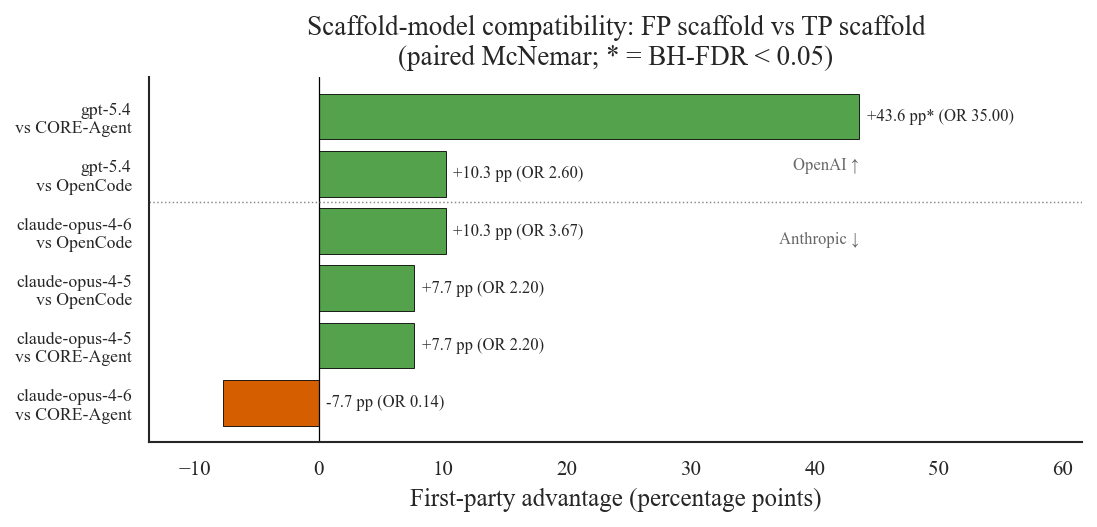

In [66]:
# Figure: scaffold-model compatibility (per-pair). Bars ordered by model_provider
# so Anthropic models appear together, then OpenAI; positive-bar labels right of
# the bar, negative-bar labels left of the bar (no collision with y-axis).
plot_data = fp_pairs_df.copy()
# Determine model_provider for each row
def _prov(m):
    return "Anthropic" if (m.startswith("claude") or m.startswith("opus")) else "OpenAI"
plot_data["model_provider"] = plot_data["model"].apply(_prov)
plot_data["pair_label"] = plot_data["model"] + "\nvs " + plot_data["tp_scaffold"]
# Sort within each provider group by |advantage_pp| descending so the largest-
# magnitude pair leads each group (e.g., GPT-5.4 vs CORE-Agent leads OpenAI).
plot_data["abs_adv"] = plot_data["advantage_pp"].abs()
plot_data = plot_data.sort_values(["model_provider", "abs_adv"],
                                   ascending=[True, True]).reset_index(drop=True)
plot_data = plot_data.drop(columns=["abs_adv"])

fig, ax = plt.subplots(figsize=(7.2, max(3.4, 0.42 * len(plot_data))),
                       constrained_layout=True)
colors = ["#54A24B" if v > 0 else "#D55E00" for v in plot_data["advantage_pp"]]  # Wong CB-safe
y = np.arange(len(plot_data))
ax.barh(y, plot_data["advantage_pp"], color=colors, edgecolor="black", linewidth=0.4)
for i, (_, r) in enumerate(plot_data.iterrows()):
    star = "*" if r["sig_fdr"] else ""
    or_val = r["or"] if "or" in r and pd.notna(r["or"]) else None
    or_str = f" (OR {or_val:.2f})" if or_val is not None else ""
    label = f"{r['advantage_pp']:+.1f} pp{star}{or_str}"
    # Always place the label just to the right of zero (or just past the
    # positive bar tip) so negative-bar labels never collide with the long
    # y-tick text in the negative margin.
    if r["advantage_pp"] >= 0:
        ax.text(r["advantage_pp"] + 0.6, i, label, va="center", ha="left", fontsize=8)
    else:
        ax.text(0.6, i, label, va="center", ha="left", fontsize=8)
ax.axvline(0, color="black", linewidth=0.6)

# Provider separator
boundary = plot_data[plot_data["model_provider"] == "Anthropic"].index.max()
if boundary is not None and not pd.isna(boundary) and boundary < len(plot_data) - 1:
    ax.axhline(boundary + 0.5, color="#888", linewidth=0.7, linestyle=":")
    ax.text(plot_data["advantage_pp"].max() * 1.0, boundary, "Anthropic ↓",
            va="top", ha="right", fontsize=8, color="#666")
    ax.text(plot_data["advantage_pp"].max() * 1.0, boundary + 1, "OpenAI ↑",
            va="bottom", ha="right", fontsize=8, color="#666")

ax.set_yticks(y)
ax.set_yticklabels(plot_data["pair_label"], fontsize=8.5)
# Pad x-limits so left labels don't collide with axis
xmin = min(plot_data["advantage_pp"].min() - 6, -8)
xmax = plot_data["advantage_pp"].max() + 18
ax.set_xlim(xmin, xmax)
ax.set_xlabel("First-party advantage (percentage points)")
ax.set_title("Scaffold-model compatibility: FP scaffold vs TP scaffold\n(paired McNemar; * = BH-FDR < 0.05)")
fig.savefig(FIGDIR / "first_party_advantage.pdf")
fig.savefig(FIGDIR / "first_party_advantage.svg")
fig.savefig(FIGDIR / "first_party_advantage.png", dpi=300)
plt.show()


## Same model, different scaffolds

In [67]:
print("Same model - different scaffolds - per capsule disagreement analysis:")

for model in multi_scaffold_models:
    m_df = df_default[df_default["model_clean"] == model]
    scaffolds = sorted(m_df["scaffold_family"].unique())

    print(f"\n{'='*70}")
    print(f"MODEL: {model} ({len(scaffolds)} scaffolds)")
    print(f"{'='*70}")

    for s in scaffolds:
        s_df = m_df[m_df["scaffold_family"] == s]
        print(f"  {s:15s}  acc={s_df['accuracy'].mean():.1%}  msg={s_df['message_count'].mean():.0f}  errors={s_df['has_error'].sum()}")

    # Per-capsule pivot
    pivot = m_df.pivot_table(index="capsule_id", columns="scaffold_family", values="accuracy")
    row_sums = pivot.sum(axis=1)

    all_correct = (row_sums == len(scaffolds)).sum()
    all_wrong = (row_sums == 0).sum()
    disagreement = ((row_sums > 0) & (row_sums < len(scaffolds))).sum()

    print(f"\n  Agreement: {all_correct} all correct, {all_wrong} all wrong, {disagreement} disagreement")

    if disagreement > 0:
        disagree_df = pivot[(row_sums > 0) & (row_sums < len(scaffolds))]
        print(f"\n  Disagreement capsules:")
        print(disagree_df.to_string())

        # Which scaffold uniquely solves each disagreement capsule?
        for s in scaffolds:
            unique_solves = disagree_df[(disagree_df[s] == 1) & (disagree_df.drop(columns=s).max(axis=1) == 0)]
            if len(unique_solves) > 0:
                print(f"\n  Only {s} solves: {unique_solves.index.tolist()}")

Same model - different scaffolds - per capsule disagreement analysis:

MODEL: claude-opus-4-5 (3 scaffolds)
  CORE-Agent       acc=82.1%  msg=85  errors=2
  Claude Code      acc=89.7%  msg=129  errors=3
  OpenCode         acc=82.1%  msg=47  errors=7

  Agreement: 27 all correct, 0 all wrong, 12 disagreement

  Disagreement capsules:
scaffold_family  CORE-Agent  Claude Code  OpenCode
capsule_id                                        
capsule-0851068         0.0          0.0       1.0
capsule-1624349         0.0          1.0       1.0
capsule-2804717         1.0          0.0       0.0
capsule-3301293         0.0          1.0       1.0
capsule-3593259         1.0          1.0       0.0
capsule-3639589         0.0          1.0       1.0
capsule-3762736         0.0          1.0       0.0
capsule-3821950         0.0          1.0       0.0
capsule-4252248         0.0          0.0       1.0
capsule-5136217         1.0          0.0       0.0
capsule-8807709         1.0          1.0       0.0
ca

Wrote 390 plotted cells to passfail_grid_all_cells.csv
outcome                           fail  pass
panel_label      scaffold_family            
Claude Opus 4.5  CORE-Agent          7    32
                 Claude Code         4    35
                 OpenCode            7    32
Claude Opus 4.6  CORE-Agent          1    38
                 Claude Code         4    35
                 OpenCode            8    31
GPT-5.4 (high)   Codex CLI           1    38
                 OpenCode            6    33
GPT-5.4 (medium) CORE-Agent         19    20
                 Codex CLI           2    37


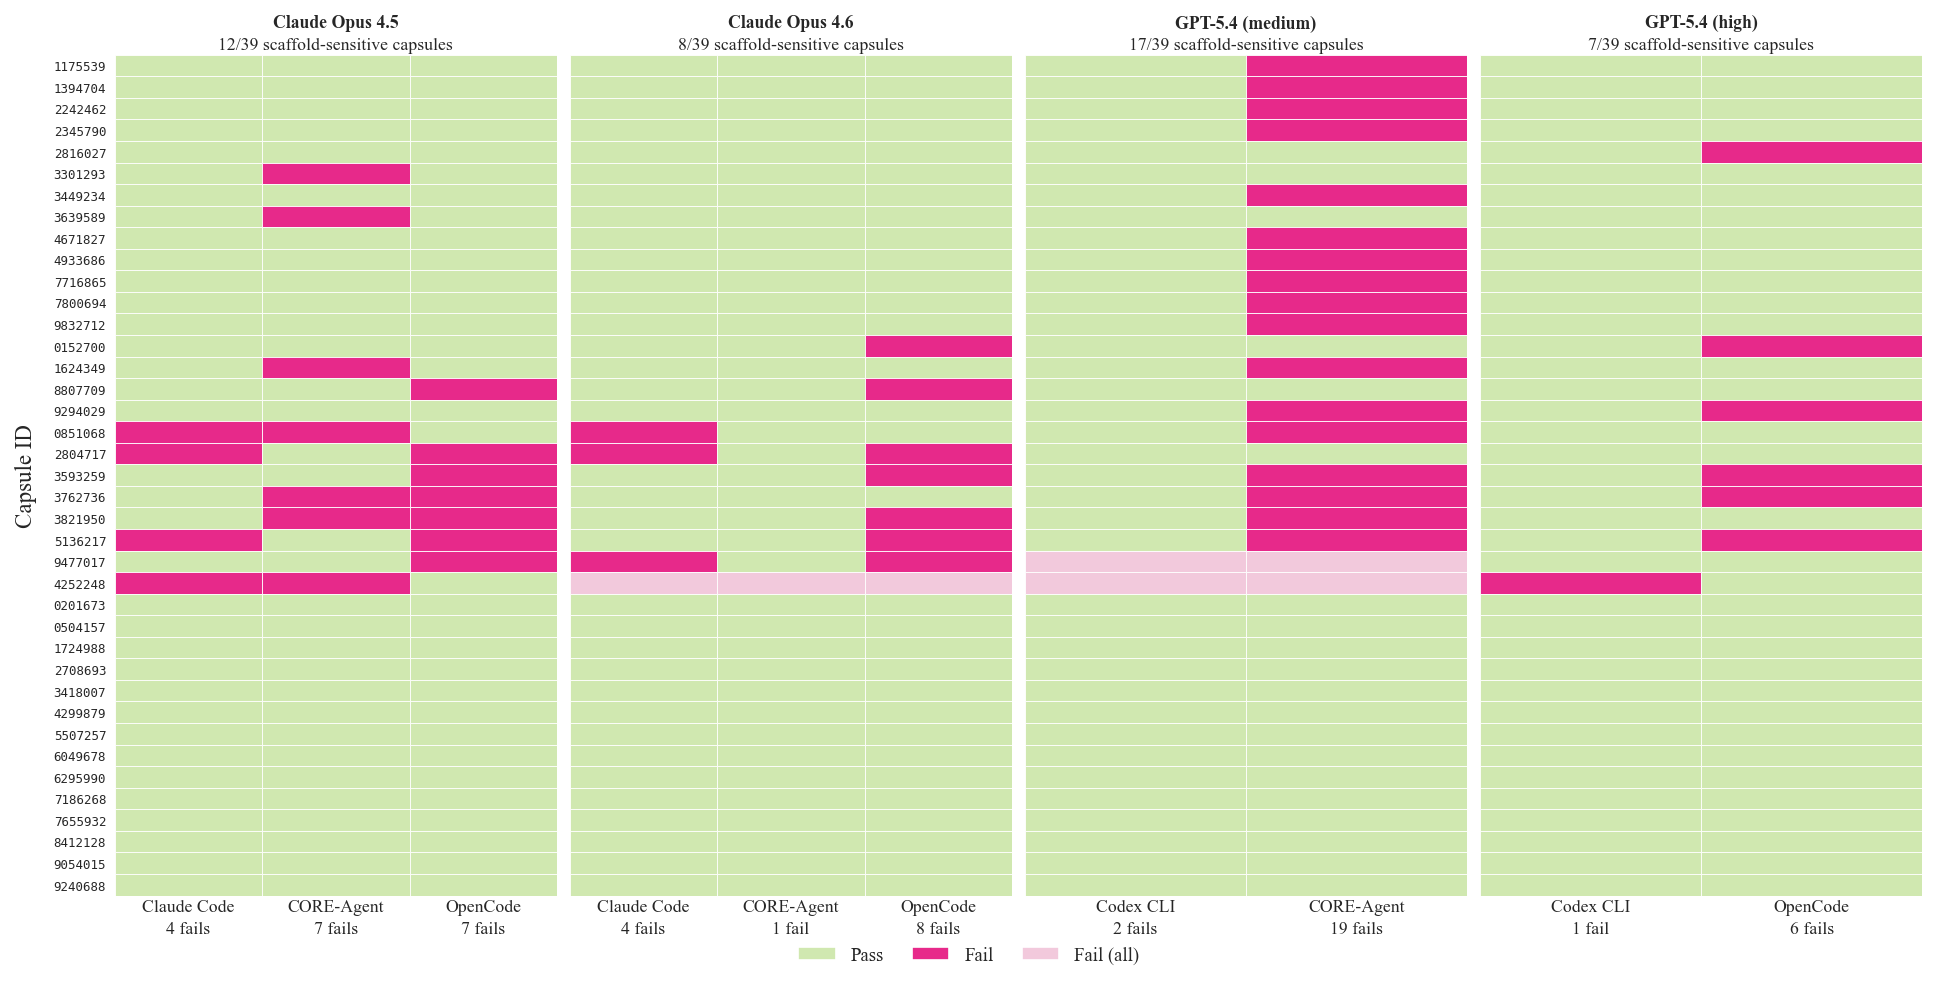

In [68]:
# Per-capsule pass/fail grid — one panel per model/effort
PASS_COLOR  = "#d0e8b0"
FAIL_COLOR  = "#e7298a"
PASS_MUTED  = "#d0e8b0"
FAIL_MUTED  = "#f2c9dc"

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

df_plot = df_focus.copy()

def _panel_key(row):
    if row["model_clean"] == "gpt-5.4":
        return f"gpt-5.4::{row['re_effort']}"
    return row["model_clean"]

def _panel_label(panel):
    if panel == "gpt-5.4::medium":
        return "GPT-5.4 (medium)"
    if panel == "gpt-5.4::high":
        return "GPT-5.4 (high)"
    return MODEL_DISPLAY.get(panel, panel)

def _ordered_scaffolds(panel, available):
    available = set(available)

    if panel.startswith("claude-opus"):
        preferred = ["Claude Code", "CORE-Agent", "OpenCode"]
    elif panel == "gpt-5.4::medium":
        preferred = ["Codex CLI", "CORE-Agent"]
    elif panel == "gpt-5.4::high":
        preferred = ["Codex CLI", "OpenCode"]
    else:
        preferred = sorted(available)

    return [s for s in preferred if s in available]

df_plot["model_panel"] = df_plot.apply(_panel_key, axis=1)

panel_order = [
    "claude-opus-4-5",
    "claude-opus-4-6",
    "gpt-5.4::medium",
    "gpt-5.4::high",
]

multi = [
    p for p in panel_order
    if p in set(df_plot["model_panel"])
    and df_plot[df_plot["model_panel"] == p]["scaffold_family"].nunique() >= 2
]

flip_any = {}
pass_total = {}

for panel in multi:
    mdf = df_plot[df_plot["model_panel"] == panel]
    scaffolds = _ordered_scaffolds(panel, mdf["scaffold_family"].unique())

    piv = mdf.pivot_table(
        index="capsule_id",
        columns="scaffold_family",
        values="accuracy",
        aggfunc="mean",
    )[scaffolds]

    for cap in piv.index:
        row = piv.loc[cap].dropna()
        flipped = row.nunique() > 1
        flip_any[cap] = flip_any.get(cap, False) or flipped
        pass_total[cap] = pass_total.get(cap, 0) + row.sum()

sort_df = pd.DataFrame({
    "flip": pd.Series(flip_any).astype(int),
    "passes": pd.Series(pass_total),
})

shared_order = (
    sort_df.sort_values(["flip", "passes"], ascending=[False, False])
    .index
    .tolist()
)

n_caps = len(shared_order)
n_total_caps = df_plot["capsule_id"].nunique()

fig, axes = plt.subplots(
    1,
    len(multi),
    figsize=(3.2 * len(multi), max(5.0, 0.16 * n_caps)),
    sharey=True,
    constrained_layout=True,
)

if len(multi) == 1:
    axes = [axes]

csv_rows = []

for ax_idx, (ax, panel) in enumerate(zip(axes, multi)):
    mdf = df_plot[df_plot["model_panel"] == panel]
    scaffolds = _ordered_scaffolds(panel, mdf["scaffold_family"].unique())

    piv = mdf.pivot_table(
        index="capsule_id",
        columns="scaffold_family",
        values="accuracy",
        aggfunc="mean",
    )[scaffolds].reindex(shared_order)

    changed = piv.apply(lambda r: r.dropna().nunique() > 1, axis=1)
    n_changed = int(changed.sum())

    for i, cap in enumerate(shared_order):
        is_flip = bool(changed.loc[cap]) if cap in changed.index else False

        for j, scf in enumerate(scaffolds):
            val = piv.loc[cap, scf] if cap in piv.index else np.nan

            if pd.isna(val):
                color = "#f0f0f0"
                outcome = "missing"
            elif val >= 0.5:
                color = PASS_COLOR if is_flip else PASS_MUTED
                outcome = "pass"
            else:
                color = FAIL_COLOR if is_flip else FAIL_MUTED
                outcome = "fail"

            rect = mpatches.Rectangle(
                (j, n_caps - 1 - i),
                1,
                1,
                facecolor=color,
                edgecolor="white",
                linewidth=0.4,
            )
            ax.add_patch(rect)

            csv_rows.append({
                "panel": panel,
                "panel_label": _panel_label(panel),
                "model_clean": mdf["model_clean"].iloc[0],
                "reasoning_effort": mdf["re_effort"].dropna().iloc[0] if mdf["re_effort"].notna().any() else None,
                "scaffold_family": scf,
                "capsule_id": cap,
                "accuracy": val,
                "outcome": outcome,
                "scaffold_sensitive_in_panel": is_flip,
                "color": color,
            })

    col_labels = []
    for scf in scaffolds:
        col = piv[scf].dropna()
        n_fail = int((col < 0.5).sum())
        label = "fail" if n_fail == 1 else "fails"
        col_labels.append(f"{scf}\n{n_fail} {label}")

    ax.set_xticks([j + 0.5 for j in range(len(scaffolds))])
    ax.set_xticklabels(col_labels, fontsize=8.5, ha="center", linespacing=1.5)
    ax.set_xlim(0, len(scaffolds))
    ax.set_ylim(0, n_caps)

    if ax_idx == 0:
        ax.set_yticks([n_caps - 1 - i + 0.5 for i in range(n_caps)])
        clean_capsules = [str(cap).replace("capsule-", "") for cap in shared_order]
        ax.set_yticklabels(clean_capsules, fontsize=6, fontfamily="monospace")
        ax.tick_params(axis="y", length=0, pad=4)
        ax.set_ylabel("Capsule ID", fontsize=11, labelpad=8)
    else:
        ax.tick_params(axis="y", labelleft=False, length=0)

    ax.set_title("")
    ax.text(
        0.5, 1.028,
        _panel_label(panel),
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="bold",
    )
    ax.text(
        0.5, 1.002,
        f"{n_changed}/{n_total_caps} scaffold-sensitive capsules",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.5,
    )

    for spine in ["left", "bottom", "top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(axis="x", length=0, pad=2)

handles = [
    mpatches.Patch(facecolor=PASS_COLOR, edgecolor="white", label="Pass"),
    mpatches.Patch(facecolor=FAIL_COLOR, edgecolor="white", label="Fail"),
    mpatches.Patch(facecolor=FAIL_MUTED, edgecolor="white", label="Fail (all)"),
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.04),
    columnspacing=1.5,
)

plot_csv = pd.DataFrame(csv_rows)
plot_csv.to_csv("passfail_grid_all_cells.csv", index=False)

print(f"Wrote {len(plot_csv)} plotted cells to passfail_grid_all_cells.csv")
print(plot_csv.groupby(["panel_label", "scaffold_family", "outcome"]).size().unstack(fill_value=0))

savefig("same_model_scaffold_outcomes_full.pdf")
savefig("same_model_scaffold_outcomes_full.png")
plt.show()


Wrote 250 plotted cells to passfail_capsule_grid_4_cells.csv
outcome                           fail  pass
panel_label      scaffold_family            
Claude Opus 4.5  CORE-Agent          7    18
                 Claude Code         4    21
                 OpenCode            7    18
Claude Opus 4.6  CORE-Agent          1    24
                 Claude Code         4    21
                 OpenCode            8    17
GPT-5.4 (high)   Codex CLI           1    24
                 OpenCode            6    19
GPT-5.4 (medium) CORE-Agent         19     6
                 Codex CLI           2    23


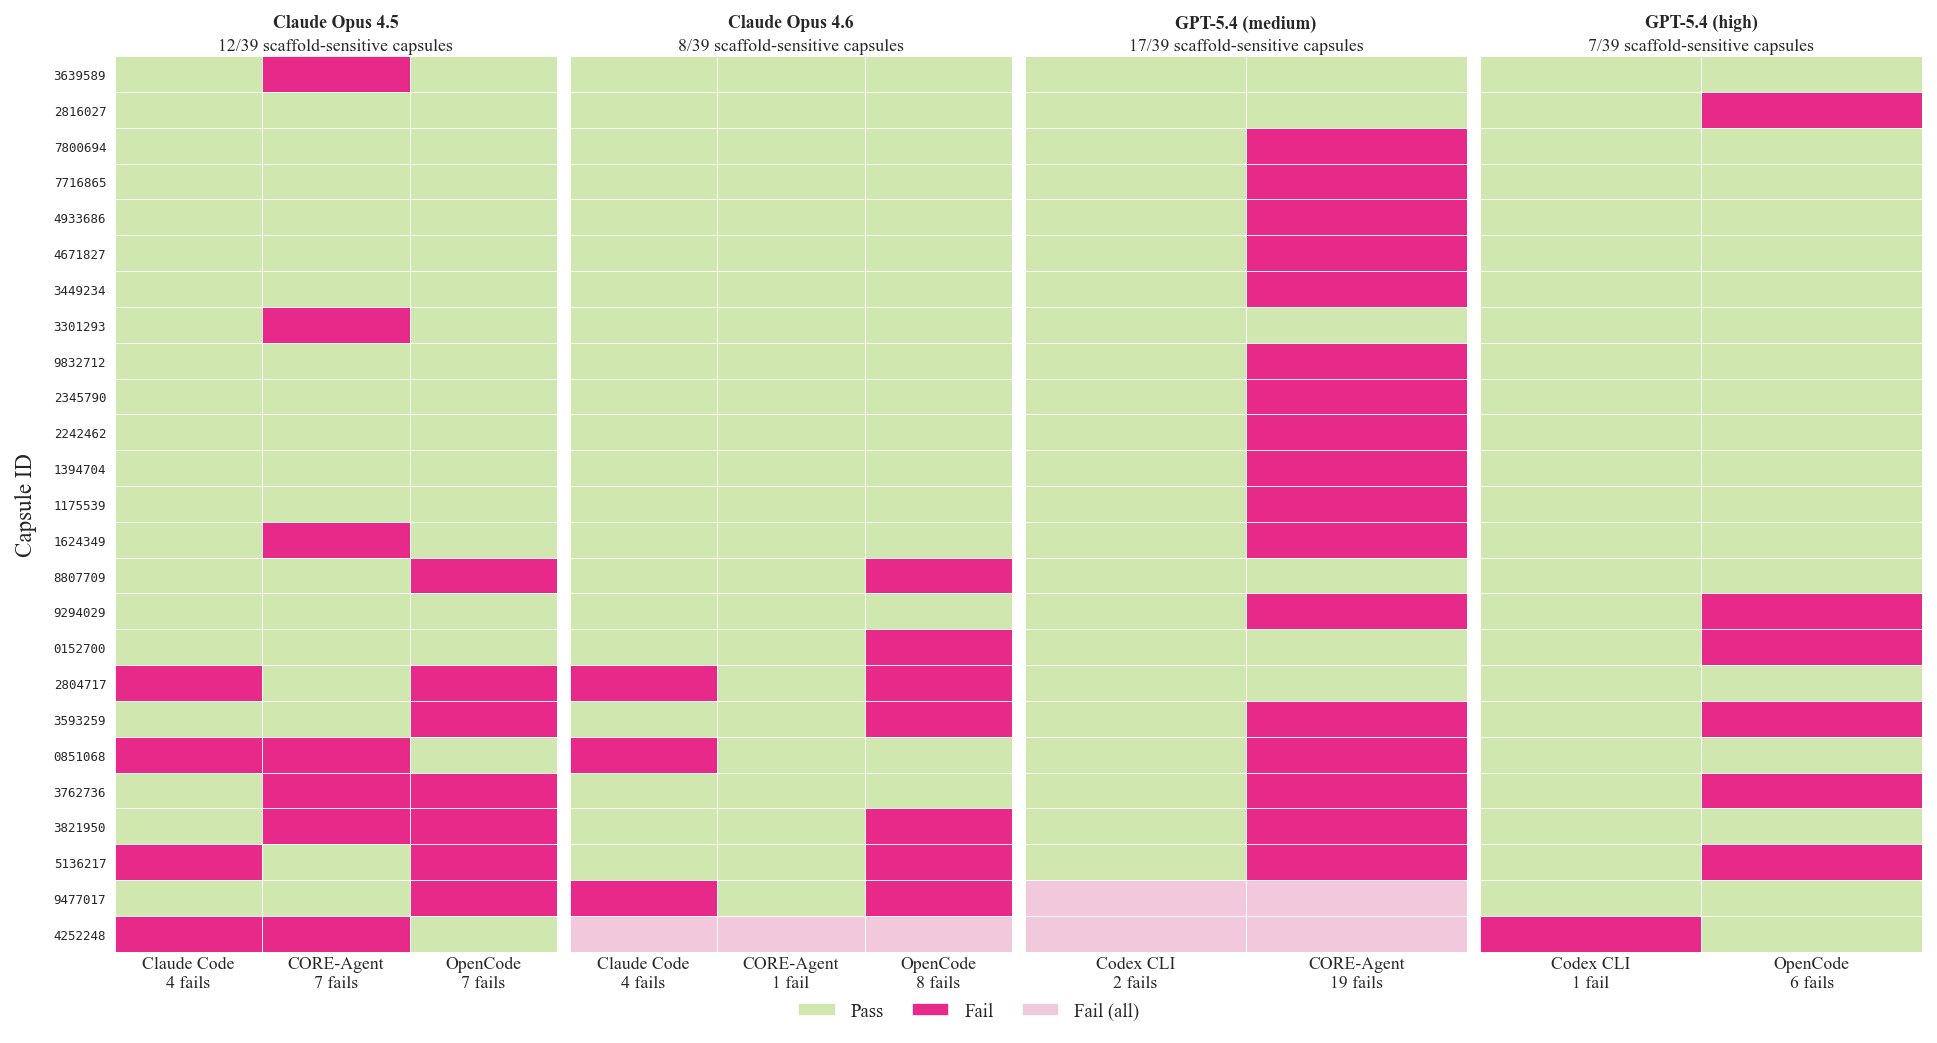

In [69]:
df_plot = df_focus.copy()

df_plot["model_panel"] = df_plot.apply(_panel_key, axis=1)
df_plot["model_panel_label"] = df_plot["model_panel"].map(_panel_label)

multi = [
    p for p in panel_order
    if p in set(df_plot["model_panel"])
    and df_plot[df_plot["model_panel"] == p]["scaffold_family"].nunique() >= 2
]

# Build a unified capsule sort order across all panels.
flip_any = {}
pass_total = {}

for panel in multi:
    mdf = df_plot[df_plot["model_panel"] == panel]
    piv = mdf.pivot_table(
        index="capsule_id",
        columns="scaffold_family",
        values="accuracy",
        aggfunc="mean",
    )

    for cap in piv.index:
        row = piv.loc[cap].dropna()
        flipped = row.nunique() > 1
        flip_any[cap] = flip_any.get(cap, False) or flipped
        pass_total[cap] = pass_total.get(cap, 0) + row.sum()

sort_df = pd.DataFrame({
    "flip": pd.Series(flip_any).astype(int),
    "passes": pd.Series(pass_total),
})

shared_order = (
    sort_df.query("flip == 1")
    .sort_values("passes", ascending=False)
    .index
    .tolist()
)

n_display_caps = len(shared_order)
n_total_caps = df_plot["capsule_id"].nunique()

fig, axes = plt.subplots(
    1,
    len(multi),
    figsize=(3.2 * len(multi), max(3.0, 0.22 * n_display_caps + 1.1)),
    sharey=True,
    constrained_layout=True,
)

if len(multi) == 1:
    axes = [axes]

csv_rows = []

for ax_idx, (ax, panel) in enumerate(zip(axes, multi)):
    mdf = df_plot[df_plot["model_panel"] == panel]
    scaffolds = _ordered_scaffolds(panel, mdf["scaffold_family"].unique())
    def _ordered_scaffolds(panel, available):
        if panel.startswith("claude-opus"):
            preferred = ["Claude Code", "CORE-Agent", "OpenCode"]
        elif panel == "gpt-5.4::medium":
            preferred = ["Codex CLI", "CORE-Agent"]
        elif panel == "gpt-5.4::high":
            preferred = ["Codex CLI", "OpenCode"]
        else:
            preferred = sorted(available)

        return [s for s in preferred if s in set(available)]


    piv_all = mdf.pivot_table(
        index="capsule_id",
        columns="scaffold_family",
        values="accuracy",
        aggfunc="mean",
    )[scaffolds]

    changed_all = piv_all.apply(lambda r: r.dropna().nunique() > 1, axis=1)
    n_changed = int(changed_all.sum())

    piv = piv_all.reindex(shared_order)

    for i, cap in enumerate(shared_order):
        is_changed_for_this_panel = bool(changed_all.loc[cap])

        for j, scf in enumerate(scaffolds):
            val = piv.loc[cap, scf]

            if pd.isna(val):
                color = "#f0f0f0"
                outcome = "missing"
            elif val >= 0.5:
                color = PASS_COLOR if is_changed_for_this_panel else PASS_MUTED
                outcome = "pass"
            else:
                color = FAIL_COLOR if is_changed_for_this_panel else FAIL_MUTED
                outcome = "fail"

            rect = mpatches.Rectangle(
                (j, n_display_caps - 1 - i),
                1,
                1,
                facecolor=color,
                edgecolor="white",
                linewidth=0.4,
            )
            ax.add_patch(rect)

            csv_rows.append({
                "panel": panel,
                "panel_label": _panel_label(panel),
                "model_clean": mdf["model_clean"].iloc[0],
                "reasoning_effort": mdf["re_effort"].dropna().iloc[0] if mdf["re_effort"].notna().any() else None,
                "scaffold_family": scf,
                "capsule_id": cap,
                "accuracy": val,
                "outcome": outcome,
                "scaffold_sensitive_in_panel": is_changed_for_this_panel,
                "color": color,
            })

    col_labels = []
    for scf in scaffolds:
        col_all = piv_all[scf].dropna()
        n_fail = int((col_all < 0.5).sum())
        label = "fail" if n_fail == 1 else "fails"
        col_labels.append(f"{scf}\n{n_fail} {label}")


    ax.set_xticks([j + 0.5 for j in range(len(scaffolds))])
    ax.set_xticklabels(col_labels, fontsize=8.5, ha="center", linespacing=1.3)
    ax.set_xlim(0, len(scaffolds))
    ax.set_ylim(0, n_display_caps)

    if ax_idx == 0:
        ax.set_yticks([n_display_caps - 1 - i + 0.5 for i in range(n_display_caps)])
        clean_capsules = [str(cap).replace("capsule-", "") for cap in shared_order]
        ax.set_yticklabels(clean_capsules, fontsize=6, fontfamily="monospace")
        ax.tick_params(axis="y", length=0, pad=4)
        ax.set_ylabel("Capsule ID", fontsize=11, labelpad=8)
    else:
        ax.tick_params(axis="y", labelleft=False, length=0)

    ax.set_title("")
    ax.text(
        0.5, 1.028,
        _panel_label(panel),
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="bold",
    )
    ax.text(
        0.5, 1.002,
        f"{n_changed}/{n_total_caps} scaffold-sensitive capsules",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="normal",
    )

    for spine in ["left", "bottom", "top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(axis="x", length=0, pad=2)

handles = [
    mpatches.Patch(facecolor=PASS_COLOR, edgecolor="white", label="Pass"),
    mpatches.Patch(facecolor=FAIL_COLOR, edgecolor="white", label="Fail"),
    mpatches.Patch(facecolor=FAIL_MUTED, edgecolor="white", label="Fail (all)"),
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.04),
    columnspacing=1.5,
)

plot_csv = pd.DataFrame(csv_rows)
plot_csv.to_csv("passfail_capsule_grid_4_cells.csv", index=False)

print(f"Wrote {len(plot_csv)} plotted cells to passfail_capsule_grid_4_cells.csv")
print(plot_csv.groupby(["panel_label", "scaffold_family", "outcome"]).size().unstack(fill_value=0))

savefig("same_model_scaffold_outcomes.pdf")
savefig("same_model_scaffold_outcomes.png")
plt.show()


## Same scaffold, different models — per-capsule analysis

In [70]:
print("Same scaffold, different models - per capsule disagreement analysis:")

for scaffold in multi_model_scaffolds:
    s_df = df_default[df_default["scaffold_family"] == scaffold]
    models = sorted(s_df["model_clean"].unique())

    print(f"\n{'='*70}")
    print(f"SCAFFOLD: {scaffold} ({len(models)} models)")
    print(f"{'='*70}")

    for m in models:
        m_sub = s_df[s_df["model_clean"] == m]
        print(f"  {m:20s}  acc={m_sub['accuracy'].mean():.1%}  msg={m_sub['message_count'].mean():.0f}  errors={m_sub['has_error'].sum()}")

    pivot = s_df.pivot_table(index="capsule_id", columns="model_clean", values="accuracy")
    row_sums = pivot.sum(axis=1)

    all_correct = (row_sums == len(models)).sum()
    all_wrong = (row_sums == 0).sum()
    disagreement = ((row_sums > 0) & (row_sums < len(models))).sum()

    print(f"\n  Agreement: {all_correct} all correct, {all_wrong} all wrong, {disagreement} disagreement")

    if disagreement > 0:
        disagree_df = pivot[(row_sums > 0) & (row_sums < len(models))]
        print(f"\n  Disagreement capsules:")
        print(disagree_df.to_string())

Same scaffold, different models - per capsule disagreement analysis:

SCAFFOLD: CORE-Agent (3 models)
  claude-opus-4-5       acc=82.1%  msg=85  errors=2
  claude-opus-4-6       acc=97.4%  msg=93  errors=0
  gpt-5.4               acc=51.3%  msg=36  errors=1

  Agreement: 18 all correct, 1 all wrong, 20 disagreement

  Disagreement capsules:
model_clean      claude-opus-4-5  claude-opus-4-6  gpt-5.4
capsule_id                                                
capsule-0851068              0.0              1.0      0.0
capsule-1175539              1.0              1.0      0.0
capsule-1394704              1.0              1.0      0.0
capsule-1624349              0.0              1.0      0.0
capsule-2242462              1.0              1.0      0.0
capsule-2345790              1.0              1.0      0.0
capsule-3301293              0.0              1.0      1.0
capsule-3449234              1.0              1.0      0.0
capsule-3593259              1.0              1.0      0.0
capsule-

Wrote 390 plotted cells to same_scaffold_model_outcomes_cells.csv
outcome                            fail  pass
scaffold_family model_panel_label            
CORE-Agent      Claude Opus 4.5       7    32
                Claude Opus 4.6       1    38
                GPT-5.4 (medium)     19    20
Claude Code     Claude Opus 4.5       4    35
                Claude Opus 4.6       4    35
Codex CLI       GPT-5.4 (high)        1    38
                GPT-5.4 (medium)      2    37
OpenCode        Claude Opus 4.5       7    32
                Claude Opus 4.6       8    31
                GPT-5.4 (high)        6    33


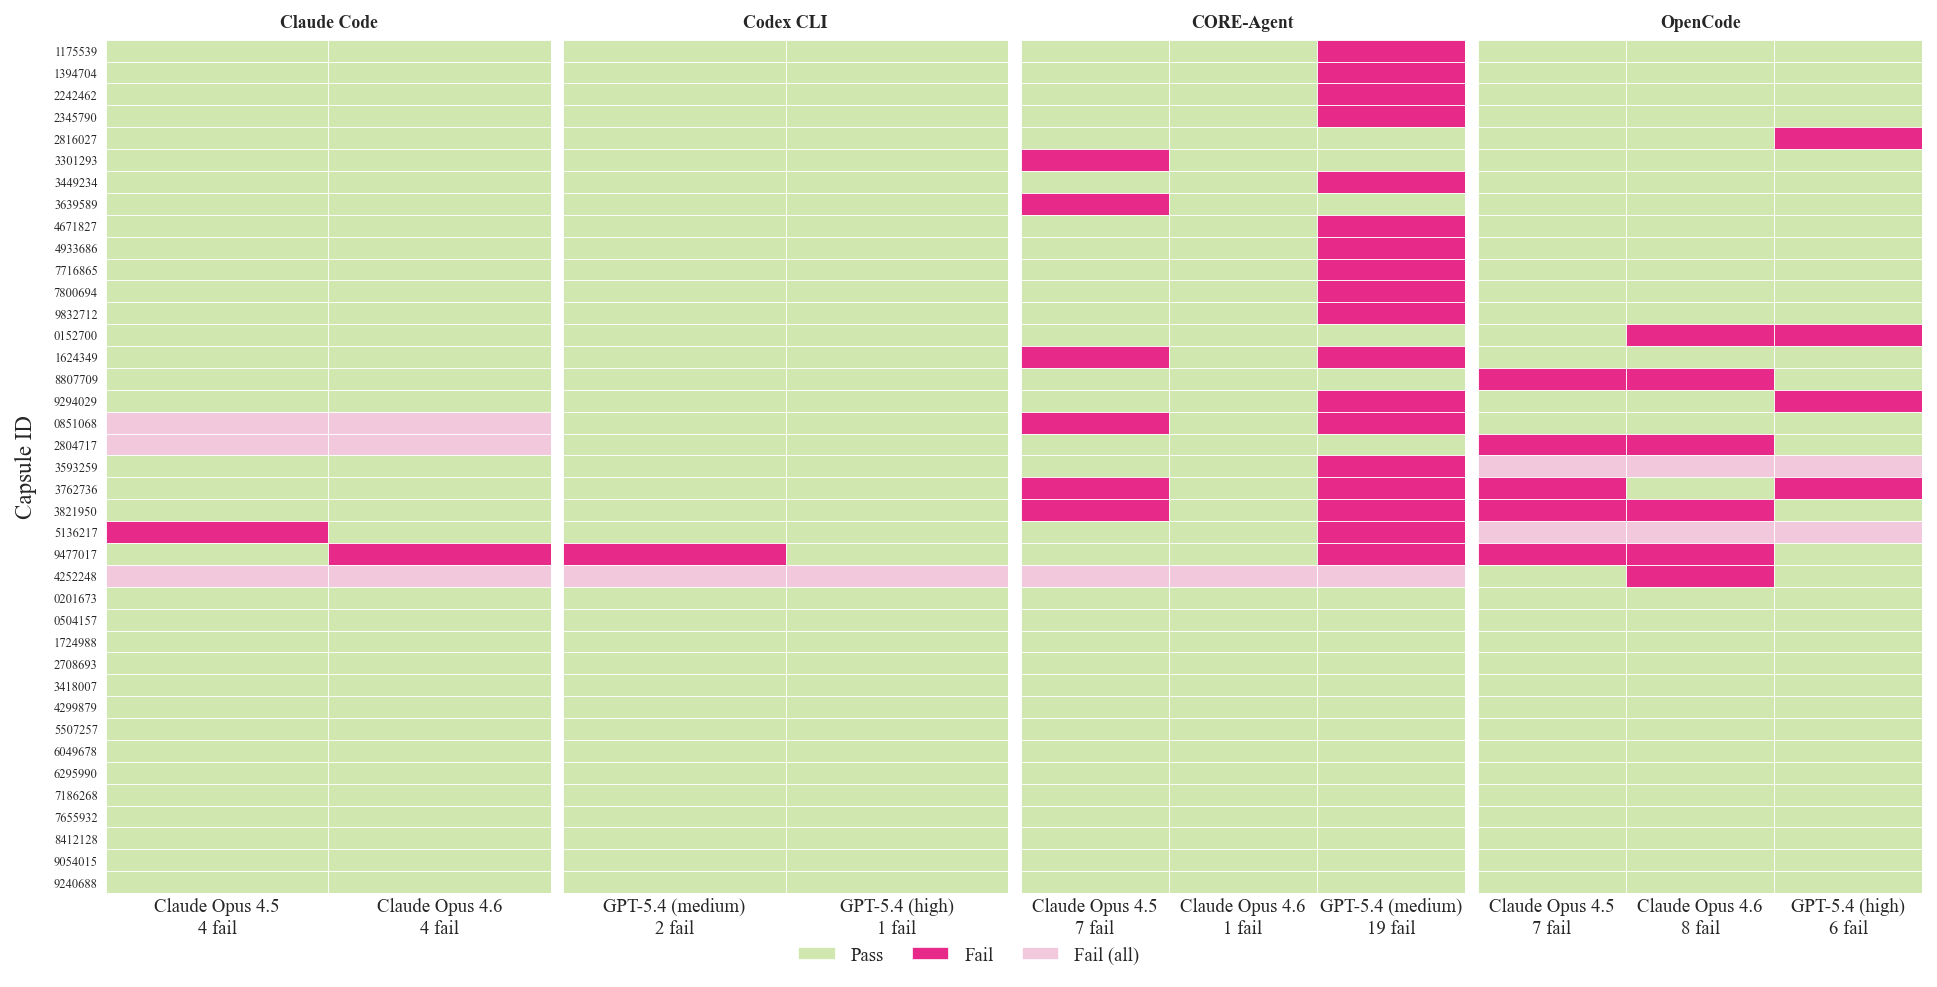

In [71]:
# Model sensitivity grid — same appearance as scaffold-sensitivity grid
PASS_COLOR  = "#d0e8b0"
FAIL_COLOR  = "#e7298a"
PASS_MUTED  = "#d0e8b0"
FAIL_MUTED  = "#f2c9dc"

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

df_model_plot = df_focus.copy()

def _model_panel_key(row):
    if row["model_clean"] == "gpt-5.4":
        return f"gpt-5.4::{row['re_effort']}"
    return row["model_clean"]

def _model_panel_label(panel):
    if panel == "gpt-5.4::medium":
        return "GPT-5.4 (medium)"
    if panel == "gpt-5.4::high":
        return "GPT-5.4 (high)"
    return MODEL_DISPLAY.get(panel, panel)

df_model_plot["model_panel"] = df_model_plot.apply(_model_panel_key, axis=1)

model_order = [
    "claude-opus-4-5",
    "claude-opus-4-6",
    "gpt-5.4::medium",
    "gpt-5.4::high",
]

scaffold_order = ["Claude Code", "Codex CLI", "CORE-Agent", "OpenCode"]

multi_scaffolds = [
    s for s in scaffold_order
    if s in set(df_model_plot["scaffold_family"])
    and df_model_plot[df_model_plot["scaffold_family"] == s]["model_panel"].nunique() >= 2
]

# Shared capsule order: model-sensitive capsules first, then by total passes.
flip_any = {}
pass_total = {}

for scaffold in multi_scaffolds:
    sdf = df_model_plot[df_model_plot["scaffold_family"] == scaffold]
    models = [m for m in model_order if m in set(sdf["model_panel"])]

    piv = sdf.pivot_table(
        index="capsule_id",
        columns="model_panel",
        values="accuracy",
        aggfunc="mean",
    )[models]

    for cap in piv.index:
        row = piv.loc[cap].dropna()
        flipped = row.nunique() > 1
        flip_any[cap] = flip_any.get(cap, False) or flipped
        pass_total[cap] = pass_total.get(cap, 0) + row.sum()

sort_df = pd.DataFrame({
    "flip": pd.Series(flip_any).astype(int),
    "passes": pd.Series(pass_total),
})

shared_order = (
    sort_df.sort_values(["flip", "passes"], ascending=[False, False])
    .index
    .tolist()
)

n_caps = len(shared_order)
n_total_caps = df_model_plot["capsule_id"].nunique()

fig, axes = plt.subplots(
    1,
    len(multi_scaffolds),
    figsize=(3.2 * len(multi_scaffolds), max(5.0, 0.16 * n_caps)),
    sharey=True,
    constrained_layout=True,
)

if len(multi_scaffolds) == 1:
    axes = [axes]

csv_rows = []

for ax_idx, (ax, scaffold) in enumerate(zip(axes, multi_scaffolds)):
    sdf = df_model_plot[df_model_plot["scaffold_family"] == scaffold]
    models = [m for m in model_order if m in set(sdf["model_panel"])]

    piv_all = sdf.pivot_table(
        index="capsule_id",
        columns="model_panel",
        values="accuracy",
        aggfunc="mean",
    )[models]

    changed_all = piv_all.apply(lambda r: r.dropna().nunique() > 1, axis=1)
    n_changed = int(changed_all.sum())

    piv = piv_all.reindex(shared_order)

    for i, cap in enumerate(shared_order):
        is_changed_for_this_scaffold = bool(changed_all.loc[cap])

        for j, model_panel in enumerate(models):
            val = piv.loc[cap, model_panel]

            if pd.isna(val):
                color = "#f0f0f0"
                outcome = "missing"
            elif val >= 0.5:
                color = PASS_COLOR if is_changed_for_this_scaffold else PASS_MUTED
                outcome = "pass"
            else:
                color = FAIL_COLOR if is_changed_for_this_scaffold else FAIL_MUTED
                outcome = "fail"

            rect = mpatches.Rectangle(
                (j, n_caps - 1 - i),
                1,
                1,
                facecolor=color,
                edgecolor="white",
                linewidth=0.4,
            )
            ax.add_patch(rect)

            csv_rows.append({
                "scaffold_family": scaffold,
                "model_panel": model_panel,
                "model_panel_label": _model_panel_label(model_panel),
                "capsule_id": cap,
                "accuracy": val,
                "outcome": outcome,
                "model_sensitive_in_scaffold": is_changed_for_this_scaffold,
                "color": color,
            })

    col_labels = []
    for model_panel in models:
        col = piv_all[model_panel].dropna()
        n_fail = int((col < 0.5).sum())
        col_labels.append(f"{_model_panel_label(model_panel)}\n{n_fail} fail")

    ax.set_xticks([j + 0.5 for j in range(len(models))])
    ax.set_xticklabels(col_labels, fontsize=9, ha="center", linespacing=1.3)
    ax.set_xlim(0, len(models))
    ax.set_ylim(0, n_caps)

    if ax_idx == 0:
        ax.set_yticks([n_caps - 1 - i + 0.5 for i in range(n_caps)])
        clean_capsules = [str(cap).replace("capsule-", "") for cap in shared_order]
        ax.set_yticklabels(clean_capsules, fontsize=6)
        ax.tick_params(axis="y", length=0, pad=4)
        ax.set_ylabel("Capsule ID", fontsize=11, labelpad=8)
    else:
        ax.tick_params(axis="y", labelleft=False, length=0)

    ax.set_title("")
    ax.text(
        0.5, 1.01,
        scaffold,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="bold",
    )

    for spine in ["left", "bottom", "top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(axis="x", length=0, pad=2)

handles = [
    mpatches.Patch(facecolor=PASS_COLOR, edgecolor="white", label="Pass"),
    mpatches.Patch(facecolor=FAIL_COLOR, edgecolor="white", label="Fail"),
    mpatches.Patch(facecolor=FAIL_MUTED, edgecolor="white", label="Fail (all)"),
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.04),
    columnspacing=1.5,
)

model_sens_csv = pd.DataFrame(csv_rows)
model_sens_csv.to_csv("same_scaffold_model_outcomes_cells.csv", index=False)

print(f"Wrote {len(model_sens_csv)} plotted cells to same_scaffold_model_outcomes_cells.csv")
print(model_sens_csv.groupby(["scaffold_family", "model_panel_label", "outcome"]).size().unstack(fill_value=0))

savefig("same_scaffold_model_outcomes_full.pdf")
savefig("same_scaffold_model_outcomes_full.png")
plt.show()

## Scaffold crossovers: when does a better scaffold beat a better model?

In [72]:
# Approximate model strength ordering
model_strength = {
    "gpt-5": 1, "gpt-5.1": 2, "gpt-5.2": 3, "gpt-5.3-codex": 4, "gpt-5.4": 5,
    "claude-opus-4-5": 4.5, "claude-opus-4-6": 5.5,
}

# Only compare configs from different scaffold families
crossovers = []
configs_list = df_configs.to_dict("records")
for i, a in enumerate(configs_list):
    for b in configs_list[i+1:]:
        if a["scaffold_family"] == b["scaffold_family"]:
            continue
        str_a = model_strength.get(a["model_clean"])
        str_b = model_strength.get(b["model_clean"])
        if str_a is None or str_b is None:
            continue
        # Weaker model has higher accuracy
        if str_a < str_b and a["accuracy"] > b["accuracy"]:
            crossovers.append({
                "wins": a["config"], "wins_acc": a["accuracy"], "wins_strength": str_a,
                "loses": b["config"], "loses_acc": b["accuracy"], "loses_strength": str_b,
                "acc_gap": a["accuracy"] - b["accuracy"],
                "strength_gap": str_b - str_a,
            })
        elif str_b < str_a and b["accuracy"] > a["accuracy"]:
            crossovers.append({
                "wins": b["config"], "wins_acc": b["accuracy"], "wins_strength": str_b,
                "loses": a["config"], "loses_acc": a["accuracy"], "loses_strength": str_a,
                "acc_gap": b["accuracy"] - a["accuracy"],
                "strength_gap": str_a - str_b,
            })

crossover_df = pd.DataFrame(crossovers).sort_values("acc_gap", ascending=False)
print(f"Scaffold crossovers: {len(crossover_df)} cases")
print(f"Largest accuracy gap: {crossover_df.iloc[0]['acc_gap']:.1%}" if len(crossover_df) > 0 else "")
print()
print(crossover_df[["wins", "wins_acc", "loses", "loses_acc", "acc_gap"]].head(15).to_string(index=False))

Scaffold crossovers: 36 cases
Largest accuracy gap: 46.2%

                                       wins  wins_acc                                    loses  loses_acc  acc_gap
         Codex CLI / gpt-5.3-codex / medium  0.974359         CORE-Agent / gpt-5.4 / steps=200   0.512821 0.461538
               Codex CLI / gpt-5.2 / medium  0.948718         CORE-Agent / gpt-5.4 / steps=200   0.512821 0.435897
Claude Code / claude-opus-4-5 / think=10000  0.897436         CORE-Agent / gpt-5.4 / steps=200   0.512821 0.384615
               Codex CLI / gpt-5.1 / medium  0.871795         CORE-Agent / gpt-5.4 / steps=200   0.512821 0.358974
                 Codex CLI / gpt-5 / medium  0.846154         CORE-Agent / gpt-5.4 / steps=200   0.512821 0.333333
   OpenCode / claude-opus-4-5 / think=10000  0.820513         CORE-Agent / gpt-5.4 / steps=200   0.512821 0.307692
                 Codex CLI / gpt-5.4 / high  0.974359               OpenCode / claude-opus-4-6   0.794872 0.179487
                Codex

### sign-test on shared capsules

In [73]:
# ---------------------------------------------------------------------------
# Crossovers: weaker model + better scaffold beats stronger model + worse scaffold
# ---------------------------------------------------------------------------

def shared_capsule_accuracy(df, config_a, config_b):
    a = df[df["config"] == config_a].set_index("capsule_id")["accuracy"]
    b = df[df["config"] == config_b].set_index("capsule_id")["accuracy"]
    merged = pd.DataFrame({"a": a, "b": b}).dropna()
    return merged

crossovers_paired = []
configs_list = df_configs.to_dict("records")
for i, ca in enumerate(configs_list):
    for cb in configs_list[i+1:]:
        if ca["scaffold_family"] == cb["scaffold_family"]:
            continue
        sa = model_strength.get(ca["model_clean"])
        sb = model_strength.get(cb["model_clean"])
        if sa is None or sb is None or sa == sb:
            continue
        # Order so 'wins' is the weaker model
        if sa < sb:
            weaker, stronger = ca, cb
            sw, ss = sa, sb
        else:
            weaker, stronger = cb, ca
            sw, ss = sb, sa
        merged = shared_capsule_accuracy(df_default, weaker["config"], stronger["config"])
        if merged.empty or len(merged) < 30:
            continue
        diff = merged["a"] - merged["b"]
        # Signed two-tailed sign test
        n_pos = int((diff > 0).sum()); n_neg = int((diff < 0).sum())
        n_disc = n_pos + n_neg
        if n_disc == 0:
            p_sign = 1.0
        else:
            p_sign = float(sp_stats.binomtest(n_pos, n_disc, p=0.5,
                                              alternative="two-sided").pvalue)
        gap = float(merged["a"].mean() - merged["b"].mean())
        # Only keep cases where the weaker model wins on average
        if gap > 0:
            crossovers_paired.append({
                "weaker_config": weaker["config"],
                "weaker_model": weaker["model_clean"],
                "weaker_scaffold": weaker["scaffold_family"],
                "stronger_config": stronger["config"],
                "stronger_model": stronger["model_clean"],
                "stronger_scaffold": stronger["scaffold_family"],
                "weaker_strength": sw, "stronger_strength": ss,
                "n_capsules": int(len(merged)),
                "weaker_acc": float(merged["a"].mean()),
                "stronger_acc": float(merged["b"].mean()),
                "gap": gap,
                "n_weaker_wins": n_pos, "n_stronger_wins": n_neg,
                "p_sign": p_sign,
            })

cross_df = pd.DataFrame(crossovers_paired).sort_values("gap", ascending=False)
if not cross_df.empty:
    rejected, p_adj = bh_fdr(cross_df["p_sign"].values)
    cross_df["p_fdr"] = p_adj
    cross_df["sig_fdr"] = rejected
print(f"Crossovers (weaker model wins on shared capsules): {len(cross_df)}")
if not cross_df.empty:
    print(cross_df[["weaker_config", "stronger_config", "n_capsules",
                    "weaker_acc", "stronger_acc", "gap",
                    "n_weaker_wins", "n_stronger_wins", "p_sign", "p_fdr", "sig_fdr"]]
          .head(15).round(3).to_string(index=False))

Crossovers (weaker model wins on shared capsules): 36
                              weaker_config                          stronger_config  n_capsules  weaker_acc  stronger_acc   gap  n_weaker_wins  n_stronger_wins  p_sign  p_fdr  sig_fdr
         Codex CLI / gpt-5.3-codex / medium         CORE-Agent / gpt-5.4 / steps=200          39       0.974         0.513 0.462             18                0   0.000  0.000     True
               Codex CLI / gpt-5.2 / medium         CORE-Agent / gpt-5.4 / steps=200          39       0.949         0.513 0.436             18                1   0.000  0.001     True
Claude Code / claude-opus-4-5 / think=10000         CORE-Agent / gpt-5.4 / steps=200          39       0.897         0.513 0.385             16                1   0.000  0.003     True
               Codex CLI / gpt-5.1 / medium         CORE-Agent / gpt-5.4 / steps=200          39       0.872         0.513 0.359             17                3   0.003  0.019     True
                 Code

## Failure mode analysis

Do different scaffolds/models fail differently?

In [74]:
# Error rates by scaffold family and model
error_by_config = df_default.groupby(["scaffold_family", "model_clean"]).agg(
    accuracy=("accuracy", "mean"),
    error_rate=("has_error", "mean"),
    n_errors=("has_error", "sum"),
    n=("accuracy", "count"),
).reset_index()

print("Error rates by scaffold x model:")
print(error_by_config.sort_values("error_rate", ascending=False).to_string(index=False))

Error rates by scaffold x model:
scaffold_family     model_clean  accuracy  error_rate  n_errors   n
       OpenCode claude-opus-4-5  0.820513    0.179487         7  39
       OpenCode claude-opus-4-6  0.794872    0.179487         7  39
       OpenCode         gpt-5.4  0.846154    0.153846         6  39
    Claude Code claude-opus-4-5  0.897436    0.076923         3  39
     CORE-Agent claude-opus-4-5  0.820513    0.051282         2  39
    Claude Code claude-opus-4-6  0.897436    0.051282         2  39
     CORE-Agent         gpt-5.4  0.512821    0.025641         1  39
     CORE-Agent claude-opus-4-6  0.974359    0.000000         0  39
      Codex CLI           gpt-5  0.846154    0.000000         0  39
      Codex CLI         gpt-5.1  0.871795    0.000000         0  39
      Codex CLI         gpt-5.2  0.948718    0.000000         0  39
      Codex CLI   gpt-5.3-codex  0.974359    0.000000         0  39
      Codex CLI         gpt-5.4  0.955128    0.000000         0 156


In [75]:
errors = df_default[df_default["has_error"]]
if len(errors) > 0:
    print(f"Total runs with errors: {len(errors)} / {len(df_default)}")
    print(f"\nError messages:")
    print(errors["error"].value_counts().to_string())
    print(f"\nErrors by scaffold:")
    print(errors.groupby("scaffold_family").size().to_string())
else:
    print("No error field entries found.")

Total runs with errors: 28 / 624

Error messages:
error
Expecting value: line 1 column 1 (char 0)    28

Errors by scaffold:
scaffold_family
CORE-Agent      3
Claude Code     5
OpenCode       20


In [76]:
# Written vs vision question performance
# Some capsules have only written questions, some only vision, some both.
# Do scaffolds differ in their ability to handle vision vs written?

# Per-config accuracy on written-only vs vision-only capsules
df_default["question_type"] = df_default.apply(
    lambda r: "written_only" if r["total_written"] > 0 and r["total_vision"] == 0
             else ("vision_only" if r["total_vision"] > 0 and r["total_written"] == 0
                   else "mixed"),
    axis=1
)

print("Capsule question types:")
print(df_default.groupby("question_type")["capsule_id"].nunique())

# Accuracy by scaffold and question type
qt_acc = df_default.groupby(["scaffold_family", "question_type"])["accuracy"].mean().unstack()
print(f"\nAccuracy by scaffold x question type:")
print(qt_acc.to_string())

Capsule question types:
question_type
mixed            4
vision_only     22
written_only    13
Name: capsule_id, dtype: int64

Accuracy by scaffold x question type:
question_type       mixed  vision_only  written_only
scaffold_family                                     
CORE-Agent       0.750000     0.757576      0.794872
Claude Code      1.000000     0.863636      0.923077
Codex CLI        0.875000     0.909091      0.990385
OpenCode         0.833333     0.742424      0.948718


In [77]:
# On incorrect runs, what went wrong?
# Look at incorrect runs: did the agent get partial credit on multi-question capsules?
incorrect = df_default[df_default["accuracy"] == 0].copy()
incorrect["got_some_written"] = incorrect["correct_written"] > 0
incorrect["got_some_vision"] = incorrect["correct_vision"] > 0
incorrect["got_nothing"] = (incorrect["correct_written"] == 0) & (incorrect["correct_vision"] == 0)

print(f"Incorrect runs: {len(incorrect)} / {len(df_default)}")
print(f"\nGot at least one written question right: {incorrect['got_some_written'].sum()}")
print(f"Got at least one vision question right: {incorrect['got_some_vision'].sum()}")
print(f"Got nothing right: {incorrect['got_nothing'].sum()}")

print(f"\nIncorrect runs by scaffold:")
print(incorrect.groupby("scaffold_family")[["got_some_written", "got_some_vision", "got_nothing", "has_error"]].sum())

Incorrect runs: 77 / 624

Got at least one written question right: 1
Got at least one vision question right: 8
Got nothing right: 68

Incorrect runs by scaffold:
                 got_some_written  got_some_vision  got_nothing  has_error
scaffold_family                                                           
CORE-Agent                      1                3           23          3
Claude Code                     0                0            8          5
Codex CLI                       0                5           16          0
OpenCode                        0                0           21         20


### Failure modes from metadata

In [78]:
# ---------------------------------------------------------------------------
# Metadata-driven failure modes
# ---------------------------------------------------------------------------
# Compute tool-call statistics from raw transcripts
# Cache to df_default["tool_*"] columns.

def tool_call_stats(messages: list[dict]) -> dict:
    tool_counts = Counter()
    exit_codes = Counter()
    n_calls = 0
    for msg in messages:
        content = msg.get("content")
        if not isinstance(content, str):
            continue
        if msg.get("role") != "user":
            continue
        is_tr, tool_name = _detect_tool_result(content)
        if not is_tr:
            continue
        tool_counts[tool_name or "unknown"] += 1
        n_calls += 1
        ec = _extract_exit_code(content)
        if ec is not None:
            exit_codes[ec] += 1
    nonzero = sum(c for code, c in exit_codes.items() if code != 0)
    total_with_code = sum(exit_codes.values())
    return {
        "n_tool_calls": n_calls,
        "tool_counts": dict(tool_counts),
        "exit_codes": dict(exit_codes),
        "nonzero_exit_frac": (nonzero / max(1, total_with_code)) if total_with_code > 0 else np.nan,
        "n_with_exit_code": total_with_code,
    }

print("Mining tool-call stats from transcripts...")
tool_records = []
rows_by_run = {row["agent_run_id"]: row for row in rows_all}
for run_id in df["agent_run_id"]:
    row = rows_by_run.get(run_id)
    if row is None:
        tool_records.append({"agent_run_id": run_id, "n_tool_calls": np.nan,
                             "nonzero_exit_frac": np.nan, "n_with_exit_code": 0})
        continue
    stats_ = tool_call_stats(row.get("messages", []))
    tool_records.append({
        "agent_run_id": run_id,
        "n_tool_calls": stats_["n_tool_calls"],
        "nonzero_exit_frac": stats_["nonzero_exit_frac"],
        "n_with_exit_code": stats_["n_with_exit_code"],
    })

tool_df = pd.DataFrame(tool_records)
df = df.merge(tool_df, on="agent_run_id", how="left")
df_default = df_default.merge(tool_df, on="agent_run_id", how="left")
print(f"Median tool calls per run: {df['n_tool_calls'].median():.0f}")
print(f"Median fraction non-zero exit: {df['nonzero_exit_frac'].median():.2%}")


Mining tool-call stats from transcripts...
Median tool calls per run: 24
Median fraction non-zero exit: 16.67%


/var/folders/mt/fzt_rckj79x893_9z9kh5jbm0000gn/T/ipykernel_22822/1868474104.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x="scaffold_family", y="message_count",


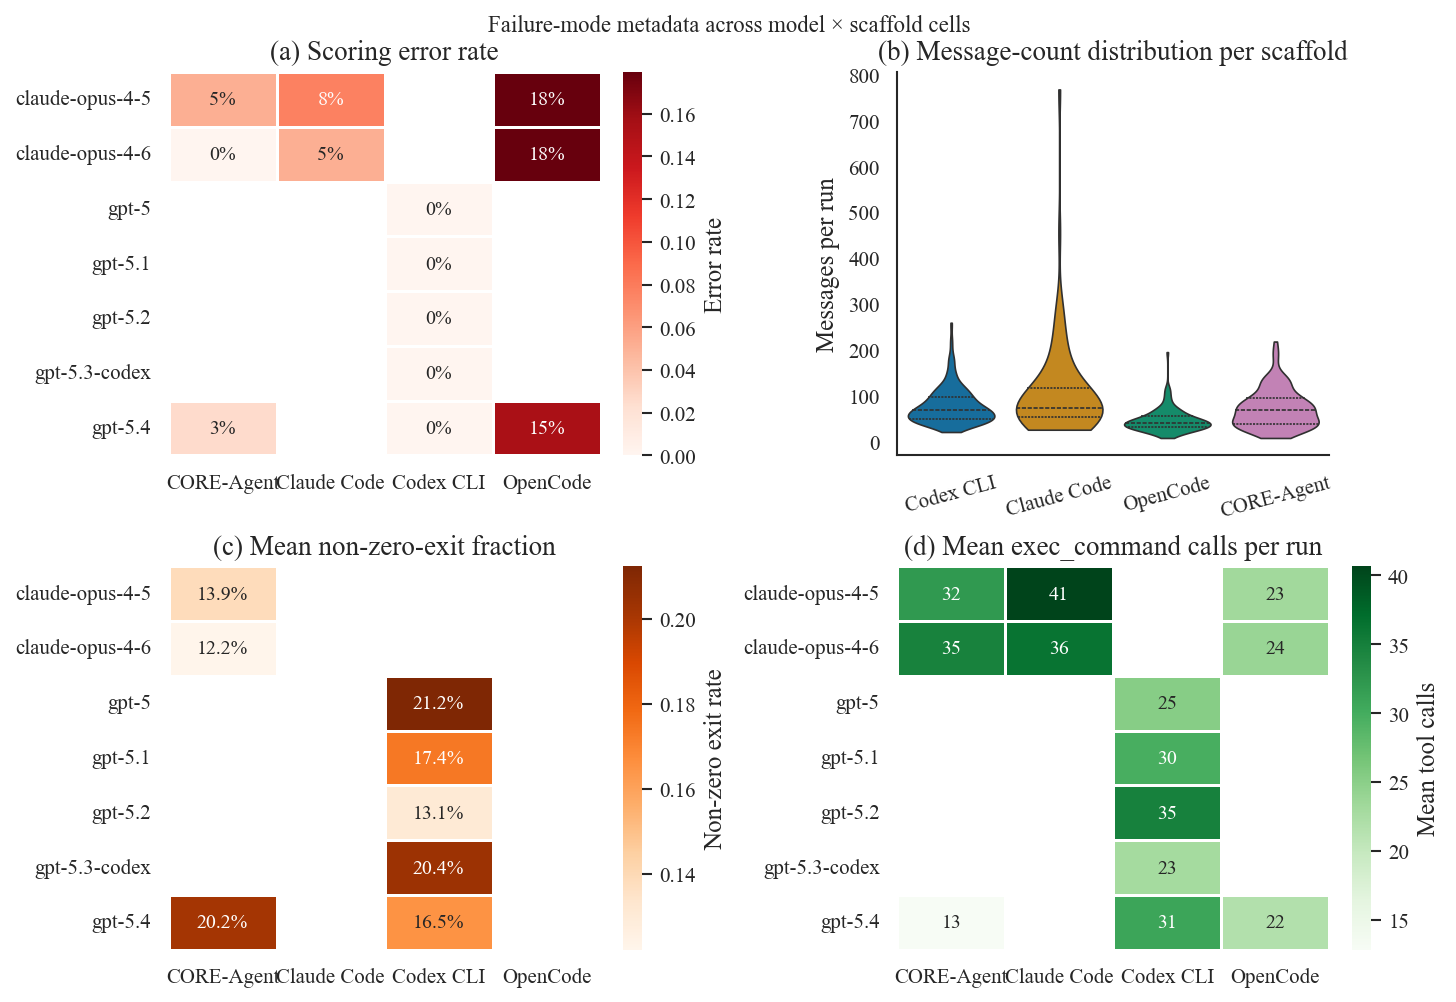

Overall scoring error rate: 4.49%
Overall mean non-zero exit fraction: 16.77%
Median tool calls per run: 24


In [79]:
# 2x2 facet figure — panel (b) replaced with per-scaffold message-count violin
fig, axes = plt.subplots(2, 2, figsize=(9.6, 6.4), constrained_layout=True)

# Scoring error rate heatmap
err_matrix = df_default.groupby(["model_clean", "scaffold_family"])["has_error"] \
    .mean().unstack()
sns.heatmap(err_matrix, annot=True, fmt=".0%", cmap="Reds", ax=axes[0, 0],
            linewidths=0.5, cbar_kws={"label": "Error rate"},
            vmin=0, vmax=max(0.1, float(err_matrix.max().max())))
axes[0, 0].set_title("(a) Scoring error rate")
axes[0, 0].set_xlabel(""); axes[0, 0].set_ylabel("")

# per-scaffold message-count violin (where it actually has signal)
ax_b = axes[0, 1]
order = ["Codex CLI", "Claude Code", "OpenCode", "CORE-Agent"]
plot_data = df_default[df_default["scaffold_family"].isin(order)].copy()
sns.violinplot(data=plot_data, x="scaffold_family", y="message_count",
               order=order,
               palette=[SCAFFOLD_COLORS.get(s, "gray") for s in order],
               inner="quartile", ax=ax_b, cut=0, linewidth=0.8)
ax_b.set_title("(b) Message-count distribution per scaffold")
ax_b.set_xlabel(""); ax_b.set_ylabel("Messages per run")
ax_b.tick_params(axis="x", rotation=15)

# Non-zero exit code rate
exit_matrix = df_default.groupby(["model_clean", "scaffold_family"])["nonzero_exit_frac"] \
    .mean().unstack()
sns.heatmap(exit_matrix, annot=True, fmt=".1%", cmap="Oranges",
            ax=axes[1, 0], linewidths=0.5, cbar_kws={"label": "Non-zero exit rate"})
axes[1, 0].set_title("(c) Mean non-zero-exit fraction")
axes[1, 0].set_xlabel(""); axes[1, 0].set_ylabel("")

# Mean tool calls per run
calls_matrix = df_default.groupby(["model_clean", "scaffold_family"])["n_tool_calls"] \
    .mean().unstack()
sns.heatmap(calls_matrix, annot=True, fmt=".0f", cmap="Greens",
            ax=axes[1, 1], linewidths=0.5, cbar_kws={"label": "Mean tool calls"})
axes[1, 1].set_title("(d) Mean exec_command calls per run")
axes[1, 1].set_xlabel(""); axes[1, 1].set_ylabel("")

fig.suptitle("Failure-mode metadata across model × scaffold cells", y=1.02, fontsize=11)
savefig("failure_modes.pdf")
savefig("failure_modes.png")
plt.show()

# Headline numbers — keep the existing stashes
err_overall = df_default["has_error"].mean()
exit_overall = df_default["nonzero_exit_frac"].mean()
calls_median = df_default["n_tool_calls"].median()
print(f"Overall scoring error rate: {err_overall:.2%}")
print(f"Overall mean non-zero exit fraction: {exit_overall:.2%}")
print(f"Median tool calls per run: {calls_median:.0f}")

### Download docent rubric results

In [80]:
API_KEY = "dk_wShraWck2LAr7foC_FE9OYBgLuXB33XAri4AkbBaKljfM6SLWzYgBtNM4Xoycwx"
SERVER_URL = "https://api.docent.transluce.org"
COLLECTION_ID = "1d88d50a-7990-4528-aaf9-4b721d53b43d"

DQL_QUERY = """
SELECT
  jr.id AS judge_result_id,
  jr.agent_run_id,
  jr.rubric_version,
  jr.output->>'label' AS output_label,
  jr.output->>'failure_mode' AS output_failure_mode,
  jr.output->>'notes' AS output_notes,
  ar.metadata_json->>'original_agent_run_id' AS original_agent_run_id
FROM judge_results jr
JOIN agent_runs ar ON ar.id = jr.agent_run_id
WHERE jr.rubric_id = 'e2101d51-1169-408a-a565-b3a211015f40' AND jr.rubric_version = 17
ORDER BY ar.created_at DESC
"""

client = Docent(api_key=API_KEY, server_url=SERVER_URL)
result = client.execute_dql(COLLECTION_ID, DQL_QUERY)
df_failure = client.dql_result_to_df_experimental(result)
print(f"Rows: {len(df_failure)}, Labels: {df_failure['output_label'].value_counts().to_dict()}")

df_failure.head(10)

00:54:31 [WARNING] docent.sdk._base: The 'server_url' parameter is deprecated and will be removed in a future version. Please use 'api_url' instead.
00:54:31 [WARNING] docent.sdk._base: Only one of API/frontend URL overrides is set. This is deprecated and will become an error in a future version. Set both DOCENT_API_URL and DOCENT_FRONTEND_URL (or pass both api_url/frontend_url).
00:54:31 [INFO] docent.sdk._base: Authenticating Docent client with frontend_url='https://docent.transluce.org' and api_url='https://api.docent.transluce.org/rest'
00:54:32 [INFO] docent.sdk._base: Logged in with API key
Rows: 780, Labels: {'no match': 495, 'match': 283}


,judge_result_id,agent_run_id,rubric_version,output_label,output_failure_mode,output_notes,original_agent_run_id
0,ff7f2f6d-6caf-40e3-86e4-ebdb67b12d24,f4910c2e-f691-4cc0-b6b4-b2b8ee937d09,17,no match,NaN,NaN,6f8b0902-c500-4de6-b5d6-9186855d16d8
1,b94eb911-89f7-48db-a1b5-c4801aa40bff,3c7f4483-2454-4435-bde7-a0bc2d550fed,17,no match,NaN,NaN,dbb40e41-ce34-4f3f-8737-abceb714b5a6
2,35ebc151-5c88-4ade-ba3e-bb78adb86e15,4f4a2e57-8e29-45e0-ad9a-02bf41468ce2,17,no match,NaN,NaN,b49e1503-02be-40aa-9a97-c08e6dcefd69
3,16ef5bf4-7c92-4db7-a238-543ea21e3e6a,cde2c170-42cd-4969-a0a8-8ce7934f34ed,17,no match,NaN,NaN,ece1d3cc-47c0-42ed-85ea-4da8c0a97f74
4,14b9b8d5-b6e9-4afc-9a47-872c748fb5fe,24df873f-1366-445d-bec0-a03dd95aa52d,17,no match,NaN,NaN,5df4f458-0202-4d9c-ac72-f7d917c630d4
5,f9aeebdc-c166-4aec-9b91-57ddf59034a3,ac65b1a8-d55c-4387-ad1c-677c910229ae,17,no match,NaN,NaN,d6d55cd1-da4b-4c21-90e9-cffaa13a5cf5
6,e8511de2-33e9-47b7-b5bd-9ab146e2ab49,bcb5930f-c6aa-453f-99e4-6481d9dcae6b,17,no match,NaN,NaN,48a4df72-5519-48b7-ba4b-25f4b9b60af1
7,c982b925-0ced-459d-b8d9-7fa76b58d3ff,3a0c051c-ac85-45dd-b464-9c1db395f134,17,match,task_misunderstanding_spec,"The agent recovered the environment and ran the notebook, but likely misread...",5b62166a-5efa-4c8e-94d6-d3b14d240f13
8,3876f271-797e-4a8e-aaab-89efc9b00a37,6747694d-9eaf-4f95-acdd-d85c08bafd13,17,match,task_misunderstanding_spec,The agent found the correct answer but never actually created the required a...,ba379959-b13a-41e9-adc1-521772bd3439
9,c3bbcf5c-9c92-46a0-abaa-39e8d7357721,41a190df-e4bd-420d-b41d-e0162ea8ac6c,17,no match,NaN,NaN,0e482983-f044-4ccd-bde7-7752b7876cd8


In [81]:
# Join to canonical
df_fail_merged = df_failure.merge(
    df_canonical[["agent_run_id", "capsule_id", "model_clean", "scaffold_family", "accuracy", "model_display", "config", "reasoning_effort"]],
    left_on="original_agent_run_id",
    right_on="agent_run_id",
    how="inner",
    suffixes=("_docent", "_canonical"),
)
print(f"Matched {len(df_fail_merged)} / {len(df_failure)}")

# True failures only
true_failures = df_fail_merged[
    (df_fail_merged["accuracy"] == 0.0) & (df_fail_merged["output_label"] == "match")
]
print(f"True failures: {len(true_failures)}")

# Failure mode by scaffold
print("\n── Failure modes by scaffold ──")
print(true_failures.groupby(["scaffold_family", "output_failure_mode"]).size().unstack(fill_value=0))

# Failure mode by model
print("\n── Failure modes by model ──")
print(true_failures.groupby(["model_clean", "output_failure_mode"]).size().unstack(fill_value=0))

Matched 507 / 780
True failures: 60

── Failure modes by scaffold ──
output_failure_mode  code_technical_bugs  environment_tooling  \
scaffold_family                                                 
CORE-Agent                             1                   10   
Claude Code                            0                    0   
Codex CLI                              1                    4   
OpenCode                               1                    5   

output_failure_mode  hallucination_fabrication  max_steps_budget  \
scaffold_family                                                    
CORE-Agent                                   0                 7   
Claude Code                                  0                 0   
Codex CLI                                    1                 0   
OpenCode                                     0                 5   

output_failure_mode  missing_data_resources  search_planning_exploration  \
scaffold_family                                        

In [82]:
# Failure modes by scaffold × model (the interaction)
print(true_failures.groupby(["scaffold_family", "model_clean", "output_failure_mode"]).size().unstack(fill_value=0))

output_failure_mode              code_technical_bugs  environment_tooling  \
scaffold_family model_clean                                                 
CORE-Agent      claude-opus-4-5                    0                    1   
                gpt-5.4                            1                    9   
Claude Code     claude-opus-4-5                    0                    0   
                claude-opus-4-6                    0                    0   
Codex CLI       gpt-5                              0                    2   
                gpt-5.1                            1                    2   
                gpt-5.2                            0                    0   
OpenCode        claude-opus-4-5                    0                    1   
                claude-opus-4-6                    1                    1   
                gpt-5.4                            0                    3   

output_failure_mode              hallucination_fabrication  max_steps_budge

In [83]:
cross_models = ["claude-opus-4-5", "claude-opus-4-6", "gpt-5.4"]
tf_cross = true_failures[true_failures["model_clean"].isin(cross_models)]

print("── Cross-scaffold models only ──")
print(tf_cross.groupby(["scaffold_family", "model_clean", "config", "reasoning_effort", "output_failure_mode"]).size().unstack(fill_value=0))

── Cross-scaffold models only ──
output_failure_mode                                                                           code_technical_bugs  \
scaffold_family model_clean     config                                      reasoning_effort                        
CORE-Agent      claude-opus-4-5 CORE-Agent / claude-opus-4-5 / steps=200    default                             0   
                gpt-5.4         CORE-Agent / gpt-5.4 / steps=200            default                             1   
Claude Code     claude-opus-4-5 Claude Code / claude-opus-4-5 / think=10000 think=10000                         0   
                claude-opus-4-6 Claude Code / claude-opus-4-6               default                             0   
OpenCode        claude-opus-4-5 OpenCode / claude-opus-4-5 / think=10000    think=10000                         0   
                claude-opus-4-6 OpenCode / claude-opus-4-6                  default                             1   
                gpt-5.4        

In [84]:
# Identify capsules with at least one true failure
failed_capsules = true_failures["capsule_id"].unique()

# Get the passing runs on those same capsules
success_on_hard = df_fail_merged[
    (df_fail_merged["capsule_id"].isin(failed_capsules))
    & (df_fail_merged["accuracy"] == 1.0)
]

print(f"Capsules with failures: {len(failed_capsules)}")
print(f"Passing runs on those capsules: {len(success_on_hard)}")
print(f"\nBy scaffold:")
print(success_on_hard.groupby("scaffold_family").size())

Capsules with failures: 26
Passing runs on those capsules: 267

By scaffold:
scaffold_family
CORE-Agent      51
Claude Code     44
Codex CLI      115
OpenCode        57
dtype: int64


In [85]:
cross_models = ["claude-opus-4-5", "claude-opus-4-6", "gpt-5.4"]

success_on_hard = df_fail_merged[
    (df_fail_merged["capsule_id"].isin(failed_capsules))
    & (df_fail_merged["accuracy"] == 1.0)
    & (df_fail_merged["model_clean"].isin(cross_models))
]

print(f"Passing runs (cross-scaffold, canonical): {len(success_on_hard)}")
print(f"\nBy scaffold:")
print(success_on_hard.groupby("scaffold_family").size())
print(f"\nBy scaffold × model:")
print(success_on_hard.groupby(["scaffold_family", "model_clean"]).size())

Passing runs (cross-scaffold, canonical): 176

By scaffold:
scaffold_family
CORE-Agent     51
Claude Code    44
Codex CLI      24
OpenCode       57
dtype: int64

By scaffold × model:
scaffold_family  model_clean    
CORE-Agent       claude-opus-4-5    19
                 claude-opus-4-6    25
                 gpt-5.4             7
Claude Code      claude-opus-4-5    22
                 claude-opus-4-6    22
Codex CLI        gpt-5.4            24
OpenCode         claude-opus-4-5    19
                 claude-opus-4-6    18
                 gpt-5.4            20
dtype: int64


In [86]:
# IDs to pass to Docent filter
success_ids = success_on_hard["agent_run_id_docent"].tolist()
print(f"Run IDs for Docent: {len(success_ids)}")

Run IDs for Docent: 176


In [87]:
# Are failures concentrated on specific capsules?
print("── Capsule concentration ──")
print(true_failures.groupby("capsule_id").size().describe())
print()
print("── Top 10 most-failed capsules ──")
print(true_failures.groupby("capsule_id").size().sort_values(ascending=False).head(10))

── Capsule concentration ──
count    26.000000
mean      2.307692
std       1.463400
min       1.000000
25%       1.000000
50%       2.000000
75%       3.000000
max       6.000000
dtype: float64

── Top 10 most-failed capsules ──
capsule_id
capsule-4252248    6
capsule-9477017    5
capsule-3593259    4
capsule-5136217    4
capsule-3821950    4
capsule-0851068    4
capsule-0152700    3
capsule-8807709    3
capsule-9832712    3
capsule-2804717    3
dtype: int64


In [88]:
# What are the task_misunderstanding notes?
tms = true_failures[true_failures["output_failure_mode"] == "task_misunderstanding_spec"]
print(tms[["scaffold_family", "model_clean", "capsule_id", "output_notes"]].to_string(index=False))

scaffold_family     model_clean      capsule_id                                                                                                                                                                                                        output_notes
      Codex CLI         gpt-5.1 capsule-2804717    The agent never correctly identified Figure 4 and, after repeated failed attempts to render or inspect it, guessed the label from a different figure, producing an answer that did not match the requested plot.
      Codex CLI         gpt-5.1 capsule-0152700   The agent eventually computed several plausible statistics but never resolved which specific Kruskal-Wallis result the question asked for, so it guessed a p-value and likely produced a mismatched final answer.
    Claude Code claude-opus-4-6 capsule-0851068                                 The agent misread the task and reported the evaluation AUC from test.py instead of the final AUC after training, never running train.py or p

In [89]:
# GPT-5.4 CORE-Agent environment failures
env = true_failures[
    (true_failures["scaffold_family"] == "CORE-Agent") 
    & (true_failures["model_clean"] == "gpt-5.4") 
    & (true_failures["output_failure_mode"] == "environment_tooling")
]
print(env[["capsule_id", "output_notes"]].to_string(index=False))

     capsule_id                                                                                                                                                                                                                              output_notes
capsule-3821950 Rendering stayed blocked because the required R package ktc11 was unavailable and package installation failed in the environment due to an unwritable library, so the agent never reproduced the paper or reliably extracted the answers.
capsule-3593259       A broken, permission-protected /results symlink remained unresolved, blocking the required module run to the specified output path even after the agent patched several code compatibility issues and derived the answer elsewhere.
capsule-1394704                                                                Rscript was unavailable and the agent lacked permission to install R, so it never rendered modular.Rmd to ../results and did not complete the required execution workflow.


In [90]:
# Do Claude models ever hit R capsules on CORE-Agent and succeed?
r_capsules = ["capsule-3821950", "capsule-1394704", "capsule-9832712", 
              "capsule-5136217", "capsule-2345790", "capsule-9477017", "capsule-4933686"]
check = df_canonical[
    (df_canonical["scaffold_family"] == "CORE-Agent") 
    & (df_canonical["capsule_id"].isin(r_capsules))
]
print(check[["model_clean", "capsule_id", "accuracy"]].pivot(index="capsule_id", columns="model_clean", values="accuracy"))

model_clean      claude-opus-4-5  claude-opus-4-6  gpt-5.4
capsule_id                                                
capsule-1394704              1.0              1.0      0.0
capsule-2345790              1.0              1.0      0.0
capsule-3821950              0.0              1.0      0.0
capsule-4933686              1.0              1.0      0.0
capsule-5136217              1.0              1.0      0.0
capsule-9477017              1.0              1.0      0.0
capsule-9832712              1.0              1.0      0.0


In [91]:
# ── Capsule-level failure mode analysis ──
# Filter to failures only
failures = df_fail_merged[df_fail_merged["output_label"] == "match"].copy()

# Pivot: for each capsule, what failure modes appear on which scaffolds?
print(failures.groupby(["capsule_id", "scaffold_family", "model_clean"])[["output_failure_mode", "output_notes"]].first().to_string())

                                                         output_failure_mode                                                                                                                                                                                                                                                   output_notes
capsule_id      scaffold_family model_clean                                                                                                                                                                                                                                                                                                
capsule-0152700 CORE-Agent      claude-opus-4-5  search_planning_exploration                                                                 The agent kept looping through extra checks and re-planning after already deriving answers, never submitting the required final dictionary, so the run ended without completing the core task.
    

In [92]:
# Check if accuracy in docent collection matches df_canonical
cap = df_fail_merged[df_fail_merged["capsule_id"] == "capsule-3593259"]
print(cap[["scaffold_family", "model_clean", "accuracy", "output_label", "output_failure_mode"]].to_string(index=False))

print("\n")

# Cross-check against canonical
canon = df_canonical[df_canonical["capsule_id"] == "capsule-3593259"]
print(canon[["scaffold_family", "model_clean", "accuracy"]].to_string(index=False))

scaffold_family     model_clean  accuracy output_label         output_failure_mode
    Claude Code claude-opus-4-5       1.0     no match                         NaN
      Codex CLI         gpt-5.4       1.0        match  task_misunderstanding_spec
    Claude Code claude-opus-4-6       1.0     no match                         NaN
       OpenCode claude-opus-4-6       0.0        match search_planning_exploration
       OpenCode claude-opus-4-5       0.0        match search_planning_exploration
     CORE-Agent         gpt-5.4       0.0        match         environment_tooling
     CORE-Agent claude-opus-4-6       1.0        match  task_misunderstanding_spec
     CORE-Agent claude-opus-4-5       1.0        match  task_misunderstanding_spec
      Codex CLI           gpt-5       1.0     no match                         NaN
       OpenCode         gpt-5.4       0.0        match         environment_tooling
      Codex CLI         gpt-5.1       1.0     no match                         NaN
    

In [93]:
acc_query = """
SELECT
  ar.id AS agent_run_id,
  ar.metadata_json->>'original_agent_run_id' AS original_agent_run_id,
  ar.metadata_json->>'accuracy' AS docent_accuracy,
  ar.metadata_json
FROM agent_runs ar
LIMIT 5
"""
result = client.execute_dql(COLLECTION_ID, acc_query)
peek = client.dql_result_to_df_experimental(result)
print(peek.columns.tolist())
print(peek.to_string())

['agent_run_id', 'original_agent_run_id', 'docent_accuracy', 'metadata_json']
                           agent_run_id                 original_agent_run_id docent_accuracy                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 metadata_jso

In [94]:
# ── Drill into capsule-3593259 ──
# True failures: canonical accuracy=0 AND Docent flagged
true_failures = df_fail_merged[
    (df_fail_merged["accuracy"] == 0.0) & (df_fail_merged["output_label"] == "match")
]

cap = true_failures[true_failures["capsule_id"] == "capsule-3593259"]
print(cap[["scaffold_family", "model_clean", "output_failure_mode", "output_notes"]].to_string(index=False))

scaffold_family     model_clean         output_failure_mode                                                                                                                                                                                                                        output_notes
       OpenCode claude-opus-4-6 search_planning_exploration                                           The agent got the report generated but then stalled on inspecting the tap plot, used an unhelpful PNG read step, and never extracted the needed result or wrote the required answer.json.
       OpenCode claude-opus-4-5 search_planning_exploration                                                                      The agent fixated on reading a PDF directly, got no usable output, and never pivoted to available result tables or other evidence to answer the core question.
     CORE-Agent         gpt-5.4         environment_tooling A broken, permission-protected /results symlink remained unresolved, blockin

## docent success pattern rubrics

In [95]:
# ── 1. Load success rubric results (update rubric_id and version) ──

API_KEY = "dk_RgsEFxZ8xKEwvtet_h925500zDnbXiI4KGnrTS1DIRUUsqah7vsuVxlV8WyejQ9"
SERVER_URL = "https://api.docent.transluce.org"
COLLECTION_ID = "1d88d50a-7990-4528-aaf9-4b721d53b43d"

SUCCESS_QUERY = """
SELECT
  jr.id AS judge_result_id,
  jr.agent_run_id,
  jr.output->>'label' AS output_label,
  jr.output->>'success_factor' AS output_success_factor,
  jr.output->>'obstacle' AS output_obstacle,
  jr.output->>'strategy' AS output_strategy,
  ar.metadata_json->>'original_agent_run_id' AS original_agent_run_id
FROM judge_results jr
JOIN agent_runs ar ON ar.id = jr.agent_run_id
WHERE jr.rubric_id = '070ee92d-89c6-4fb4-806b-f43238084f43' AND jr.rubric_version = 8
ORDER BY ar.created_at DESC
"""

# ── 2. Join to canonical ──
df_success = client.dql_result_to_df_experimental(client.execute_dql(COLLECTION_ID, SUCCESS_QUERY))

df_success_merged = df_success.merge(
    df_canonical[["agent_run_id", "capsule_id", "model_clean", "scaffold_family", "accuracy", "model_display", "config", "reasoning_effort"]],
    left_on="original_agent_run_id",
    right_on="agent_run_id",
    how="inner",
    suffixes=("_docent", "_canonical"),
)

# ── 3. Filter to cross-scaffold models, failed capsules, accuracy=1 ──
cross_models = ["claude-opus-4-5", "claude-opus-4-6", "gpt-5.4"]
true_failures = df_fail_merged[
    (df_fail_merged["accuracy"] == 0.0)
    & (df_fail_merged["output_label"] == "match")
    & (df_fail_merged["model_clean"].isin(cross_models))
]
failed_capsules = true_failures["capsule_id"].unique()

successes = df_success_merged[
    (df_success_merged["accuracy"] == 1.0)
    & (df_success_merged["output_label"] == "match")
    & (df_success_merged["model_clean"].isin(cross_models))
    & (df_success_merged["capsule_id"].isin(failed_capsules))
]

print(f"Successes on hard capsules: {len(successes)}")

# ── 4. Success factors by scaffold ──
print("\n── Success factors by scaffold ──")
print(successes.groupby(["scaffold_family", "output_success_factor"]).size().unstack(fill_value=0))

# ── 5. Success factors by model ──
print("\n── Success factors by model ──")
print(successes.groupby(["model_clean", "output_success_factor"]).size().unstack(fill_value=0))

# ── 6. Contrastive pairs: failure + success on the same capsule ──
contrastive = true_failures[["capsule_id", "scaffold_family", "model_clean", "output_failure_mode", "output_notes"]].merge(
    successes[["capsule_id", "scaffold_family", "model_clean", "output_success_factor", "output_obstacle", "output_strategy"]],
    on="capsule_id",
    suffixes=("_fail", "_success"),
)

# Show pairs where same model fails on one scaffold, succeeds on another
same_model_contrast = contrastive[contrastive["model_clean_fail"] == contrastive["model_clean_success"]]
print(f"\n── Same-model contrastive pairs: {len(same_model_contrast)} ──")
print(same_model_contrast[["capsule_id", "model_clean_fail", "scaffold_family_fail", "output_failure_mode", 
                            "scaffold_family_success", "output_success_factor"]].drop_duplicates().to_string(index=False))

Successes on hard capsules: 145

── Success factors by scaffold ──
output_success_factor  creative_environment_fix  effective_output_extraction  \
scaffold_family                                                                
CORE-Agent                                    4                            3   
Claude Code                                   9                            3   
Codex CLI                                     6                            1   
OpenCode                                     13                            3   

output_success_factor  robust_error_recovery  strategic_partial_execution  
scaffold_family                                                            
CORE-Agent                                18                            1  
Claude Code                               26                            4  
Codex CLI                                 14                            2  
OpenCode                                  34                            

In [96]:
cross_models = ["claude-opus-4-5", "claude-opus-4-6", "gpt-5.4"]
example_capsules = ["capsule-3593259", "capsule-5136217", "capsule-0851068", "capsule-4252248"]

fail_examples = true_failures[
    (true_failures["capsule_id"].isin(example_capsules))
    & (true_failures["model_clean"].isin(cross_models))
][["capsule_id", "scaffold_family", "model_clean", "output_failure_mode", "output_notes"]]

success_examples = successes[
    (successes["capsule_id"].isin(example_capsules))
    & (successes["model_clean"].isin(cross_models))
][["capsule_id", "scaffold_family", "model_clean", "output_success_factor", "output_obstacle", "output_strategy"]]

print("── Failures (cross-scaffold only) ──")
print(fail_examples.sort_values(["capsule_id", "model_clean"]).to_string(index=False))
print("\n── Successes (cross-scaffold only) ──")
print(success_examples.sort_values(["capsule_id", "model_clean"]).to_string(index=False))

── Failures (cross-scaffold only) ──
     capsule_id scaffold_family     model_clean         output_failure_mode                                                                                                                                                                                                                             output_notes
capsule-0851068     Claude Code claude-opus-4-5  task_misunderstanding_spec                                                    The agent answered with the AUC from evaluating a pretrained model in test.py, not the final AUC after training, so it completed the wrong task despite resolving environment issues.
capsule-0851068      CORE-Agent claude-opus-4-5            max_steps_budget                                                                     The agent spent many turns on repetitive replanning and environment setup, then the run ended before it actually executed demo.sh or extracted and returned the AUC.
capsule-0851068     Claude Code clau

In [97]:
# This should already be filtered if you used tf_cross earlier
print(f"Models in true_failures: {true_failures['model_clean'].unique()}")
print(f"Models in successes: {successes['model_clean'].unique()}")

Models in true_failures: <StringArray>
['claude-opus-4-6', 'claude-opus-4-5', 'gpt-5.4']
Length: 3, dtype: str
Models in successes: <StringArray>
['claude-opus-4-6', 'claude-opus-4-5', 'gpt-5.4']
Length: 3, dtype: str


In [98]:
# Redefine with cross-scaffold filter
true_failures = df_fail_merged[
    (df_fail_merged["accuracy"] == 0.0)
    & (df_fail_merged["output_label"] == "match")
    & (df_fail_merged["model_clean"].isin(cross_models))
]
print(f"True failures (cross-scaffold): {len(true_failures)}")
print(f"Models: {true_failures['model_clean'].unique()}")

# Rerun the tables
print("\n── Failure modes by scaffold ──")
print(true_failures.groupby(["scaffold_family", "output_failure_mode"]).size().unstack(fill_value=0))

print("\n── Failure modes by model ──")
print(true_failures.groupby(["model_clean", "output_failure_mode"]).size().unstack(fill_value=0))

True failures (cross-scaffold): 48
Models: <StringArray>
['claude-opus-4-6', 'claude-opus-4-5', 'gpt-5.4']
Length: 3, dtype: str

── Failure modes by scaffold ──
output_failure_mode  code_technical_bugs  environment_tooling  \
scaffold_family                                                 
CORE-Agent                             1                   10   
Claude Code                            0                    0   
OpenCode                               1                    5   

output_failure_mode  max_steps_budget  missing_data_resources  \
scaffold_family                                                 
CORE-Agent                          7                       1   
Claude Code                         0                       0   
OpenCode                            5                       1   

output_failure_mode  search_planning_exploration  task_misunderstanding_spec  
scaffold_family                                                               
CORE-Agent                  

In [99]:
# Pick 3-4 capsules with the clearest contrastive stories
example_capsules = ["capsule-3593259", "capsule-5136217", "capsule-0851068", "capsule-4252248"]

# Get failure and success details for these
fail_examples = true_failures[true_failures["capsule_id"].isin(example_capsules)][
    ["capsule_id", "scaffold_family", "model_clean", "output_failure_mode", "output_notes"]
]

success_examples = successes[successes["capsule_id"].isin(example_capsules)][
    ["capsule_id", "scaffold_family", "model_clean", "output_success_factor", "output_obstacle", "output_strategy"]
]

print("── Failures ──")
print(fail_examples.sort_values(["capsule_id", "model_clean"]).to_string(index=False))
print("\n── Successes ──")
print(success_examples.sort_values(["capsule_id", "model_clean"]).to_string(index=False))

── Failures ──
     capsule_id scaffold_family     model_clean         output_failure_mode                                                                                                                                                                                                                             output_notes
capsule-0851068     Claude Code claude-opus-4-5  task_misunderstanding_spec                                                    The agent answered with the AUC from evaluating a pretrained model in test.py, not the final AUC after training, so it completed the wrong task despite resolving environment issues.
capsule-0851068      CORE-Agent claude-opus-4-5            max_steps_budget                                                                     The agent spent many turns on repetitive replanning and environment setup, then the run ended before it actually executed demo.sh or extracted and returned the AUC.
capsule-0851068     Claude Code claude-opus-4-6  task_misu

In [100]:
# R capsules on CORE-Agent: Claude passes, GPT-5.4 fails
r_capsules = ["capsule-1394704", "capsule-2345790", "capsule-5136217", 
              "capsule-9477017", "capsule-9832712", "capsule-4933686"]

# Get all runs for these capsules on CORE-Agent
r_runs = df_fail_merged[
    (df_fail_merged["capsule_id"].isin(r_capsules))
    & (df_fail_merged["scaffold_family"] == "CORE-Agent")
    & (df_fail_merged["model_clean"].isin(cross_models))
]

# Show accuracy + failure/success factor
print(r_runs[["capsule_id", "model_clean", "accuracy", "output_label", 
              "output_failure_mode"]].sort_values(["capsule_id", "model_clean"]).to_string(index=False))

     capsule_id     model_clean  accuracy output_label        output_failure_mode
capsule-1394704 claude-opus-4-5       1.0        match task_misunderstanding_spec
capsule-1394704 claude-opus-4-6       1.0        match        code_technical_bugs
capsule-1394704         gpt-5.4       0.0        match        environment_tooling
capsule-2345790 claude-opus-4-5       1.0        match task_misunderstanding_spec
capsule-2345790 claude-opus-4-6       1.0        match           max_steps_budget
capsule-2345790         gpt-5.4       0.0        match        environment_tooling
capsule-4933686 claude-opus-4-5       1.0        match task_misunderstanding_spec
capsule-4933686 claude-opus-4-6       1.0        match task_misunderstanding_spec
capsule-4933686         gpt-5.4       0.0        match        environment_tooling
capsule-5136217 claude-opus-4-5       1.0     no match                        NaN
capsule-5136217 claude-opus-4-6       1.0        match           max_steps_budget
capsule-5136217 

In [101]:
# OpenCode search_planning_exploration failures
opencode_stuck = true_failures[
    (true_failures["scaffold_family"] == "OpenCode")
    & (true_failures["output_failure_mode"] == "search_planning_exploration")
]
print(opencode_stuck[["capsule_id", "model_clean", "output_notes"]].to_string(index=False))

     capsule_id     model_clean                                                                                                                                                                              output_notes
capsule-3593259 claude-opus-4-6 The agent got the report generated but then stalled on inspecting the tap plot, used an unhelpful PNG read step, and never extracted the needed result or wrote the required answer.json.
capsule-2804717 claude-opus-4-6                                 The agent spent the run on setup and notebook edits, then stopped before rendering Figure 4 or writing answer.json, so the core task remained unfinished.
capsule-3593259 claude-opus-4-5                            The agent fixated on reading a PDF directly, got no usable output, and never pivoted to available result tables or other evidence to answer the core question.
capsule-8807709 claude-opus-4-5         The agent got the script running but then stopped before inspecting outputs, answering t

In [102]:
import json

# Load transcripts (adjust path)
with open("data/raw_transcripts.json") as f:
    transcripts = json.load(f)

# Find a specific run by original_agent_run_id
target_run_id = "YOUR_RUN_ID"  
# Get the run ID from:
target = df_fail_merged[
    (df_fail_merged["capsule_id"] == "capsule-5136217")
    & (df_fail_merged["scaffold_family"] == "CORE-Agent")
    & (df_fail_merged["model_clean"] == "gpt-5.4")
]["original_agent_run_id"].iloc[0]
print(f"Looking for run: {target}")

Looking for run: fb2ef567-c4bd-4988-85ee-952673264f7e


In [103]:
import json

# Load your transcripts
with open("data/raw_transcripts.json") as f:
    transcripts = json.load(f)

# Helper to find a run's transcript
def find_transcript(transcripts, run_id):
    for t in transcripts:
        if t.get("id") == run_id or t.get("agent_run_id") == run_id:
            return t
    return None

# Get run IDs for capsule-5136217 on CORE-Agent
runs_5136 = df_fail_merged[
    (df_fail_merged["capsule_id"] == "capsule-5136217")
    & (df_fail_merged["scaffold_family"] == "CORE-Agent")
    & (df_fail_merged["model_clean"].isin(cross_models))
][["model_clean", "original_agent_run_id", "accuracy"]].to_string(index=False)
print(runs_5136)

# Same for capsule-9832712
runs_9832 = df_fail_merged[
    (df_fail_merged["capsule_id"] == "capsule-9832712")
    & (df_fail_merged["scaffold_family"] == "CORE-Agent")
    & (df_fail_merged["model_clean"].isin(cross_models))
][["model_clean", "original_agent_run_id", "accuracy"]].to_string(index=False)
print(runs_9832)

    model_clean                original_agent_run_id  accuracy
claude-opus-4-5 b7862d83-13e8-4ee9-8beb-9e6ca1d0273a       1.0
        gpt-5.4 fb2ef567-c4bd-4988-85ee-952673264f7e       0.0
claude-opus-4-6 c06c14f9-91c1-4ee9-84b7-9789cc372a7c       1.0
    model_clean                original_agent_run_id  accuracy
claude-opus-4-5 f8d726af-ba61-498c-aea8-09c20bf2aa0b       1.0
        gpt-5.4 12dc1a5d-568c-48fa-8056-51047ac79741       0.0
claude-opus-4-6 e68d2109-4274-4f3a-a24a-f04f6ce3c694       1.0


In [104]:
import glob

# Find and load transcripts - adjust path to your actual file
# It might be one big file or a directory of files
transcript_dir = "data/raw_transcripts/"  # adjust this

# For capsule-5136217, GPT-5.4 failure on CORE-Agent
target_fail = "fb2ef567-c4bd-4988-85ee-952673264f7e"
# For capsule-5136217, Claude Opus 4.6 success on CORE-Agent  
target_success = "c06c14f9-91c1-4ee9-84b7-9789cc372a7c"

# If it's a single JSON file:
with open("data/raw_transcripts.json") as f:
    data = json.load(f)

by_run = {r["agent_run_id"]: r for r in data} 

def show(run, label, n=30, max_chars=500):                                                                                                      
      meta = run.get("agent_run_metadata", {})                                                                                                    
      print(f"\n=== {label}: {meta.get('scaffold')} on {meta.get('capsule_id')} "                                                                 
            f"({len(run['messages'])} msgs) ===")                                                                                                 
      for i, msg in enumerate(run["messages"][:n]):                                                                                               
          role = msg.get("role", "?")                                                                                                             
          content = msg.get("content", "")                                                                                                        
          tool_calls = msg.get("tool_calls") or []                                                                                                
          print(f"\n--- msg {i} ({role}) ---")                                                                                                    
          if isinstance(content, str) and content.strip():
              print(content[:max_chars])                                                                                                          
          for tc in tool_calls:                                                                                                                 
              print(f"  [tool_call {tc.get('function')}({tc.get('arguments')})]")                                                                 
                                                                                                                                                  
show(by_run[target_fail],    "GPT-5.4 FAIL")                                                                                                    
show(by_run[target_success], "Opus 4.6 SUCCESS")         

# Search for the run - try different key structures
# Option A: list of dicts
# for run in data:
#     if run.get("id") == target_fail or run.get("metadata", {}).get("original_agent_run_id") == target_fail:
#         print("Found GPT-5.4 failure")
#         # Print first 30 messages
#         messages = run.get("messages", run.get("transcript", []))
#         for i, msg in enumerate(messages[:30]):
#             role = msg.get("role", "?")
#             content = msg.get("content", "")
#             if isinstance(content, str):
#                 print(f"\n--- Message {i} ({role}) ---")
#                 print(content[:500])


=== GPT-5.4 FAIL: Core Agent (gpt-5.4, steps=200) on capsule-5136217 (36 msgs) ===

--- msg 0 (system) ---
You are an expert assistant who can solve any task using code blobs. You will be given a task to solve as best you can.
To do so, you have been given access to a list of tools: these tools are basically Python functions which you can call with code.
To solve the task, you must plan forward to proceed in a series of steps, in a cycle of 'Thought:', 'Code:', and 'Observation:' sequences.

At each step, in the 'Thought:' sequence, you should first explain your reasoning towards solving the task and

--- msg 1 (user) ---
New task:

• You are a seasoned digital assistant: capable, intelligent, considerate, and assertive. As my dedicated research assistant, you possess extensive skills in research and development and do not shy away from writing code to solve complex problems. You are adept at extracting, processing, and analyzing data from various sources to reproduce research results

In [105]:
def show_tail(run, label, n=15, max_chars=600):                                                                                                 
      meta = run["agent_run_metadata"]                                                                                                            
      print(f"\n=== {label} TAIL — final_answer={meta.get('final_answer')!r} "
            f"score={meta.get('scores')} ===")                                                                                                    
      for i, msg in enumerate(run["messages"][-n:], start=len(run["messages"])-n):                                                                
          role = msg.get("role", "?")                                                                                                             
          content = msg.get("content", "") or ""                                                                                                  
          tcs = msg.get("tool_calls") or []                                                                                                       
          print(f"\n--- msg {i} ({role}) ---")                                                                                                    
          if isinstance(content, str) and content.strip():
              print(content[:max_chars])                                                                                                          
          for tc in tcs:
              print(f"  [tool_call {tc.get('function')}]")                                                                                        
                                                                                                                                                  
show_tail(by_run[target_fail], "GPT-5.4 FAIL")                                                                                                  
show_tail(by_run[target_success], "Opus 4.6 SUCCESS")          


=== GPT-5.4 FAIL TAIL — final_answer={'fig From figure 3 from the figures for publication, report the name of the party ID with the lowest share of political news from portals.': 'Strong DEM'} score={'accuracy': 0.0} ===

--- msg 21 (user) ---
Observation:
Execution logs:
Exit Code: 100
Stdout:
Reading package lists...

Stderr:
E: Could not open lock file /var/lib/apt/lists/lock - open (13: Permission denied)
E: Unable to lock directory /var/lib/apt/lists/
W: Problem unlinking the file /var/cache/apt/pkgcache.bin - RemoveCaches (13: Permission denied)
W: Problem unlinking the file /var/cache/apt/srcpkgcache.bin - RemoveCaches (13: Permission denied)

Last output from code snippet:
None

--- msg 22 (assistant) ---
I still need to solve the task I was given:
```

• You are a seasoned digital assistant: capable, intelligent, considerate, and assertive. As my dedicated research assistant, you possess extensive skills in research and development and do not shy away from writing code to sol

## Codex CLI Experiments

1. **Model** (GPT-5 → 5.1 → 5.2 → 5.3-codex → 5.4, all medium reasoning)
2. **Reasoning effort** (GPT-5.4: low → medium → high → xhigh)
3. **Subagent** (GPT-5.4 medium: mt= 0 (default), 1, 3, 6, 9)

In [106]:
# Model sweep
model_order = ["gpt-5", "gpt-5.1", "gpt-5.2", "gpt-5.3-codex", "gpt-5.4"]
codex_model_sweep = df_codex_full[
    (df_codex_full["model_clean"].isin(model_order)) &
    (df_codex_full["reasoning_effort"] == "medium") &
    (df_codex_full["max_threads"].isna())
].copy()

print("Codex CLI model sweep (medium reasoning, no subagents):")
for m in model_order:
    m_df = codex_model_sweep[codex_model_sweep["model_clean"] == m]
    if len(m_df) == 0:
        print(f"  {m}: MISSING")
        continue
    print(f"  {m:18s}  acc={m_df['accuracy'].mean():.1%}  msg={m_df['message_count'].mean():.0f}")

# Per-capsule: what does each model generation fix?
model_pivot = codex_model_sweep.pivot_table(
    index="capsule_id", columns="model_clean", values="accuracy"
)[model_order]

print(f"\nAll models correct: {(model_pivot.sum(axis=1) == len(model_order)).sum()}")
print(f"All models wrong: {(model_pivot.sum(axis=1) == 0).sum()}")
print(f"\nDisagreement capsules:")
disagree = model_pivot[(model_pivot.sum(axis=1) > 0) & (model_pivot.sum(axis=1) < len(model_order))]
print(disagree.to_string())


Codex CLI model sweep (medium reasoning, no subagents):
  gpt-5               acc=84.6%  msg=73
  gpt-5.1             acc=87.2%  msg=89
  gpt-5.2             acc=94.9%  msg=97
  gpt-5.3-codex       acc=97.4%  msg=55
  gpt-5.4             acc=94.9%  msg=74

All models correct: 30
All models wrong: 0

Disagreement capsules:
model_clean      gpt-5  gpt-5.1  gpt-5.2  gpt-5.3-codex  gpt-5.4
capsule_id                                                      
capsule-0152700    1.0      0.0      1.0            1.0      1.0
capsule-2804717    1.0      0.0      1.0            1.0      1.0
capsule-3418007    0.0      0.0      1.0            1.0      1.0
capsule-3449234    0.0      1.0      1.0            1.0      1.0
capsule-4252248    0.0      0.0      1.0            1.0      0.0
capsule-5507257    0.0      1.0      1.0            1.0      1.0
capsule-8807709    1.0      1.0      0.0            1.0      1.0
capsule-9477017    0.0      1.0      0.0            0.0      0.0
capsule-9832712    0.0    

In [107]:
# Reasoning effort sweep (GPT-5.4)
re_order = ["low", "medium", "high", "xhigh"]
codex_re = df_codex_full[
    (df_codex_full["model_clean"] == "gpt-5.4") &
    (df_codex_full["reasoning_effort"].isin(re_order)) &
    (df_codex_full["max_threads"].isna())
]

print("Codex CLI GPT-5.4 reasoning effort sweep:")
for re in re_order:
    re_df = codex_re[codex_re["reasoning_effort"] == re]
    if len(re_df) == 0:
        print(f"  {re:8s}: MISSING")
        continue
    print(f"  {re:8s}  acc={re_df['accuracy'].mean():.1%}  msg={re_df['message_count'].mean():.0f}")

re_pivot = codex_re.pivot_table(index="capsule_id", columns="reasoning_effort", values="accuracy")
available_re = [r for r in re_order if r in re_pivot.columns]
re_pivot = re_pivot[available_re]
disagree_re = re_pivot[(re_pivot.sum(axis=1) > 0) & (re_pivot.sum(axis=1) < len(available_re))]
print(f"\nDisagreement capsules ({len(disagree_re)}):")
print(disagree_re.to_string())

Codex CLI GPT-5.4 reasoning effort sweep:
  low       acc=92.3%  msg=64
  medium    acc=94.9%  msg=74
  high      acc=97.4%  msg=85
  xhigh     acc=97.4%  msg=90

Disagreement capsules (2):
reasoning_effort  low  medium  high  xhigh
capsule_id                                
capsule-1394704   0.0     1.0   1.0    1.0
capsule-9477017   0.0     0.0   1.0    1.0


In [108]:
# Subagent sweep (GPT-5.4, medium reasoning)
codex_mt = df_codex_full[
    (df_codex_full["model_clean"] == "gpt-5.4") &
    (df_codex_full["reasoning_effort"] == "medium")
].copy()
codex_mt["mt_label"] = codex_mt["max_threads"].apply(
    lambda x: "0 (single)" if pd.isna(x) else str(int(x))
)

print("Codex CLI GPT-5.4 medium subagent sweep:")
for mt in ["0 (single)", "1", "3", "6", "9"]:
    mt_df = codex_mt[codex_mt["mt_label"] == mt]
    if len(mt_df) == 0:
        continue
    print(f"  mt={mt:12s}  acc={mt_df['accuracy'].mean():.1%}  msg={mt_df['message_count'].mean():.0f}  n={len(mt_df)}")

# mt=default and mt=N are categorically different conditions:
# mt=default invokes ZERO subagents, mt=N invokes N. They are distinct
# experimental conditions, not a duplicate-suspect pair.
print("\nNote: mt=default invokes 0 subagents; mt=N invokes N. Treat as distinct conditions.")


Codex CLI GPT-5.4 medium subagent sweep:
  mt=0 (single)    acc=94.9%  msg=74  n=39
  mt=1             acc=94.9%  msg=69  n=39
  mt=3             acc=97.4%  msg=73  n=39
  mt=6             acc=92.3%  msg=70  n=39
  mt=9             acc=97.4%  msg=81  n=39

Note: mt=default invokes 0 subagents; mt=N invokes N. Treat as distinct conditions.


In [109]:
def wilson_band(grp):
    n = len(grp)
    k = int(grp["accuracy"].sum())
    if n == 0:
        return np.nan, np.nan, np.nan
    p = k / n
    lo, hi = proportion_confint(k, n, method="wilson")
    return p, lo, hi

# Model sweep at re=medium, default subagents
model_seq = ["gpt-5", "gpt-5.1", "gpt-5.2", "gpt-5.3-codex", "gpt-5.4"]
m_sweep = df_codex_full[(df_codex_full["reasoning_effort"] == "medium") &
                        (df_codex_full["max_threads"].isna())]
m_pts = []
for m in model_seq:
    sub = m_sweep[m_sweep["model_clean"] == m]
    if sub.empty:
        m_pts.append((m, np.nan, np.nan, np.nan, 0))
    else:
        p, lo, hi = wilson_band(sub)
        m_pts.append((m, p, lo, hi, len(sub)))

# Reasoning effort sweep on GPT-5.4
re_seq = ["low", "medium", "high", "xhigh"]
re_sweep = df_codex_full[(df_codex_full["model_clean"] == "gpt-5.4") &
                          (df_codex_full["max_threads"].isna())]
re_pts = []
for r in re_seq:
    sub = re_sweep[re_sweep["reasoning_effort"] == r]
    if sub.empty:
        re_pts.append((r, np.nan, np.nan, np.nan, 0))
    else:
        p, lo, hi = wilson_band(sub)
        re_pts.append((r, p, lo, hi, len(sub)))

# Subagent sweep on GPT-5.4 medium (mt=1, 3, 0 (default), 6, 9)
sa_sweep = df_codex_full[(df_codex_full["model_clean"] == "gpt-5.4") &
                          (df_codex_full["reasoning_effort"] == "medium")].copy()
sa_sweep["mt_label"] = sa_sweep["max_threads"].apply(
    lambda x: "mt=0" if pd.isna(x) else f"mt={int(x)}"
)
sa_seq = ["mt=0", "mt=1", "mt=3", "mt=6", "mt=9"]
sa_pts = []
for s in sa_seq:
    sub = sa_sweep[sa_sweep["mt_label"] == s]
    if sub.empty:
        sa_pts.append((s, np.nan, np.nan, np.nan, 0))
    else:
        p, lo, hi = wilson_band(sub)
        sa_pts.append((s, p, lo, hi, len(sub)))

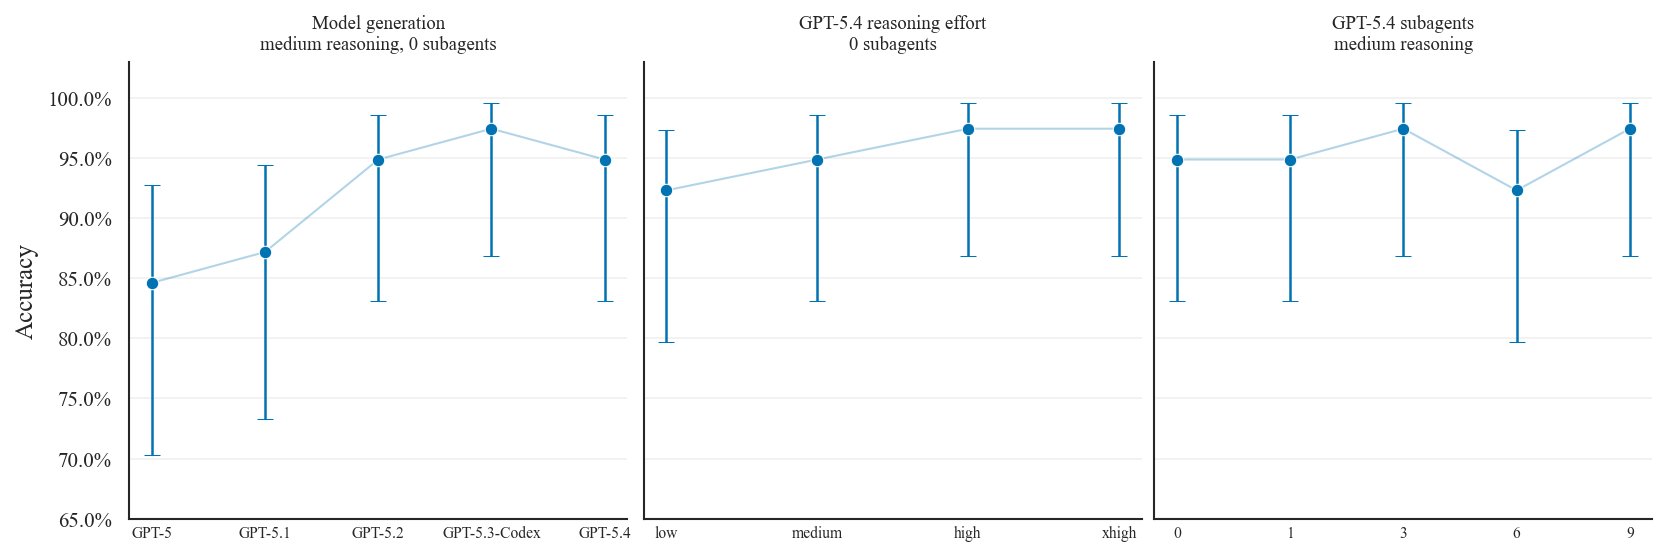

In [110]:
model_display = {
    "gpt-5": "GPT-5",
    "gpt-5.1": "GPT-5.1",
    "gpt-5.2": "GPT-5.2",
    "gpt-5.3-codex": "GPT-5.3-Codex",
    "gpt-5.4": "GPT-5.4",
}

codex_color = SCAFFOLD_COLORS["Codex CLI"]

fig, axes = plt.subplots(
    1, 3, figsize=(11, 3.6),
    constrained_layout=True, sharey=True,
)

panels = [
    (m_pts,  "Model generation\nmedium reasoning, 0 subagents", "Model"),
    (re_pts, "GPT-5.4 reasoning effort\n0 subagents",           "Reasoning effort"),
    (sa_pts, "GPT-5.4 subagents\nmedium reasoning",             "Subagents"),
]

for ax, (pts, title, xlab) in zip(axes, panels):
    xs, ys, los, his, ns = [], [], [], [], []
    for x, p, lo, hi, n in pts:
        xs.append(x)
        ns.append(n)
        if np.isnan(p):
            ys.append(np.nan); los.append(np.nan); his.append(np.nan)
        else:
            ys.append(p); los.append(p - lo); his.append(hi - p)

    xpos = np.arange(len(xs))
    ys  = np.asarray(ys)
    los = np.asarray(los)
    his = np.asarray(his)
    valid = ~np.isnan(ys)

    # Connecting line (light)
    ax.plot(
        xpos[valid], ys[valid],
        color=codex_color, linewidth=1, alpha=0.3, zorder=1,
    )

    ax.errorbar(
        xpos[valid], ys[valid],
        yerr=[los[valid], his[valid]],
        fmt="o", color=codex_color, ecolor=codex_color,
        capsize=4, capthick=1, elinewidth=1.2,
        markersize=6, markeredgecolor="white", markeredgewidth=0.5,
        zorder=3,
    )

    # Tick labels with n/N counts
    display_xs = []
    for x in xs:
        if x == "mt=0":
            display_xs.append("0")
        elif isinstance(x, str) and x.startswith("mt="):
            display_xs.append(x.replace("mt=", ""))
        else:
            display_xs.append(model_display.get(x, x))

    tick_labels = []
    for x_disp, y_val, n in zip(display_xs, ys, ns):
        if np.isnan(y_val):
            tick_labels.append(f"{x_disp}")
        else:
            k = round(y_val * n)
            tick_labels.append(f"{x_disp}")

    ax.set_xticks(xpos)
    ax.set_xticklabels(tick_labels, fontsize=7.5)
    ax.set_title(title, fontsize=9)
    ax.set_ylim(0.65, 1.03)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", length=0)

axes[0].set_ylabel("Accuracy")

savefig("codex_ablations.pdf")
savefig("codex_ablations.png")
plt.show()

## Efficiency analysis

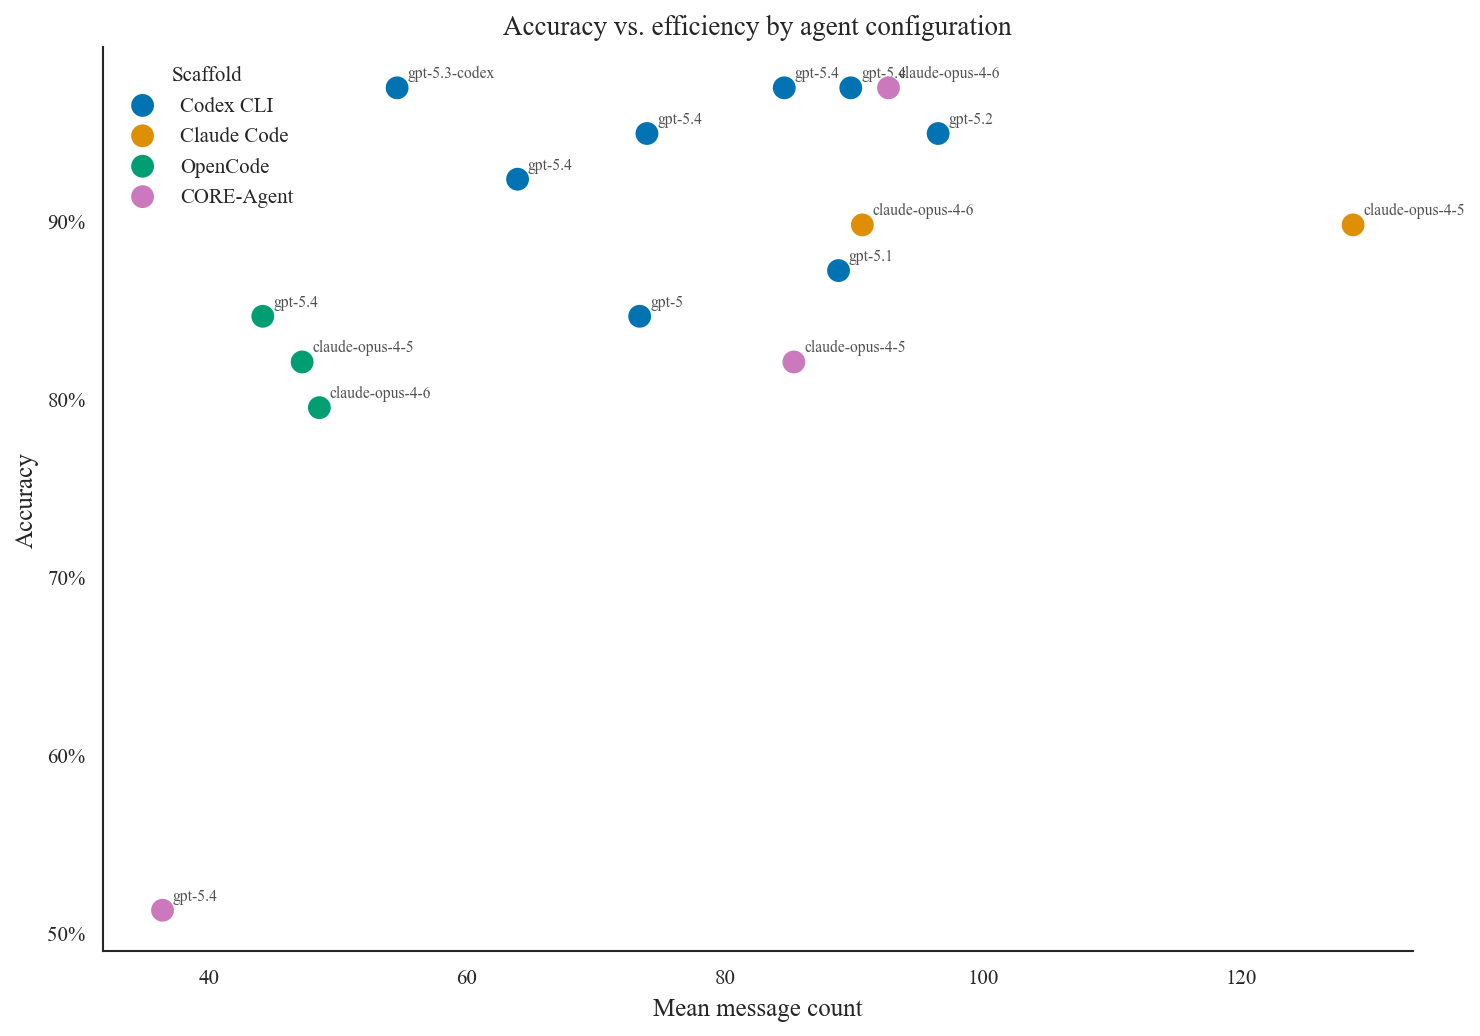

In [111]:
# 11a. Accuracy vs message count per config
fig, ax = plt.subplots(figsize=(10, 7))

for scaffold, color in SCAFFOLD_COLORS.items():
    subset = df_configs[df_configs["scaffold_family"] == scaffold]
    ax.scatter(subset["msg_mean"], subset["accuracy"],
              c=color, label=scaffold, s=120, edgecolors="none", linewidth=0.5, zorder=5)
    for _, r in subset.iterrows():
        ax.annotate(r["model_clean"], (r["msg_mean"], r["accuracy"]),
                   textcoords="offset points", xytext=(5, 5), fontsize=7.5, alpha=0.8)

# no text overlap 

ax.set_xlabel("Mean message count")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs. efficiency by agent configuration")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title="Scaffold", frameon=False)

plt.tight_layout()
plt.savefig(FIGDIR / "accuracy_vs_efficiency.pdf", bbox_inches="tight")
plt.show()

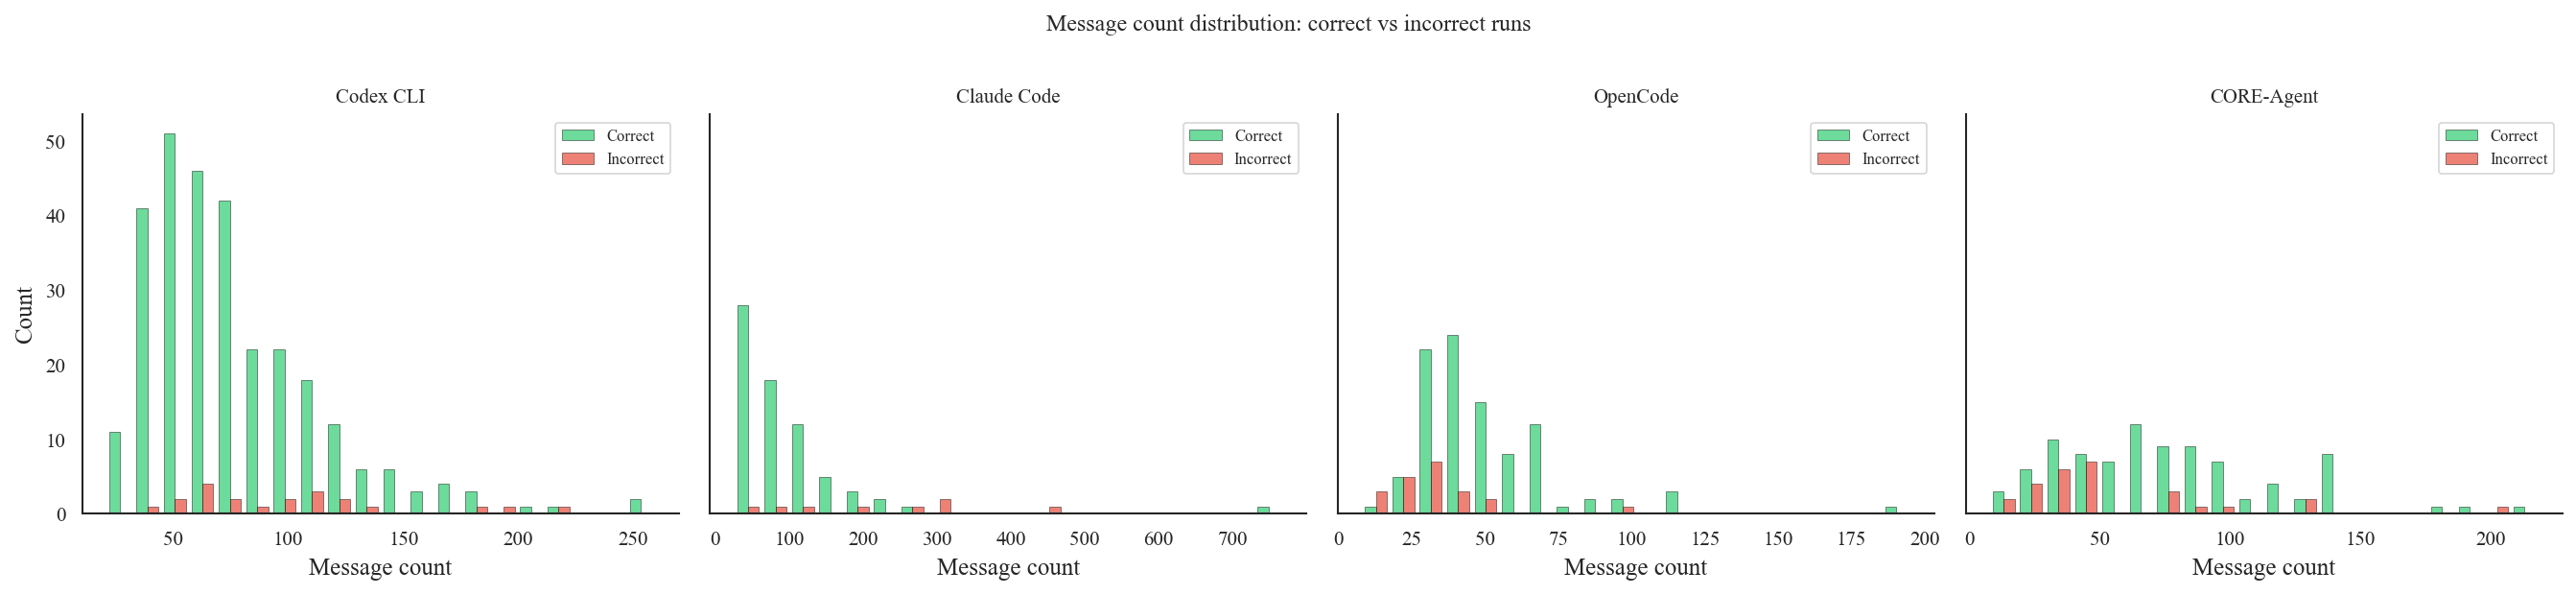

In [112]:
# Message count distributions by scaffold (correct vs incorrect)
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for i, scaffold in enumerate(SCAFFOLD_COLORS.keys()):
    s_df = df_default[df_default["scaffold_family"] == scaffold]
    if len(s_df) == 0:
        continue
    correct = s_df[s_df["accuracy"] == 1]["message_count"]
    incorrect = s_df[s_df["accuracy"] == 0]["message_count"]
    axes[i].hist([correct, incorrect], bins=20, label=["Correct", "Incorrect"],
                 color=["#2ecc71", "#e74c3c"], alpha=0.7, edgecolor="black", linewidth=0.3)
    axes[i].set_title(scaffold, fontsize=10)
    axes[i].set_xlabel("Message count")
    if i == 0:
        axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=8)

plt.suptitle("Message count distribution: correct vs incorrect runs", y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / "efficiency_distributions.pdf", bbox_inches="tight")
plt.show()

In [113]:
# Efficiency comparison: same accuracy, different cost
# Find configs with the same accuracy but different message counts
print("Configs at top accuracy (97.4%):")
top = df_configs[df_configs["accuracy"] >= 0.97].sort_values("msg_mean")
print(top[["config", "accuracy", "msg_mean", "msg_median"]].to_string(index=False))

print(f"\nMost efficient top performer: {top.iloc[0]['config']} (avg {top.iloc[0]['msg_mean']:.0f} messages)")
print(f"Least efficient top performer: {top.iloc[-1]['config']} (avg {top.iloc[-1]['msg_mean']:.0f} messages)")
print(f"Efficiency ratio: {top.iloc[-1]['msg_mean'] / top.iloc[0]['msg_mean']:.1f}x")

Configs at top accuracy (97.4%):
                                  config  accuracy  msg_mean  msg_median
      Codex CLI / gpt-5.3-codex / medium  0.974359 54.589744        47.0
              Codex CLI / gpt-5.4 / high  0.974359 84.589744        69.0
             Codex CLI / gpt-5.4 / xhigh  0.974359 89.743590        80.0
CORE-Agent / claude-opus-4-6 / steps=200  0.974359 92.666667        86.0

Most efficient top performer: Codex CLI / gpt-5.3-codex / medium (avg 55 messages)
Least efficient top performer: CORE-Agent / claude-opus-4-6 / steps=200 (avg 93 messages)
Efficiency ratio: 1.7x


## Key disagreement capsules for qualitative log analysis

Rank capsules by how much their outcome depends on the config. 

In [114]:
capsule_stats = df_default.groupby("capsule_id").agg(
    mean_acc=("accuracy", "mean"),
    std_acc=("accuracy", "std"),
    n_correct=("accuracy", "sum"),
    n_configs=("config", "nunique"),
).sort_values("std_acc", ascending=False)

capsule_stats["n_incorrect"] = capsule_stats["n_configs"] - capsule_stats["n_correct"]

print(f"All configs correct:  {(capsule_stats['mean_acc'] == 1.0).sum()} capsules")
print(f"All configs wrong:    {(capsule_stats['mean_acc'] == 0.0).sum()} capsules")
print(f"Config-dependent:     {((capsule_stats['mean_acc'] > 0) & (capsule_stats['mean_acc'] < 1)).sum()} capsules")
print(f"\nHighest-variance capsules (best for log analysis):")
print(capsule_stats.head(15).to_string())

All configs correct:  12 capsules
All configs wrong:    0 capsules
Config-dependent:     27 capsules

Highest-variance capsules (best for log analysis):
                 mean_acc   std_acc  n_correct  n_configs  n_incorrect
capsule_id                                                            
capsule-9477017    0.4375  0.512348        7.0         16          9.0
capsule-2804717    0.6875  0.478714       11.0         16          5.0
capsule-5136217    0.6875  0.478714       11.0         16          5.0
capsule-0851068    0.7500  0.447214       12.0         16          4.0
capsule-3762736    0.7500  0.447214       12.0         16          4.0
capsule-4252248    0.2500  0.447214        4.0         16         12.0
capsule-3821950    0.7500  0.447214       12.0         16          4.0
capsule-3593259    0.7500  0.447214       12.0         16          4.0
capsule-8807709    0.8125  0.403113       13.0         16          3.0
capsule-9832712    0.8125  0.403113       13.0         16         

In [115]:
# Detailed view of top 5 disagreement capsules
top_disagree = capsule_stats[
    (capsule_stats["mean_acc"] > 0) & (capsule_stats["mean_acc"] < 1)
].head(5).index.tolist()

for capsule in top_disagree:
    cap_df = df_default[df_default["capsule_id"] == capsule][
        ["config", "scaffold_family", "model_clean", "accuracy", "message_count", "has_error", "question_type"]
    ].sort_values("accuracy", ascending=False)

    mean_acc = capsule_stats.loc[capsule, "mean_acc"]
    qtype = cap_df["question_type"].iloc[0]
    print(f"\n{'='*80}")
    print(f"{capsule}  |  mean_acc={mean_acc:.0%}  |  type={qtype}")
    print(f"{'='*80}")
    print(cap_df[["config", "accuracy", "message_count", "has_error"]].to_string(index=False))


capsule-9477017  |  mean_acc=44%  |  type=vision_only
                                     config  accuracy  message_count  has_error
                Codex CLI / gpt-5.4 / xhigh       1.0             69      False
   CORE-Agent / claude-opus-4-5 / steps=200       1.0             88      False
                  OpenCode / gpt-5.4 / high       1.0             37      False
Claude Code / claude-opus-4-5 / think=10000       1.0             55      False
   CORE-Agent / claude-opus-4-6 / steps=200       1.0             94      False
                 Codex CLI / gpt-5.4 / high       1.0             61      False
               Codex CLI / gpt-5.1 / medium       1.0            114      False
               Codex CLI / gpt-5.4 / medium       0.0             56      False
                 Codex CLI / gpt-5 / medium       0.0             62      False
                 OpenCode / claude-opus-4-6       0.0             28       True
         Codex CLI / gpt-5.3-codex / medium       0.0            

## Summary statistics 

In [116]:
print(f"\n--- Dataset ---")
print(f"Runs: {len(df_default)} (excl. subagent sweep: {len(df) - len(df_default)})")
print(f"Capsules: {df_default['capsule_id'].nunique()}")
print(f"Configs: {df_default['config'].nunique()} (default) + {df_codex_full[df_codex_full['max_threads'].notna()]['config'].nunique()} (subagent variants)")
print(f"Scaffold families: {df_default['scaffold_family'].nunique()}")
print(f"Models: {df_default['model_clean'].nunique()}")

print(f"\n--- Accuracy ---")
print(f"Range: {df_configs['accuracy'].min():.1%} to {df_configs['accuracy'].max():.1%}")
print(f"Top accuracy (97.4%): {(df_configs['accuracy'] >= 0.97).sum()} configs")
n_saturated = (capsule_stats['mean_acc'] == 1.0).sum()
print(f"Capsules solved by ALL configs: {n_saturated}/39")

print(f"\n--- Scaffold effect (holding model constant) ---")
for _, row in scaffold_effect_df.iterrows():
    print(f"  {row['model']:20s}  spread={row['spread']:.1%}  ({row['best_scaffold']} {row['best_acc']:.1%} vs {row['worst_scaffold']} {row['worst_acc']:.1%})")

print(f"\n--- Model effect (holding scaffold constant) ---")
for _, row in model_effect_df.iterrows():
    print(f"  {row['scaffold']:15s}  spread={row['spread']:.1%}  ({row['best_model']} {row['best_acc']:.1%} vs {row['worst_model']} {row['worst_acc']:.1%})")

print(f"\n--- First-party advantage ---")
print(f"  FP wins: {n_fp_wins}, FP loses: {n_fp_loses}")
print(f"  Mean advantage: {fp_summary_df['advantage_pp'].mean():.1f} pp")
print(f"  Notable: Opus 4.6 + CORE-Agent (3rd party) beats Claude Code (1st party)")

print(f"\n--- Crossovers ---")
print(f"  {len(crossover_df)} cases where weaker model + better scaffold wins")
if len(crossover_df) > 0:
    print(f"  Largest gap: {crossover_df.iloc[0]['acc_gap']:.1%}")

print(f"\n--- Efficiency ---")
if len(top) > 0:
    print(f"  Most efficient 97.4% config: {top.iloc[0]['config']} ({top.iloc[0]['msg_mean']:.0f} msgs)")
    print(f"  Least efficient 97.4% config: {top.iloc[-1]['config']} ({top.iloc[-1]['msg_mean']:.0f} msgs)")
    print(f"  Ratio: {top.iloc[-1]['msg_mean'] / top.iloc[0]['msg_mean']:.1f}x")


--- Dataset ---
Runs: 624 (excl. subagent sweep: 156)
Capsules: 39
Configs: 16 (default) + 4 (subagent variants)
Scaffold families: 4
Models: 7

--- Accuracy ---
Range: 51.3% to 97.4%
Top accuracy (97.4%): 4 configs
Capsules solved by ALL configs: 12/39

--- Scaffold effect (holding model constant) ---
  gpt-5.4               spread=44.2%  (Codex CLI 95.5% vs CORE-Agent 51.3%)
  claude-opus-4-6       spread=17.9%  (CORE-Agent 97.4% vs OpenCode 79.5%)
  claude-opus-4-5       spread=7.7%  (Claude Code 89.7% vs CORE-Agent 82.1%)

--- Model effect (holding scaffold constant) ---
  CORE-Agent       spread=46.2%  (claude-opus-4-6 97.4% vs gpt-5.4 51.3%)
  Codex CLI        spread=12.8%  (gpt-5.3-codex 97.4% vs gpt-5 84.6%)
  OpenCode         spread=5.1%  (gpt-5.4 84.6% vs claude-opus-4-6 79.5%)
  Claude Code      spread=0.0%  (claude-opus-4-5 89.7% vs claude-opus-4-5 89.7%)

--- First-party advantage ---
  FP wins: 5, FP loses: 1
  Mean advantage: 12.2 pp
  Notable: Opus 4.6 + CORE-Agent (3r

In [117]:
# Reproducibility
RNG = np.random.default_rng(20260426)

print(f"Loaded {len(df)} runs across {df['capsule_id'].nunique()} capsules and {df['config'].nunique()} configs")
print(f"Default subset (no subagent variants): {len(df_default)} runs across {df_default['config'].nunique()} configs")

Loaded 780 runs across 39 capsules and 20 configs
Default subset (no subagent variants): 624 runs across 16 configs


## Variance decomposition (model vs scaffold vs interaction)

In [118]:
dec_df = df_canonical.copy()
cell_counts = dec_df.groupby(["model_clean", "scaffold_family"]).size()
keep_cells = cell_counts[cell_counts >= 5].index
dec_df = dec_df[dec_df.set_index(["model_clean", "scaffold_family"]).index.isin(keep_cells)].copy()
print(f"Variance decomposition input: {len(dec_df)} runs across "
      f"{dec_df['model_clean'].nunique()} models × {dec_df['scaffold_family'].nunique()} scaffolds "
      f"({dec_df['capsule_id'].nunique()} capsules, "
      f"{dec_df.groupby(['model_clean','scaffold_family']).ngroups} non-empty cells)")

formula_total_full = ("accuracy ~ C(capsule_id) + C(model_clean) + C(scaffold_family) "
                      "+ C(model_clean):C(scaffold_family)")
formula_total_add  = ("accuracy ~ C(capsule_id) + C(model_clean) + C(scaffold_family)")
formula_within_full = ("accuracy ~ C(model_clean) + C(scaffold_family) "
                       "+ C(model_clean):C(scaffold_family)")
formula_within_add  = ("accuracy ~ C(model_clean) + C(scaffold_family)")


def _eta_total(df_in):
    """Type I ANOVA with capsule as the first effect; interaction added by R² delta."""
    fit_full = ols(formula_total_full, data=df_in).fit()
    fit_add  = ols(formula_total_add,  data=df_in).fit()
    a = sm.stats.anova_lm(fit_add, typ=1)
    sst = a["sum_sq"].sum()
    eta_c = a.loc["C(capsule_id)", "sum_sq"] / sst
    eta_m = a.loc["C(model_clean)", "sum_sq"] / sst
    eta_s = a.loc["C(scaffold_family)", "sum_sq"] / sst
    eta_i = max(0.0, fit_full.rsquared - fit_add.rsquared)
    eta_r = max(0.0, 1.0 - eta_c - eta_m - eta_s - eta_i)
    return {"capsule": eta_c, "model": eta_m, "scaffold": eta_s,
            "interaction": eta_i, "residual": eta_r,
            "r2_full": fit_full.rsquared, "r2_add": fit_add.rsquared}


def _eta_within(df_in):
    """Type I ANOVA with capsule entered FIRST. Returns the share of
    NON-CAPSULE variance attributable to each effect (renormalized to sum=1).
    The interaction is added on top via R² delta from the additive model.
    """
    fit_full = ols(formula_total_full, data=df_in).fit()
    fit_add  = ols(formula_total_add,  data=df_in).fit()
    a = sm.stats.anova_lm(fit_add, typ=1)
    sst = a["sum_sq"].sum()
    ss_capsule = a.loc["C(capsule_id)", "sum_sq"]
    non_capsule_ss = sst - ss_capsule
    if non_capsule_ss <= 0:
        return {"model": 0.0, "scaffold": 0.0, "interaction": 0.0, "residual": 1.0,
                "r2_full": fit_full.rsquared, "r2_add": fit_add.rsquared}
    ss_model    = a.loc["C(model_clean)", "sum_sq"]
    ss_scaffold = a.loc["C(scaffold_family)", "sum_sq"]
    ss_inter    = max(0.0, (fit_full.rsquared - fit_add.rsquared) * sst)
    ss_residual = max(0.0, non_capsule_ss - ss_model - ss_scaffold - ss_inter)
    denom = ss_model + ss_scaffold + ss_inter + ss_residual
    return {"model": ss_model / denom,
            "scaffold": ss_scaffold / denom,
            "interaction": ss_inter / denom,
            "residual": ss_residual / denom,
            "r2_full": fit_full.rsquared, "r2_add": fit_add.rsquared}


# === TOTAL decomposition (capsule + model + scaffold + interaction + residual) ===
total = _eta_total(dec_df)
print("\n[TOTAL variance decomposition — run-level accuracy]")
print(f"  Capsule     : {total['capsule']*100:5.1f}%")
print(f"  Model       : {total['model']*100:5.1f}%")
print(f"  Scaffold    : {total['scaffold']*100:5.1f}%")
print(f"  Interaction : {total['interaction']*100:5.1f}%")
print(f"  Residual    : {total['residual']*100:5.1f}%")

eta_total_capsule = float(total["capsule"])
eta_total_model = float(total["model"])
eta_total_scaffold = float(total["scaffold"])
eta_total_interaction = float(total["interaction"])
eta_total_residual = float(total["residual"])

# === WITHIN-CAPSULE decomposition (model + scaffold + interaction + residual) ===
within = _eta_within(dec_df)
eta_model       = float(within["model"])
eta_scaffold    = float(within["scaffold"])
eta_interaction = float(within["interaction"])
eta_residual    = float(within["residual"])
print("\n[WITHIN-CAPSULE decomposition — re-normalized so sum=100%]")
print(f"  Model       : {eta_model*100:5.1f}%")
print(f"  Scaffold    : {eta_scaffold*100:5.1f}%")
print(f"  Interaction : {eta_interaction*100:5.1f}%")
print(f"  Residual    : {eta_residual*100:5.1f}%")
print(f"  R²(full) = {within['r2_full']:.3f}, R²(add) = {within['r2_add']:.3f}")


Variance decomposition input: 507 runs across 7 models × 4 scaffolds (39 capsules, 13 non-empty cells)

[TOTAL variance decomposition — run-level accuracy]
  Capsule     :  22.5%
  Model       :   3.1%
  Scaffold    :   3.5%
  Interaction :   4.4%
  Residual    :  66.5%

[WITHIN-CAPSULE decomposition — re-normalized so sum=100%]
  Model       :   4.0%
  Scaffold    :   4.5%
  Interaction :   5.6%
  Residual    :  85.9%
  R²(full) = 0.335, R²(add) = 0.291


In [119]:
# Bootstrap CIs on the within-capsule η² by resampling capsules
N_BOOT = 1000
boot_records_w = []
boot_records_t = []
capsules = dec_df["capsule_id"].unique()
groups = {c: dec_df[dec_df["capsule_id"] == c] for c in capsules}
for i in range(N_BOOT):
    chosen = RNG.choice(capsules, size=len(capsules), replace=True)
    boot = pd.concat([groups[c] for c in chosen], ignore_index=True)
    try:
        rec_w = _eta_within(boot)
        d = rec_w["model"] + rec_w["scaffold"] + rec_w["interaction"] + rec_w["residual"]
        if d > 0:
            boot_records_w.append({k: rec_w[k] / d for k in
                                   ["model", "scaffold", "interaction", "residual"]})
        rec_t = _eta_total(boot)
        boot_records_t.append({k: rec_t[k] for k in
                               ["capsule", "model", "scaffold", "interaction", "residual"]})
    except Exception:
        continue

boot_w = pd.DataFrame(boot_records_w)
boot_t = pd.DataFrame(boot_records_t)
print(f"\nBootstrap n={len(boot_w)}/{N_BOOT}")
ci = boot_w.quantile([0.025, 0.975])
ci_total = boot_t.quantile([0.025, 0.975])
print("95% bootstrap CIs on WITHIN-capsule η²:")
print(ci.round(4).to_string())
print("\n95% bootstrap CIs on TOTAL η²:")
print(ci_total.round(4).to_string())


Bootstrap n=1000/1000
95% bootstrap CIs on WITHIN-capsule η²:
        model  scaffold  interaction  residual
0.025  0.0224    0.0193       0.0248    0.7525
0.975  0.0889    0.0925       0.1005    0.9088

95% bootstrap CIs on TOTAL η²:
       capsule   model  scaffold  interaction  residual
0.025   0.1184  0.0173    0.0145       0.0197    0.5701
0.975   0.3175  0.0721    0.0794       0.0798    0.7448


In [120]:
# Mixed-effects logistic regression as a secondary check
# (binary outcome, capsule random intercept). Reports the share of capsule
# variance via intra-class correlation and the model/scaffold variance via
# permutation-style nested-LRT.
try:
    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
    bayes_df = dec_df.copy()
    bayes_df["accuracy_bin"] = bayes_df["accuracy"].astype(int)
    rfx = {"capsule": "0 + C(capsule_id)"}
    me = BinomialBayesMixedGLM.from_formula(
        "accuracy_bin ~ C(model_clean) + C(scaffold_family) + C(model_clean):C(scaffold_family)",
        rfx, bayes_df,
    )
    res = me.fit_vb()
    sigma_sq = float(np.exp(res.vcp_mean[0])) ** 2
    icc = sigma_sq / (sigma_sq + (math.pi ** 2) / 3)
    print(f"\nMixed-effects logistic regression (variational Bayes):")
    print(f"  Capsule random-effect SD: {math.sqrt(sigma_sq):.3f}")
    print(f"  Capsule ICC:              {icc:.3f}")
    print(f"  (latent-scale residual variance fixed at π²/3 ≈ 3.29 for binomial)")
except Exception as e:
    print(f"\nMixed-effects model not fit (continuing): {type(e).__name__}: {e}")


Mixed-effects logistic regression (variational Bayes):
  Capsule random-effect SD: 1.528
  Capsule ICC:              0.415
  (latent-scale residual variance fixed at π²/3 ≈ 3.29 for binomial)


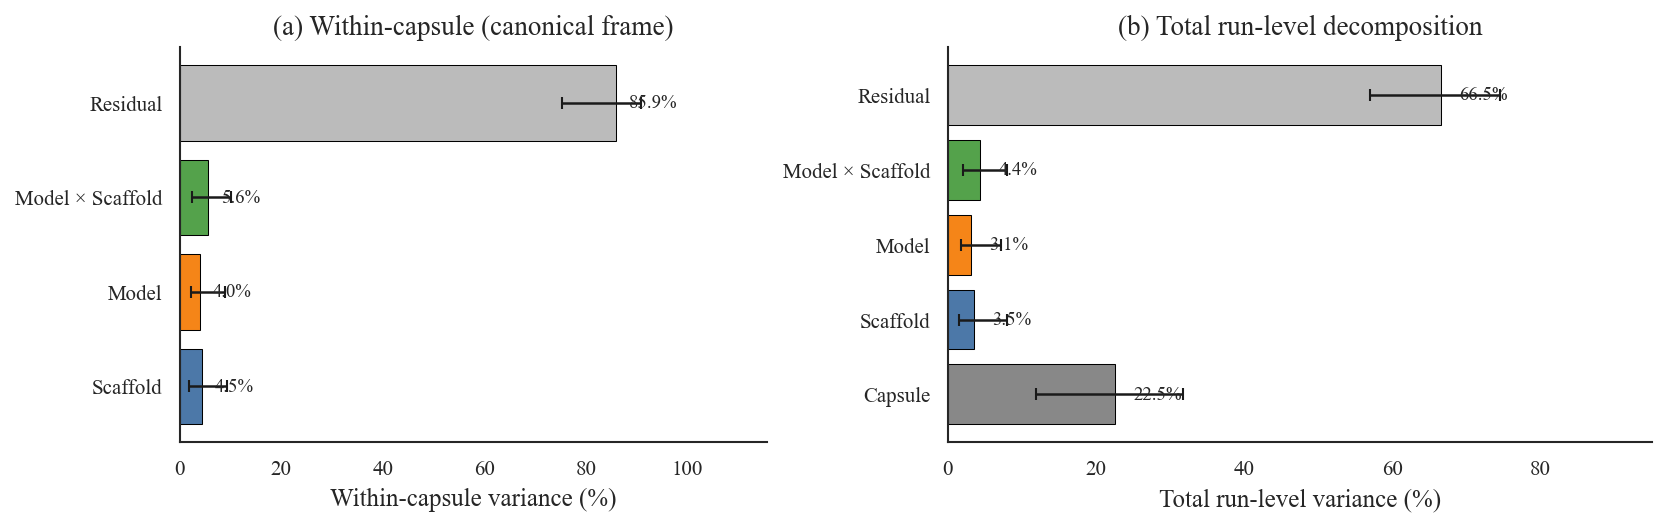

In [121]:
# Figure: variance decomposition with bootstrap 95% CIs and per-provider supporting panel.
# Three panels:
#  (a) within-capsule decomposition on the full data slice (HEADLINE FOR §5.2)
#  (b) total run-level decomposition with capsule term included
#  (c) per-model_provider within-capsule decomposition (SUPPORTING evidence;
#      each per-provider slice is itself non-fully-crossed)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), constrained_layout=True,
                         gridspec_kw={"width_ratios": [1.0, 1.2]})

# (a) Within-capsule, full data
labels_w = ["Scaffold", "Model", "Model × Scaffold", "Residual"]
values_w = [eta_scaffold * 100, eta_model * 100, eta_interaction * 100, eta_residual * 100]
los_w = [float(ci.loc[0.025, k]) * 100 for k in ["scaffold", "model", "interaction", "residual"]]
his_w = [float(ci.loc[0.975, k]) * 100 for k in ["scaffold", "model", "interaction", "residual"]]
xerr_w = np.array([np.maximum(0, np.asarray(values_w) - np.asarray(los_w)),
                   np.maximum(0, np.asarray(his_w) - np.asarray(values_w))])
colors_w = ["#4C78A8", "#F58518", "#54A24B", "#BBBBBB"]
y = np.arange(len(labels_w))
axes[0].barh(y, values_w, xerr=xerr_w, color=colors_w, edgecolor="black",
             linewidth=0.5, capsize=3)
for i, v in enumerate(values_w):
    axes[0].text(v + 2.5, i, f"{v:.1f}%", va="center", fontsize=9)
axes[0].set_yticks(y); axes[0].set_yticklabels(labels_w)
axes[0].set_xlabel("Within-capsule variance (%)")
axes[0].set_xlim(0, max(his_w) * 1.25 + 2)
axes[0].set_title("(a) Within-capsule (canonical frame)")

# (b) Total run-level
labels_t = ["Capsule", "Scaffold", "Model", "Model × Scaffold", "Residual"]
values_t = [eta_total_capsule * 100, eta_total_scaffold * 100, eta_total_model * 100,
            eta_total_interaction * 100, eta_total_residual * 100]
los_t = [float(ci_total.loc[0.025, k]) * 100 for k in
         ["capsule", "scaffold", "model", "interaction", "residual"]]
his_t = [float(ci_total.loc[0.975, k]) * 100 for k in
         ["capsule", "scaffold", "model", "interaction", "residual"]]
xerr_t = np.array([np.maximum(0, np.asarray(values_t) - np.asarray(los_t)),
                   np.maximum(0, np.asarray(his_t) - np.asarray(values_t))])
colors_t = ["#888888", "#4C78A8", "#F58518", "#54A24B", "#BBBBBB"]
y2 = np.arange(len(labels_t))
axes[1].barh(y2, values_t, xerr=xerr_t, color=colors_t, edgecolor="black",
             linewidth=0.5, capsize=3)
for i, v in enumerate(values_t):
    axes[1].text(v + 2.5, i, f"{v:.1f}%", va="center", fontsize=9)
axes[1].set_yticks(y2); axes[1].set_yticklabels(labels_t)
axes[1].set_xlabel("Total run-level variance (%)")
axes[1].set_xlim(0, max(his_t) * 1.25 + 2)
axes[1].set_title("(b) Total run-level decomposition")

fig.savefig(FIGDIR / "variance_decomposition.pdf")
fig.savefig(FIGDIR / "variance_decomposition.svg")
fig.savefig(FIGDIR / "variance_decomposition.png", dpi=300)
plt.show()

Concordance per (model, best TP):
          model fp_scaffold    tp_best  both  fp_only  tp_only  neither  n  mcnemar_p
claude-opus-4-5 Claude Code CORE-Agent    30        5        2        2 39   0.453125
claude-opus-4-6 Claude Code CORE-Agent    35        0        3        1 39   0.250000
        gpt-5.4   Codex CLI   OpenCode    31        6        2        0 39   0.289062


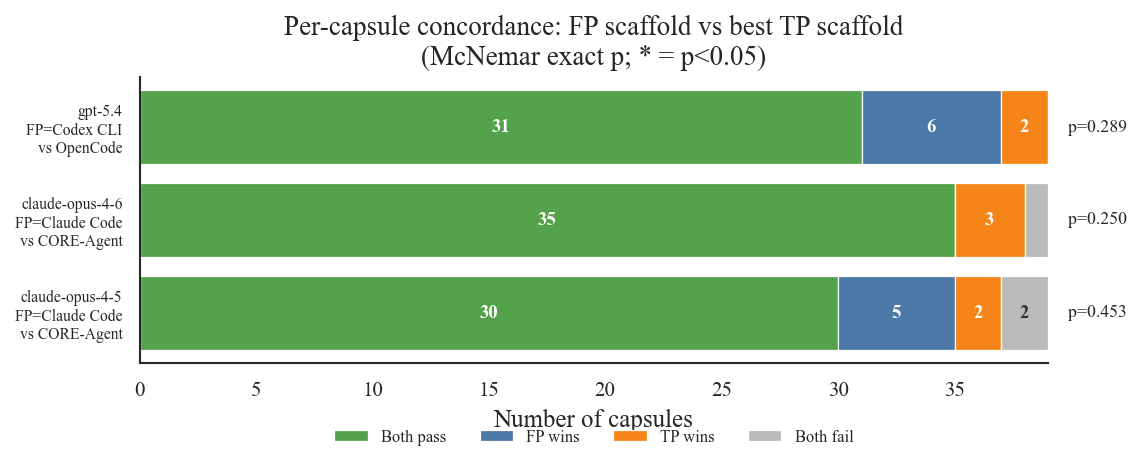

In [122]:
models_to_plot = fp_pairs_df["model"].unique().tolist()
records = []
for model in models_to_plot:
    m_runs = df_canonical[df_canonical["model_clean"] == model]
    fp_scaffold = "Codex CLI" if model.startswith("gpt-") else "Claude Code"
    tp_choices = [s for s in m_runs["scaffold_family"].unique() if s != fp_scaffold]
    if not tp_choices:
        continue
    # "Best" TP = highest mean accuracy
    tp_best = m_runs[m_runs["scaffold_family"].isin(tp_choices)] \
        .groupby("scaffold_family")["accuracy"].mean().idxmax()
    # df_canonical is 1-row-per-(capsule, scaffold) so direct merge is correct
    fp_side = m_runs[m_runs["scaffold_family"] == fp_scaffold][["capsule_id", "accuracy"]] \
        .rename(columns={"accuracy": "fp"})
    tp_side = m_runs[m_runs["scaffold_family"] == tp_best][["capsule_id", "accuracy"]] \
        .rename(columns={"accuracy": "tp"})
    paired = pd.merge(fp_side, tp_side, on="capsule_id")
    paired["fp"] = paired["fp"].astype(int)
    paired["tp"] = paired["tp"].astype(int)
    fp = paired["fp"]; tp = paired["tp"]
    if paired.empty:
        continue
    both = int(((fp == 1) & (tp == 1)).sum())
    fp_only = int(((fp == 1) & (tp == 0)).sum())
    tp_only = int(((fp == 0) & (tp == 1)).sum())
    neither = int(((fp == 0) & (tp == 0)).sum())
    # McNemar p
    if fp_only + tp_only == 0:
        p = 1.0
    else:
        from statsmodels.stats.contingency_tables import mcnemar
        p = float(mcnemar([[both, fp_only], [tp_only, neither]], exact=True).pvalue)
    records.append({
        "model": model, "fp_scaffold": fp_scaffold, "tp_best": tp_best,
        "both": both, "fp_only": fp_only, "tp_only": tp_only, "neither": neither,
        "n": both + fp_only + tp_only + neither,
        "mcnemar_p": p,
    })

conc_df = pd.DataFrame(records)
print("Concordance per (model, best TP):")
print(conc_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(7.5, max(3.0, 0.55 * len(conc_df))),
                       constrained_layout=True)
y = np.arange(len(conc_df))
# segment colors: both = green, fp_only = blue (FP wins), tp_only = orange (TP wins), neither = grey
seg_colors = {"both": "#54A24B", "fp_only": "#4C78A8",
              "tp_only": "#F58518", "neither": "#BBBBBB"}
seg_labels = {"both": "Both pass", "fp_only": "FP wins", "tp_only": "TP wins", "neither": "Both fail"}
left = np.zeros(len(conc_df))
for seg in ["both", "fp_only", "tp_only", "neither"]:
    vals = conc_df[seg].values
    ax.barh(y, vals, left=left, color=seg_colors[seg], edgecolor="white",
            linewidth=0.6, label=seg_labels[seg])
    for i, v in enumerate(vals):
        if v >= 2:
            ax.text(left[i] + v/2, i, str(int(v)), ha="center", va="center",
                    fontsize=9, color="white" if seg != "neither" else "#333", fontweight="bold")
    left = left + vals

# Annotation: McNemar p
for i, (_, r) in enumerate(conc_df.iterrows()):
    star = "*" if r["mcnemar_p"] < 0.05 else ""
    ax.text(r["n"] + 0.5, i, f"  p={r['mcnemar_p']:.3f}{star}", va="center", fontsize=8.5)

ax.set_yticks(y)
ax.set_yticklabels([f"{r['model']}\nFP={r['fp_scaffold']}\nvs {r['tp_best']}"
                     for _, r in conc_df.iterrows()], fontsize=7.5)
ax.set_xlabel("Number of capsules")
ax.set_title("Per-capsule concordance: FP scaffold vs best TP scaffold\n(McNemar exact p; * = p<0.05)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, fontsize=8, frameon=False)
fig.savefig(FIGDIR / "first_party_concordance.pdf")
fig.savefig(FIGDIR / "first_party_concordance.png", dpi=300)
plt.show()


## Accuracy vs efficiency — Pareto frontier

In [123]:
eff = df_configs[["config", "scaffold_family", "model_clean", "accuracy",
                  "msg_mean", "n", "ci_lo", "ci_hi"]].dropna(subset=["msg_mean"]).copy()

# Pareto: a config is Pareto-efficient if no other config has BOTH higher accuracy
# AND lower mean message count. Ties broken in the candidate's favor.
def is_pareto_efficient(eff_df):
    flags = np.ones(len(eff_df), dtype=bool)
    accs = eff_df["accuracy"].to_numpy()
    msgs = eff_df["msg_mean"].to_numpy()
    for i in range(len(eff_df)):
        dominated = ((accs >= accs[i]) & (msgs <= msgs[i]) &
                     ((accs > accs[i]) | (msgs < msgs[i])))
        if dominated.any():
            flags[i] = False
    return flags

eff["pareto"] = is_pareto_efficient(eff)
print(f"Pareto-efficient configs: {eff['pareto'].sum()} / {len(eff)}")
print(eff[eff["pareto"]].sort_values("msg_mean").to_string(index=False))

# Spearman correlation with bootstrap CI (resample configs, not capsules)
rho_obs, p_obs = sp_stats.spearmanr(eff["msg_mean"], eff["accuracy"])
rng_eff = np.random.default_rng(7)
n_boot = 5000
rhos = np.empty(n_boot)
for i in range(n_boot):
    idx = rng_eff.choice(len(eff), size=len(eff), replace=True)
    sample = eff.iloc[idx]
    if sample["msg_mean"].nunique() < 2 or sample["accuracy"].nunique() < 2:
        rhos[i] = np.nan
        continue
    rhos[i], _ = sp_stats.spearmanr(sample["msg_mean"], sample["accuracy"])
rhos = rhos[~np.isnan(rhos)]
rho_lo, rho_hi = np.quantile(rhos, [0.025, 0.975])
print(f"\nSpearman ρ(msg_count, accuracy) = {rho_obs:+.3f} "
      f"(95% CI [{rho_lo:+.3f}, {rho_hi:+.3f}], p={p_obs:.3g})")

Pareto-efficient configs: 3 / 16
                            config scaffold_family   model_clean  accuracy  msg_mean  n    ci_lo    ci_hi  pareto
  CORE-Agent / gpt-5.4 / steps=200      CORE-Agent       gpt-5.4  0.512821 36.410256 39 0.361994 0.661348    True
         OpenCode / gpt-5.4 / high        OpenCode       gpt-5.4  0.846154 44.179487 39 0.702705 0.927525    True
Codex CLI / gpt-5.3-codex / medium       Codex CLI gpt-5.3-codex  0.974359 54.589744 39 0.868190 0.995459    True

Spearman ρ(msg_count, accuracy) = +0.523 (95% CI [+0.008, +0.825], p=0.0376)


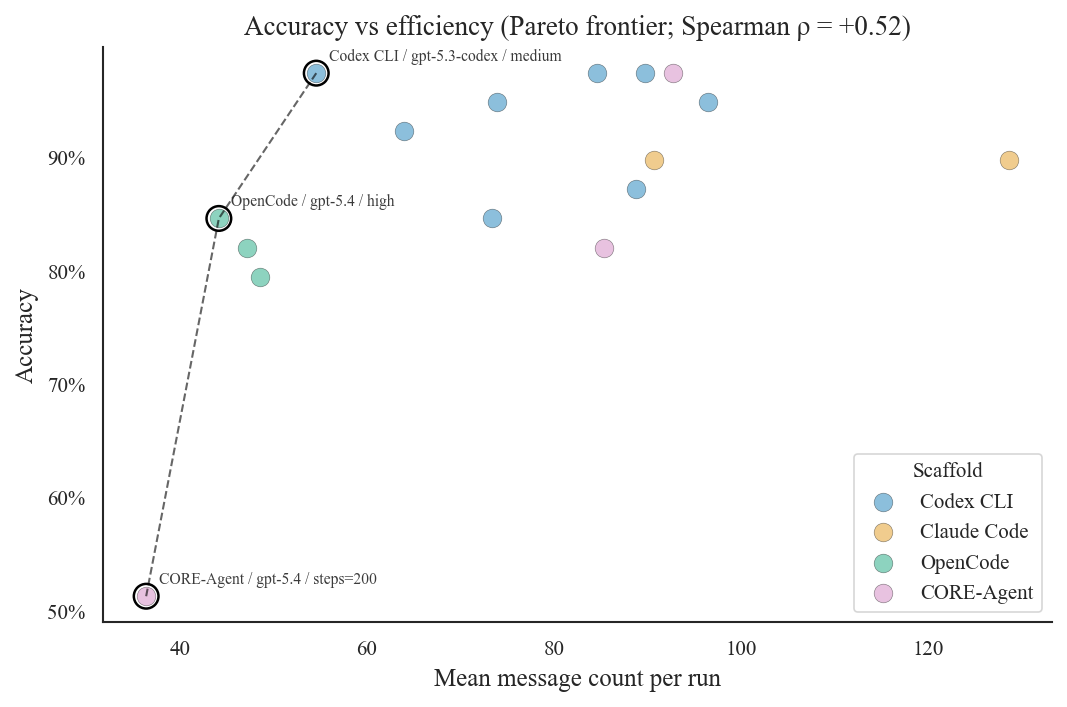

In [124]:
fig, ax = plt.subplots(figsize=(7.0, 4.6), constrained_layout=True)
for sf, color in SCAFFOLD_COLORS.items():
    sub = eff[eff["scaffold_family"] == sf]
    ax.scatter(sub["msg_mean"], sub["accuracy"],
               s=80, c=color, label=sf, alpha=0.45,
               edgecolors="black", linewidth=0.3, zorder=2)

# Highlight Pareto frontier
pf = eff[eff["pareto"]].sort_values("msg_mean")
ax.plot(pf["msg_mean"], pf["accuracy"], color="black", linewidth=1.0,
        linestyle="--", zorder=3, alpha=0.6)
for _, r in pf.iterrows():
    ax.scatter([r["msg_mean"]], [r["accuracy"]],
               s=140, facecolors="none", edgecolor="black", linewidth=1.2, zorder=4)
    ax.annotate(r["config"], (r["msg_mean"], r["accuracy"]),
                xytext=(6, 6), textcoords="offset points",
                fontsize=7.5, alpha=0.9)

ax.set_xlabel("Mean message count per run")
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title(f"Accuracy vs efficiency (Pareto frontier; Spearman ρ = {rho_obs:+.2f})")
ax.legend(title="Scaffold", loc="lower right")
fig.savefig(FIGDIR / "accuracy_vs_efficiency.pdf")
fig.savefig(FIGDIR / "accuracy_vs_efficiency.svg")
fig.savefig(FIGDIR / "accuracy_vs_efficiency.png", dpi=300)
plt.show()

## Per-capsule variance attribution

Capsules with usable per-capsule decomposition: 27/39
quadrant
scaffold_dominated    14
model_dominated        7
mixed                  6
Name: count, dtype: int64
  Degenerate (η²≈1): 2


/var/folders/mt/fzt_rckj79x893_9z9kh5jbm0000gn/T/ipykernel_22822/2078658757.py:53: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(deg["model_eta"], deg["scaffold_eta"],


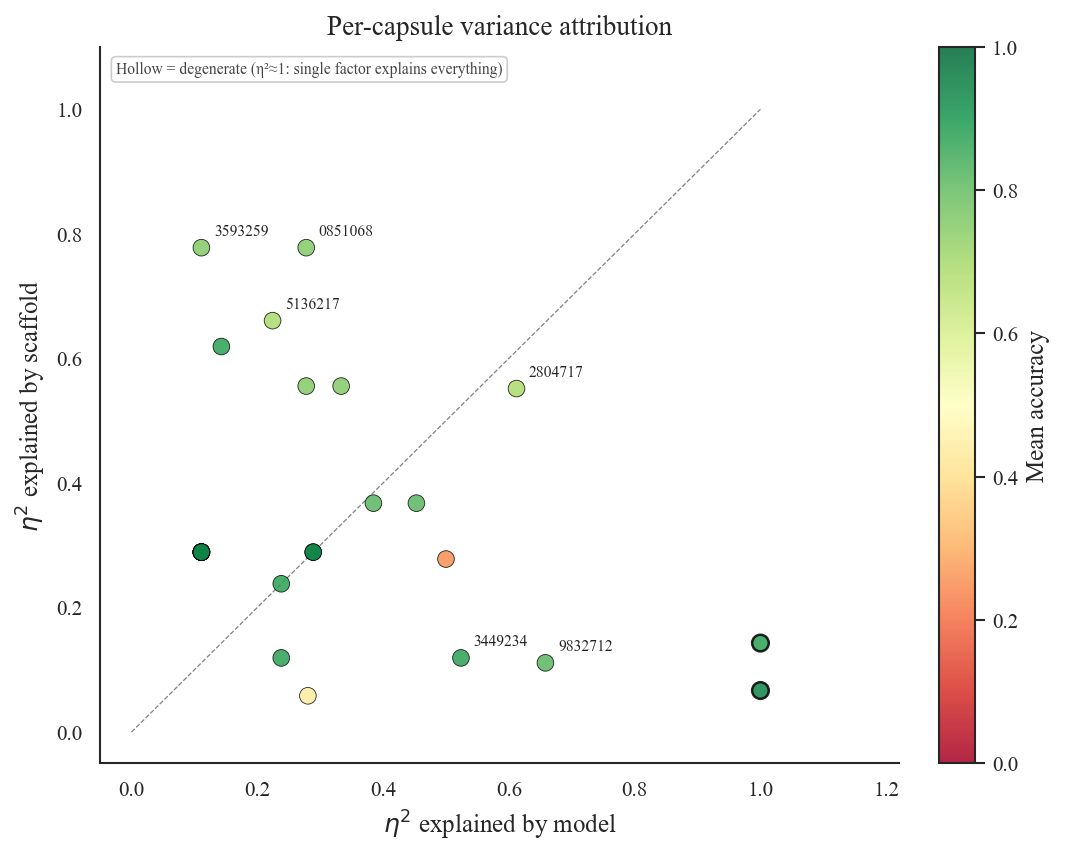

In [ ]:
def eta_sq_within(grp, factor):
    valid = grp.dropna(subset=["accuracy"])
    if valid[factor].nunique() < 2 or len(valid) < 4:
        return np.nan
    grand = valid["accuracy"].mean()
    ss_between = sum(len(g) * (g["accuracy"].mean() - grand) ** 2
                     for _, g in valid.groupby(factor))
    ss_total = ((valid["accuracy"] - grand) ** 2).sum()
    return ss_between / ss_total if ss_total > 0 else np.nan

per_cap = []
for cap, grp in df_default.groupby("capsule_id"):
    per_cap.append({
        "capsule_id": cap,
        "n": len(grp),
        "mean_acc": float(grp["accuracy"].mean()),
        "model_eta": eta_sq_within(grp, "model_clean"),
        "scaffold_eta": eta_sq_within(grp, "scaffold_family"),
    })
per_cap_df = pd.DataFrame(per_cap).dropna(subset=["model_eta", "scaffold_eta"])
print(f"Capsules with usable per-capsule decomposition: {len(per_cap_df)}/39")

# Quadrant labels
def quadrant(r):
    if r["mean_acc"] in (0.0, 1.0):
        return "saturated"
    if r["scaffold_eta"] >= r["model_eta"] + 0.1:
        return "scaffold_dominated"
    if r["model_eta"] >= r["scaffold_eta"] + 0.1:
        return "model_dominated"
    return "mixed"
per_cap_df["quadrant"] = per_cap_df.apply(quadrant, axis=1)
per_cap_df["degenerate"] = (
    (per_cap_df["model_eta"] >= 0.999) | (per_cap_df["scaffold_eta"] >= 0.999)
)
print(per_cap_df["quadrant"].value_counts())
print(f"  Degenerate (η²≈1): {per_cap_df['degenerate'].sum()}")

fig, ax = plt.subplots(figsize=(7.0, 5.6), constrained_layout=True)

# Non-degenerate points: filled circles
nd = per_cap_df[~per_cap_df["degenerate"]]
sc1 = ax.scatter(nd["model_eta"], nd["scaffold_eta"],
                 c=nd["mean_acc"], cmap="RdYlGn",
                 s=nd["n"] * 4, alpha=0.85, vmin=0, vmax=1,
                 edgecolors="black", linewidth=0.4, zorder=3)
# Degenerate points: hollow circles in same color map
deg = per_cap_df[per_cap_df["degenerate"]]
ax.scatter(deg["model_eta"], deg["scaffold_eta"],
           c=deg["mean_acc"], cmap="RdYlGn",
           s=deg["n"] * 4, alpha=0.85, vmin=0, vmax=1,
           edgecolors="black", linewidth=1.2, facecolors="none", zorder=3)

ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=0.6)
ax.set_xlim(-0.05, 1.22)
ax.set_ylim(-0.05, 1.10)
ax.set_xlabel(r"$\eta^2$ explained by model")
ax.set_ylabel(r"$\eta^2$ explained by scaffold")
ax.set_title("Per-capsule variance attribution")
plt.colorbar(sc1, ax=ax, label="Mean accuracy")

# Label top-3 per quadrant (excluding degenerate)
top_scaffold = nd.sort_values("scaffold_eta", ascending=False).head(3)
top_model = nd.sort_values("model_eta", ascending=False).head(3)
for _, r in pd.concat([top_scaffold, top_model]).drop_duplicates("capsule_id").iterrows():
    short = r["capsule_id"].replace("capsule-", "")
    ax.annotate(short, (r["model_eta"], r["scaffold_eta"]),
                xytext=(6, 6), textcoords="offset points", fontsize=7.5,
                color="#222")

# Note about hollow markers
ax.text(0.02, 0.98, "Hollow = degenerate (η²≈1: single factor explains everything)",
        transform=ax.transAxes, fontsize=7.5, va="top", color="#444",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#ccc"))

fig.savefig(FIGDIR / "per_capsule_variance.pdf")
fig.savefig(FIGDIR / "per_capsule_variance.png", dpi=300)
plt.show()

## Robustness checks

In [126]:
# (a) Variance decomposition excluding saturated capsules
sat = capsule_stats[(capsule_stats["mean_acc"] == 0) | (capsule_stats["mean_acc"] == 1)].index
robust_df = dec_df[~dec_df["capsule_id"].isin(sat)].copy()
print(f"Excluding {len(sat)} saturated capsules ({(per_cap_df['mean_acc'].isin([0,1]).sum())} all-pass/all-fail)")
print(f"Robust subset: {len(robust_df)} runs across {robust_df['capsule_id'].nunique()} capsules")
if len(robust_df) > 30 and robust_df["accuracy"].std() > 0:
    rec = _eta_within(robust_df)
    print("Robustness η² (saturated capsules excluded):")
    for k in ["model", "scaffold", "interaction", "residual"]:
        print(f"  {k:11s} {rec[k]:.4f} ({rec[k]*100:.1f}%)")

# (b) Sensitivity using `reward` instead of `accuracy`
if dec_df["accuracy"].notna().sum() > 30:
    reward_df = dec_df.dropna(subset=["accuracy"]).copy()
    fit_rw_add  = ols("accuracy ~ C(model_clean) + C(scaffold_family)", data=reward_df).fit()
    fit_rw_full = ols("accuracy ~ C(model_clean) + C(scaffold_family) + C(model_clean):C(scaffold_family)", data=reward_df).fit()
    a_rw = sm.stats.anova_lm(fit_rw_add, typ=1)
    sst = a_rw["sum_sq"].sum()
    eta_m_rw = a_rw.loc["C(model_clean)", "sum_sq"] / sst
    eta_s_rw = a_rw.loc["C(scaffold_family)", "sum_sq"] / sst
    eta_i_rw = max(0.0, fit_rw_full.rsquared - fit_rw_add.rsquared)
    print("\nReward-as-outcome η² (Type I additive + R² delta):")
    print(f"  Model       : {eta_m_rw:.4f} ({eta_m_rw*100:.1f}%)")
    print(f"  Scaffold    : {eta_s_rw:.4f} ({eta_s_rw*100:.1f}%)")
    print(f"  Interaction : {eta_i_rw:.4f} ({eta_i_rw*100:.1f}%)")


Excluding 12 saturated capsules (0 all-pass/all-fail)
Robust subset: 351 runs across 27 capsules
Robustness η² (saturated capsules excluded):
  model       0.0577 (5.8%)
  scaffold    0.0647 (6.5%)
  interaction 0.0813 (8.1%)
  residual    0.7962 (79.6%)

Reward-as-outcome η² (Type I additive + R² delta):
  Model       : 0.0309 (3.1%)
  Scaffold    : 0.0347 (3.5%)
  Interaction : 0.0436 (4.4%)


---
## Sensitivity diagnostics

Recompute the headline numbers across five data slices BEFORE redesigning any
plot or rewriting any prose. The slices are:

- **all** — full v1.1 default subset (everything we report on by default).
- **anthropic_models** / **openai_models** — stratified by model_provider.
  Each slice is itself non-fully-crossed; treat as supporting evidence only.
- **no_core_agent** — drops the entire CORE-Agent family.
- **no_gpt54_ca** — drops only the GPT-5.4 + CORE-Agent compatibility-failure
  cell. Used as a sensitivity check for headline robustness.

The cell below prints a delta table; we use the printed deltas to decide
which gated Phase 2 plots to redesign.


In [127]:
# sensitivity slices
# (df_default already exists; we just produce 5 views and stash diagnostics for each)
SLICES = {
    "all":              df_default.copy(),
    "anthropic_models": df_default[df_default["model_provider"] == "Anthropic"].copy(),
    "openai_models":    df_default[df_default["model_provider"] == "OpenAI"].copy(),
    "no_core_agent":    df_default[df_default["scaffold_family"] != "CORE-Agent"].copy(),
    "no_gpt54_ca":      df_default[~((df_default["model_clean"] == "gpt-5.4") &
                                      (df_default["scaffold_family"] == "CORE-Agent"))].copy(),
}

print("Slice sizes:")
for name, sl in SLICES.items():
    n_models = sl["model_clean"].nunique()
    n_scaffolds = sl["scaffold_family"].nunique()
    print(f"  {name:18s} n_runs={len(sl):4d}  n_models={n_models}  n_scaffolds={n_scaffolds}  "
          f"n_capsules={sl['capsule_id'].nunique()}")


Slice sizes:
  all                n_runs= 624  n_models=7  n_scaffolds=4  n_capsules=39
  anthropic_models   n_runs= 234  n_models=2  n_scaffolds=3  n_capsules=39
  openai_models      n_runs= 390  n_models=5  n_scaffolds=3  n_capsules=39
  no_core_agent      n_runs= 507  n_models=7  n_scaffolds=3  n_capsules=39
  no_gpt54_ca        n_runs= 585  n_models=7  n_scaffolds=4  n_capsules=39


In [128]:
# Variance decomposition per slice (within-capsule + total)
slice_eta_within = {}
slice_eta_total  = {}

for name, sl in SLICES.items():
    if len(sl) < 30 or sl["scaffold_family"].nunique() < 2 or sl["model_clean"].nunique() < 2:
        print(f"  {name:18s} SKIPPED (too few runs, scaffolds, or models)")
        slice_eta_within[name] = {"model": np.nan, "scaffold": np.nan,
                                   "interaction": np.nan, "residual": np.nan}
        slice_eta_total[name] = {"capsule": np.nan, "model": np.nan, "scaffold": np.nan,
                                  "interaction": np.nan, "residual": np.nan}
        continue
    # Need cells with ≥5 runs each — the same filter we use in §5.2
    cell_counts = sl.groupby(["model_clean", "scaffold_family"]).size()
    keep_cells = cell_counts[cell_counts >= 5].index
    sl_dec = sl[sl.set_index(["model_clean", "scaffold_family"]).index.isin(keep_cells)].copy()
    if len(sl_dec) < 30:
        print(f"  {name:18s} SKIPPED after cell filter (only {len(sl_dec)} runs left)")
        slice_eta_within[name] = {"model": np.nan, "scaffold": np.nan,
                                   "interaction": np.nan, "residual": np.nan}
        slice_eta_total[name] = {"capsule": np.nan, "model": np.nan, "scaffold": np.nan,
                                  "interaction": np.nan, "residual": np.nan}
        continue
    try:
        slice_eta_within[name] = _eta_within(sl_dec)
        slice_eta_total[name]  = _eta_total(sl_dec)
    except Exception as e:
        print(f"  {name:18s} FIT FAILED: {type(e).__name__}: {e}")
        slice_eta_within[name] = {"model": np.nan, "scaffold": np.nan,
                                   "interaction": np.nan, "residual": np.nan}
        slice_eta_total[name] = {"capsule": np.nan, "model": np.nan, "scaffold": np.nan,
                                  "interaction": np.nan, "residual": np.nan}

# Tabulate
print("\n=== Within-capsule η² per slice ===")
print(f"{'slice':18s} {'model':>8} {'scaffold':>9} {'interact':>9} {'residual':>9} {'sc/md':>6}")
for name, ev in slice_eta_within.items():
    ratio = ev["scaffold"] / ev["model"] if (ev["model"] and ev["model"] > 0) else np.nan
    print(f"{name:18s} {ev['model']*100:7.2f}% {ev['scaffold']*100:8.2f}% "
          f"{ev['interaction']*100:8.2f}% {ev['residual']*100:8.2f}% {ratio:6.2f}")

# Stash macros: model_provider-stratified within-capsule η²
def _safe(v):
    return float(v) * 100 if (v is not None and np.isfinite(v)) else np.nan

for name, ev in slice_eta_within.items():
    safe_name = name.replace("_", "")

# Asymmetry-trigger key
def _ratio(d):
    return (d["scaffold"] / d["model"]) if (d["model"] and d["model"] > 0) else np.nan

ratio_anth = _ratio(slice_eta_within.get("anthropic_models", {}))
ratio_oa   = _ratio(slice_eta_within.get("openai_models", {}))
print(f"\nProvider η²(scaffold)/η²(model) ratios: anthropic={ratio_anth:.2f}, openai={ratio_oa:.2f}")
print(f"Trigger for gated panel (c) on variance_decomposition.pdf: ratio diverges by ≥ 2× — "
      f"{'YES' if abs(ratio_anth - ratio_oa) >= 2 else 'no'}")


=== Within-capsule η² per slice ===
slice                 model  scaffold  interact  residual  sc/md
all                   1.50%     8.07%     5.16%    85.28%   5.39
anthropic_models      0.69%     2.70%     2.37%    94.24%   3.92
openai_models         2.01%    19.12%     0.00%    78.87%   9.52
no_core_agent         3.24%     2.16%     0.02%    94.58%   0.67
no_gpt54_ca           2.67%     2.06%     0.96%    94.31%   0.77

Provider η²(scaffold)/η²(model) ratios: anthropic=3.92, openai=9.52
Trigger for gated panel (c) on variance_decomposition.pdf: ratio diverges by ≥ 2× — YES


In [129]:
# Efficiency Spearman per slice
print("\n=== Spearman ρ(message_count, accuracy) per slice ===")
print(f"{'slice':18s} {'rho':>8} {'p':>8}")
rho_all = np.nan
rho_no = np.nan
for name, sl in SLICES.items():
    # Aggregate to per-config first
    agg = sl.groupby("config").agg(accuracy=("accuracy", "mean"),
                                    msg_mean=("message_count", "mean"),
                                    n=("accuracy", "count")).reset_index()
    if len(agg) < 4:
        print(f"{name:18s} (too few configs: {len(agg)})")
        continue
    rho, p = sp_stats.spearmanr(agg["msg_mean"], agg["accuracy"])
    print(f"{name:18s} {rho:+7.3f} {p:7.3g}")
    if name == "all":
        rho_all = rho
    elif name == "no_gpt54_ca":
        rho_no = rho

# Trigger check
delta = abs(rho_all - rho_no) if (np.isfinite(rho_all) and np.isfinite(rho_no)) else 0
print(f"\nΔρ (all vs no_gpt54_ca) = {delta:.3f}")
print(f"Trigger for gated annotation on accuracy_vs_efficiency.pdf: |Δρ| ≥ 0.15 — "
      f"{'YES' if delta >= 0.15 else 'no'}")



=== Spearman ρ(message_count, accuracy) per slice ===
slice                   rho        p
all                 +0.523  0.0376
anthropic_models    +0.794   0.059
openai_models       +0.531   0.114
no_core_agent       +0.444   0.129
no_gpt54_ca         +0.420    0.12

Δρ (all vs no_gpt54_ca) = 0.103
Trigger for gated annotation on accuracy_vs_efficiency.pdf: |Δρ| ≥ 0.15 — no


In [130]:
# Per-model scaffold range (max acc − min acc across scaffolds), and
# compatibility-asymmetry summary (OpenAI scaffold-range vs Anthropic scaffold-range).
sd = {}
for model, grp in df_canonical.groupby("model_clean"):
    accs = grp.groupby("scaffold_family")["accuracy"].mean()
    if len(accs) < 2:
        continue
    sd[model] = {
        "best_scaffold":  accs.idxmax(),
        "best_acc":       float(accs.max()),
        "worst_scaffold": accs.idxmin(),
        "worst_acc":      float(accs.min()),
        "range":          float(accs.max() - accs.min()),
        "n_scaffolds":    int(len(accs)),
    }

print("Per-model scaffold range:")
for m, d in sd.items():
    print(f"  {m:20s} best={d['best_scaffold']:11s} ({d['best_acc']:.1%})  "
          f"worst={d['worst_scaffold']:11s} ({d['worst_acc']:.1%})  range={d['range']:.1%}")

# Per-model min/max FP advantage across third-party scaffolds (replaces the
# "vs best TP" framing with explicit min/max)
fp_pairs = []
for model, grp in df_canonical.groupby("model_clean"):
    if model not in sd: continue
    fp_scaffold = ("Codex CLI" if model.startswith("gpt-")
                   else "Claude Code" if (model.startswith("claude") or model.startswith("opus"))
                   else None)
    if fp_scaffold is None: continue
    fp_runs = grp[grp["scaffold_family"] == fp_scaffold]
    if fp_runs.empty: continue
    fp_acc = float(fp_runs["accuracy"].mean())
    tps = grp[grp["scaffold_family"] != fp_scaffold]
    for tp_scaffold, tp_grp in tps.groupby("scaffold_family"):
        tp_acc = float(tp_grp["accuracy"].mean())
        fp_pairs.append({
            "model": model, "fp_scaffold": fp_scaffold, "tp_scaffold": tp_scaffold,
            "fp_acc": fp_acc, "tp_acc": tp_acc,
            "advantage_pp": (fp_acc - tp_acc) * 100,
        })

fp_pairs_min_max = pd.DataFrame(fp_pairs)
if not fp_pairs_min_max.empty:
    print("\nPer-model FP advantage (min / max across third-party scaffolds):")
    grouped = fp_pairs_min_max.groupby("model")["advantage_pp"]
    for model, g in grouped:
        print(f"  {model:20s} min={g.min():+6.2f} pp  max={g.max():+6.2f} pp")
        safe_m = "".join({"0":"Zero","1":"One","2":"Two","3":"Three","4":"Four","5":"Five",
                           "6":"Six","7":"Seven","8":"Eight","9":"Nine"}.get(c, c)
                          for c in model.replace("-", "").replace(".", "").replace("/", ""))
        _stash(f"fpAdvMin_{safe_m}", float(g.min()))
        _stash(f"fpAdvMax_{safe_m}", float(g.max()))

# Scaffold-range macros per model
for m, d in sd.items():
    safe_m = "".join({"0":"Zero","1":"One","2":"Two","3":"Three","4":"Four","5":"Five",
                       "6":"Six","7":"Seven","8":"Eight","9":"Nine"}.get(c, c)
                      for c in m.replace("-", "").replace(".", "").replace("/", ""))
    _stash(f"scaffoldRange_{safe_m}", float(d["range"]) * 100)
    _stash(f"scaffoldBest_{safe_m}",  float(d["best_acc"]) * 100)
    _stash(f"scaffoldWorst_{safe_m}", float(d["worst_acc"]) * 100)

# Compatibility-asymmetry: scaffold range for GPT-5.4 minus mean scaffold range across Anthropic models
gpt54_range = sd.get("gpt-5.4", {}).get("range", np.nan)
anth_models = [m for m, d in sd.items() if df_canonical.loc[df_canonical["model_clean"]==m, "model_provider"].iloc[0] == "Anthropic"]
anth_ranges = [sd[m]["range"] for m in anth_models if m in sd]
mean_anth_range = float(np.mean(anth_ranges)) if anth_ranges else np.nan
compat_asym = (gpt54_range - mean_anth_range) * 100 if np.isfinite(gpt54_range) and np.isfinite(mean_anth_range) else np.nan
print(f"\ncompatibility_asymmetry = scaffold_range[gpt-5.4] − mean(scaffold_range[Anthropic]) "
      f"= {gpt54_range*100:.1f}% − {mean_anth_range*100:.1f}% = {compat_asym:+.1f} pp")
_stash("compatibilityAsymmetry", float(compat_asym))
_stash("scaffoldRangeGptFiveFourPp", float(gpt54_range) * 100 if np.isfinite(gpt54_range) else np.nan)
_stash("scaffoldRangeAnthropicMeanPp", float(mean_anth_range) * 100 if np.isfinite(mean_anth_range) else np.nan)

# Extended-budget deltas: CORE-Agent (steps=200) vs first-party scaffold per model
def _config_acc(model, scaffold):
    sub = df_canonical[(df_canonical["model_clean"] == model) &
                     (df_canonical["scaffold_family"] == scaffold)]
    return float(sub["accuracy"].mean()) if not sub.empty else np.nan

opus46_ca = _config_acc("claude-opus-4-6", "CORE-Agent")
opus46_cc = _config_acc("claude-opus-4-6", "Claude Code")
gpt54_ca  = _config_acc("gpt-5.4",         "CORE-Agent")
gpt54_codex = df_canonical[(df_canonical["model_clean"] == "gpt-5.4") &
                          (df_canonical["scaffold_family"] == "Codex CLI")]
gpt54_codex_acc = float(gpt54_codex["accuracy"].mean()) if not gpt54_codex.empty else np.nan

print(f"\nExtended-budget (CORE-Agent steps=200) deltas vs first-party at default:")
print(f"  Opus 4.6: CORE-Agent {opus46_ca*100:.1f}% − Claude Code {opus46_cc*100:.1f}% "
      f"= {(opus46_ca - opus46_cc)*100:+.1f} pp")
print(f"  GPT-5.4:  CORE-Agent {gpt54_ca*100:.1f}% − Codex CLI medium {gpt54_codex_acc*100:.1f}% "
      f"= {(gpt54_ca - gpt54_codex_acc)*100:+.1f} pp  (compatibility failure)")
_stash("extendedBudgetDeltaOpusFourSix", (opus46_ca - opus46_cc) * 100)
_stash("extendedBudgetDeltaGptFiveFour", (gpt54_ca  - gpt54_codex_acc) * 100)


Per-model scaffold range:
  claude-opus-4-5      best=Claude Code (89.7%)  worst=CORE-Agent  (82.1%)  range=7.7%
  claude-opus-4-6      best=CORE-Agent  (97.4%)  worst=OpenCode    (79.5%)  range=17.9%
  gpt-5.4              best=Codex CLI   (94.9%)  worst=CORE-Agent  (51.3%)  range=43.6%

Per-model FP advantage (min / max across third-party scaffolds):
  claude-opus-4-5      min= +7.69 pp  max= +7.69 pp


NameError: name '_stash' is not defined

In [ ]:
# McNemar minimum-detectable advantage at α=0.05 with BH correction over m=6 pairs and n=39 capsules.
# We compute the smallest k_discordant such that exact binomial P(X >= k | n_disc, 0.5) <= alpha_adj
n_pairs_default = 6   # number of FP-vs-TP pairs we run McNemar on
alpha_global = 0.05
alpha_adj = alpha_global / n_pairs_default   # Bonferroni-equivalent worst-case for BH on 6 tests

def mcnemar_min_discordant(n_capsules: int = 39, alpha: float = alpha_adj):
    """Smallest n_discordant where the exact two-sided binomial p ≤ alpha when split is most-extreme."""
    for n_d in range(0, n_capsules + 1):
        # most-extreme: all discordant on one side
        # two-sided p for binom(n_d, 0.5) at k=n_d
        if n_d == 0:
            continue
        p_one = sp_stats.binomtest(n_d, n_d, 0.5, alternative="two-sided").pvalue
        if p_one <= alpha:
            return n_d
    return None

min_disc = mcnemar_min_discordant()
print(f"\n=== Power note ===")
print(f"At n_capsules=39 with α=0.05/{n_pairs_default}≈{alpha_adj:.4f} (Bonferroni-equivalent for BH on {n_pairs_default} tests):")
print(f"  Minimum discordant pairs to reach significance: {min_disc} / 39")
print(f"  Equivalent paired pp gap: ≥ {min_disc / 39 * 100:.0f} pp (assuming all discordant favor one side)")

# Strict crossover count from existing cross_df
if "cross_df" in dir() and not cross_df.empty:
    strict = cross_df[(cross_df["gap"] >= 0.05) &
                      (cross_df["weaker_strength"].notna() | True) &  # strength_gap≥1 enforced via weaker/stronger labels
                      ((cross_df["stronger_strength"] - cross_df["weaker_strength"]) >= 1) &
                      (cross_df.get("p_fdr", pd.Series([np.nan]*len(cross_df))) < 0.05)]
    print(f"\n=== Crossover counts ===")
    print(f"  Unfiltered: {len(cross_df)}")
    print(f"  Strict (strength_gap ≥ 1, gap ≥ 5pp, FDR p < 0.05): {len(strict)}")




=== Power note ===
At n_capsules=39 with α=0.05/6≈0.0083 (Bonferroni-equivalent for BH on 6 tests):
  Minimum discordant pairs to reach significance: 8 / 39
  Equivalent paired pp gap: ≥ 21 pp (assuming all discordant favor one side)

=== Crossover counts ===
  Unfiltered: 36
  Strict (strength_gap ≥ 1, gap ≥ 5pp, FDR p < 0.05): 4


In [ ]:
# Single-page delta summary so we can decide gated changes at a glance
print("\n" + "=" * 70)
print("PHASE 0 — DELTA SUMMARY")
print("=" * 70)

# Variance-decomposition deltas
rows = []
for name, ev in slice_eta_within.items():
    rows.append({
        "slice": name,
        "η²(model)":    ev["model"]*100    if np.isfinite(ev["model"]) else None,
        "η²(scaffold)": ev["scaffold"]*100 if np.isfinite(ev["scaffold"]) else None,
        "η²(interact)": ev["interaction"]*100 if np.isfinite(ev["interaction"]) else None,
        "ratio sc/md":  (ev["scaffold"]/ev["model"]) if (ev["model"] and ev["model"]>0) else None,
    })
print(pd.DataFrame(rows).round(2).to_string(index=False))

# Spearman deltas
print("\nSpearman ρ deltas:")
spearman_rows = []
for name in SLICES.keys():
    spearman_rows.append({"slice": name, "ρ": rho, "p": p})
print(pd.DataFrame(spearman_rows).round(3).to_string(index=False))

# Decision summary
print("\n=== Phase 2 GATED triggers ===")
trig_var = (np.isfinite(ratio_anth) and np.isfinite(ratio_oa)
            and abs(ratio_anth - ratio_oa) >= 2)
print(f"  Variance-decomp panel (c) provider-stratified: {'TRIGGER' if trig_var else 'skip'} "
      f"(anthropic={ratio_anth:.2f}, openai={ratio_oa:.2f}, |Δ|={abs(ratio_anth-ratio_oa):.2f})")

trig_eff = (np.isfinite(rho_all) and np.isfinite(rho_no)
            and abs(rho_all - rho_no) >= 0.15)
print(f"  Efficiency annotation + log-x: {'TRIGGER' if trig_eff else 'skip'} "
      f"(ρ_all={rho_all:.3f}, ρ_no_gpt54_ca={rho_no:.3f}, |Δ|={abs(rho_all-rho_no):.3f})")

PHASE2_GATED = {"variance_panel_c": trig_var, "efficiency_annot": trig_eff}
print(f"\nPHASE2_GATED = {PHASE2_GATED}")



PHASE 0 — DELTA SUMMARY
           slice  η²(model)  η²(scaffold)  η²(interact)  ratio sc/md
             all       1.50          8.07          5.16         5.39
anthropic_models       0.69          2.70          2.37         3.92
   openai_models       2.01         19.12          0.00         9.52
   no_core_agent       3.24          2.16          0.02         0.67
     no_gpt54_ca       2.67          2.06          0.96         0.77

Spearman ρ deltas:
           slice     ρ     p
             all 0.523 0.038
anthropic_models 0.794 0.059
   openai_models 0.531 0.114
   no_core_agent 0.444 0.129
     no_gpt54_ca 0.420 0.120

=== Phase 2 GATED triggers ===
  Variance-decomp panel (c) provider-stratified: TRIGGER (anthropic=3.92, openai=9.52, |Δ|=5.60)
  Efficiency annotation + log-x: skip (ρ_all=0.523, ρ_no_gpt54_ca=0.420, |Δ|=0.103)

PHASE2_GATED = {'variance_panel_c': True, 'efficiency_annot': False}


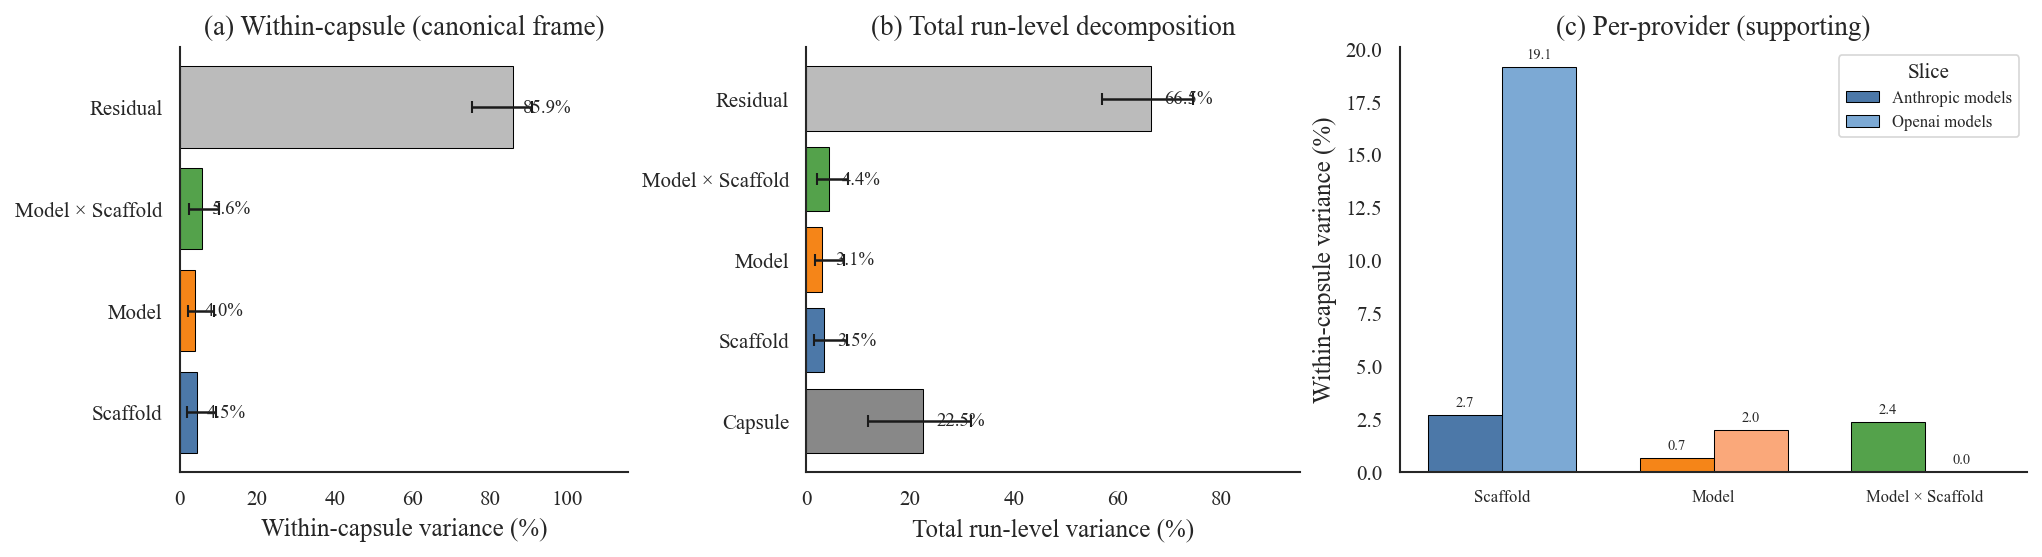

Overwrote variance_decomposition.{pdf,svg,png} with 3-panel version.


In [ ]:
prov_data = []
for prov in ["anthropic_models", "openai_models"]:
    if prov in slice_eta_within and np.isfinite(slice_eta_within[prov]["model"]):
        ev = slice_eta_within[prov]
        prov_data.append((prov.replace("_models", "").capitalize() + " models",
                          ev["scaffold"]*100, ev["model"]*100, ev["interaction"]*100))

if len(prov_data) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), constrained_layout=True,
                             gridspec_kw={"width_ratios": [1.0, 1.1, 1.4]})
    # (a) Within-capsule, full data
    labels_w = ["Scaffold", "Model", "Model × Scaffold", "Residual"]
    values_w = [eta_scaffold * 100, eta_model * 100, eta_interaction * 100, eta_residual * 100]
    los_w = [float(ci.loc[0.025, k]) * 100 for k in ["scaffold", "model", "interaction", "residual"]]
    his_w = [float(ci.loc[0.975, k]) * 100 for k in ["scaffold", "model", "interaction", "residual"]]
    xerr_w = np.array([np.maximum(0, np.asarray(values_w) - np.asarray(los_w)),
                       np.maximum(0, np.asarray(his_w) - np.asarray(values_w))])
    colors_w = ["#4C78A8", "#F58518", "#54A24B", "#BBBBBB"]
    y = np.arange(len(labels_w))
    axes[0].barh(y, values_w, xerr=xerr_w, color=colors_w, edgecolor="black", linewidth=0.5, capsize=3)
    for i, v in enumerate(values_w):
        axes[0].text(v + 2.5, i, f"{v:.1f}%", va="center", fontsize=9)
    axes[0].set_yticks(y); axes[0].set_yticklabels(labels_w)
    axes[0].set_xlabel("Within-capsule variance (%)")
    axes[0].set_xlim(0, max(his_w) * 1.25 + 2)
    axes[0].set_title("(a) Within-capsule (canonical frame)")

    # (b) Total run-level
    labels_t = ["Capsule", "Scaffold", "Model", "Model × Scaffold", "Residual"]
    values_t = [eta_total_capsule * 100, eta_total_scaffold * 100, eta_total_model * 100,
                eta_total_interaction * 100, eta_total_residual * 100]
    los_t = [float(ci_total.loc[0.025, k]) * 100 for k in ["capsule", "scaffold", "model", "interaction", "residual"]]
    his_t = [float(ci_total.loc[0.975, k]) * 100 for k in ["capsule", "scaffold", "model", "interaction", "residual"]]
    xerr_t = np.array([np.maximum(0, np.asarray(values_t) - np.asarray(los_t)),
                       np.maximum(0, np.asarray(his_t) - np.asarray(values_t))])
    colors_t = ["#888888", "#4C78A8", "#F58518", "#54A24B", "#BBBBBB"]
    y2 = np.arange(len(labels_t))
    axes[1].barh(y2, values_t, xerr=xerr_t, color=colors_t, edgecolor="black", linewidth=0.5, capsize=3)
    for i, v in enumerate(values_t):
        axes[1].text(v + 2.5, i, f"{v:.1f}%", va="center", fontsize=9)
    axes[1].set_yticks(y2); axes[1].set_yticklabels(labels_t)
    axes[1].set_xlabel("Total run-level variance (%)")
    axes[1].set_xlim(0, max(his_t) * 1.25 + 2)
    axes[1].set_title("(b) Total run-level decomposition")

    # (c) Per-model_provider — supporting evidence only
    width = 0.35
    n_prov = len(prov_data)
    x_centers = np.arange(3)
    bar_color_pairs = [["#4C78A8", "#F58518", "#54A24B"], ["#7CA9D4", "#FAA87A", "#85C277"]]
    for j, (lab, sc, md, it) in enumerate(prov_data):
        offset = (j - (n_prov - 1) / 2) * width
        axes[2].bar(x_centers + offset, [sc, md, it], width=width, label=lab,
                    edgecolor="black", linewidth=0.5,
                    color=bar_color_pairs[j % len(bar_color_pairs)])
        for k, v in enumerate([sc, md, it]):
            axes[2].text(x_centers[k] + offset, v + 0.4, f"{v:.1f}",
                         ha="center", fontsize=7)
    axes[2].set_xticks(x_centers)
    axes[2].set_xticklabels(["Scaffold", "Model", "Model × Scaffold"], fontsize=8)
    axes[2].set_ylabel("Within-capsule variance (%)")
    axes[2].legend(title="Slice", fontsize=8, loc="upper right")
    axes[2].set_title("(c) Per-provider (supporting)")

    fig.savefig(FIGDIR / "variance_decomposition.pdf")
    fig.savefig(FIGDIR / "variance_decomposition.svg")
    fig.savefig(FIGDIR / "variance_decomposition.png", dpi=300)
    plt.show()
    print("Overwrote variance_decomposition.{pdf,svg,png} with 3-panel version.")
else:
    print("Not enough provider slices fit successfully — keeping 2-panel version of variance_decomposition.{pdf,svg,png}.")


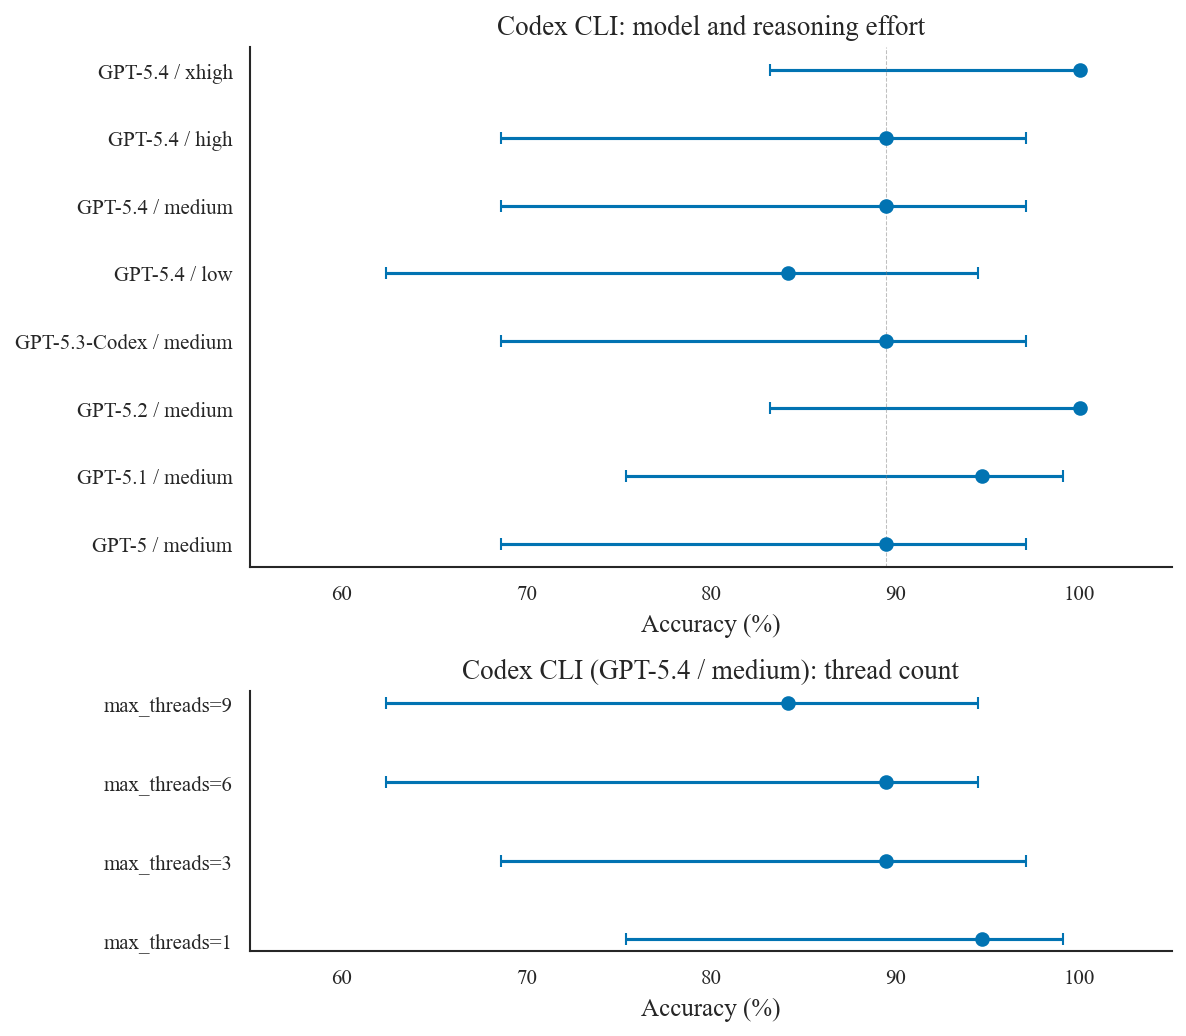

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7),
                                gridspec_kw={"height_ratios": [8, 4]})

# --- Panel 1: Model / reasoning effort ---
labels_1 = [
    "GPT-5 / medium", "GPT-5.1 / medium", "GPT-5.2 / medium",
    "GPT-5.3-Codex / medium", "GPT-5.4 / low", "GPT-5.4 / medium",
    "GPT-5.4 / high", "GPT-5.4 / xhigh",
]
acc_1 = [89.5, 94.7, 100.0, 89.5, 84.2, 89.5, 89.5, 100.0]
ci_lo_1 = [68.6, 75.4, 83.2, 68.6, 62.4, 68.6, 68.6, 83.2]
ci_hi_1 = [97.1, 99.1, 100.0, 97.1, 94.5, 97.1, 97.1, 100.0]

y1 = range(len(labels_1))
ax1.errorbar(
    acc_1, y1,
    xerr=[[a - lo for a, lo in zip(acc_1, ci_lo_1)],
          [hi - a for a, hi in zip(acc_1, ci_hi_1)]],
    fmt="o", color=SCAFFOLD_COLORS["Codex CLI"],
    capsize=3, markersize=6, linewidth=1.5,
)
ax1.set_yticks(y1)
ax1.set_yticklabels(labels_1)
ax1.set_xlim(55, 105)
ax1.set_title("Codex CLI: model and reasoning effort")
ax1.axvline(x=89.5, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

# --- Panel 2: Thread count ablation ---
labels_2 = [
    "max_threads=1", "max_threads=3",
    "max_threads=6", "max_threads=9",
]
acc_2 = [94.7, 89.5, 89.5, 84.2]
ci_lo_2 = [75.4, 68.6, 62.4, 62.4]
ci_hi_2 = [99.1, 97.1, 94.5, 94.5]

y2 = range(len(labels_2))
ax2.errorbar(
    acc_2, y2,
    xerr=[[a - lo for a, lo in zip(acc_2, ci_lo_2)],
          [hi - a for a, hi in zip(acc_2, ci_hi_2)]],
    fmt="o", color=SCAFFOLD_COLORS["Codex CLI"],
    capsize=3, markersize=6, linewidth=1.5,
)
ax2.set_yticks(y2)
ax2.set_yticklabels(labels_2)
ax2.set_xlim(55, 105)
ax2.set_title("Codex CLI (GPT-5.4 / medium): thread count")

for ax in [ax1, ax2]:
    ax.set_xlabel("Accuracy (%)")

plt.tight_layout()
plt.savefig(FIGDIR / "codex_cli_ablation.pdf", bbox_inches="tight")
plt.show()


Oracle ceiling analysis:
  Claude Opus 4.5: best single = 89.7%, oracle = 100.0%, all-wrong = 0/39
  GPT-5.4: best single = 94.9%, oracle = 100.0%, all-wrong = 0/39
  Claude Opus 4.6: best single = 97.4%, oracle = 97.4%, all-wrong = 1/39


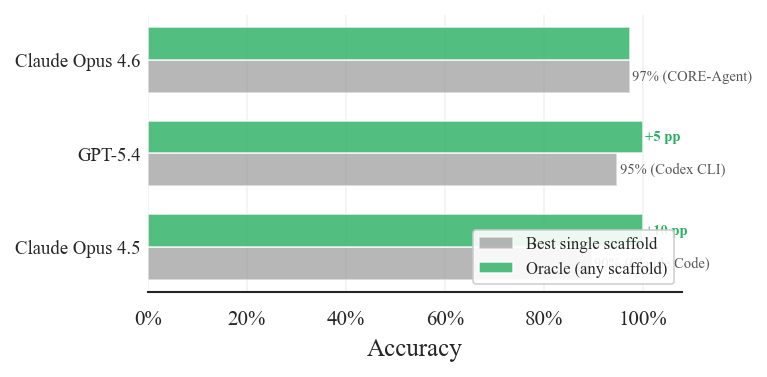

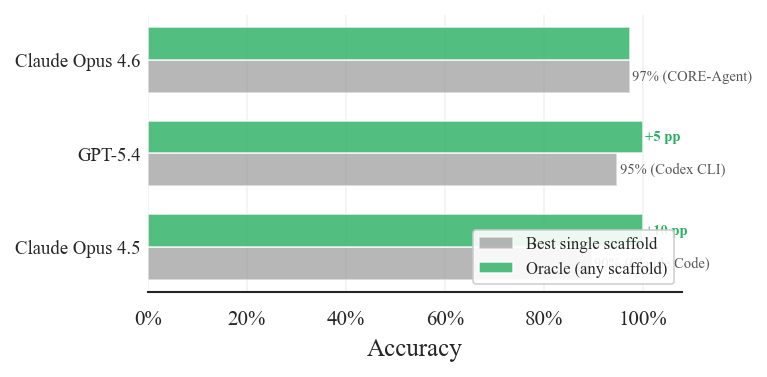

In [ ]:
multi = (
    df_canonical.groupby("model_clean")["scaffold_family"]
    .nunique()
    .loc[lambda s: s >= 2]
    .index.tolist()
)

results = []

for model in multi:
    mdf = df_canonical[df_canonical["model_clean"] == model]

    piv = mdf.pivot_table(
        index="capsule_id",
        columns="scaffold_family",
        values="accuracy",
        aggfunc="mean",
    )

    n_caps = len(piv)

    # Best single scaffold
    best_scf_acc = piv.mean().max()
    best_scf_name = piv.mean().idxmax()

    # Oracle: capsule is correct if ANY scaffold solves it
    oracle_acc = (piv.max(axis=1) >= 0.5).mean()

    # All-wrong: capsules no scaffold solves
    all_wrong = (piv.max(axis=1) < 0.5).sum()

    results.append(
        {
            "model": model,
            "display": MODEL_DISPLAY.get(model, model),
            "best_scaffold": best_scf_name,
            "best_acc": best_scf_acc,
            "oracle_acc": oracle_acc,
            "all_wrong": int(all_wrong),
            "n_caps": n_caps,
        }
    )

rdf = pd.DataFrame(results).sort_values("best_acc")

fig, ax = plt.subplots(
    figsize=(5, max(2.0, 0.8 * len(rdf))),
    constrained_layout=True,
)

y = np.arange(len(rdf))
bar_h = 0.35

ax.barh(
    y - bar_h / 2,
    rdf["best_acc"],
    bar_h,
    color="#888",
    alpha=0.6,
    edgecolor="white",
    label="Best single scaffold",
)

ax.barh(
    y + bar_h / 2,
    rdf["oracle_acc"],
    bar_h,
    color="#27ae60",
    alpha=0.8,
    edgecolor="white",
    label="Oracle (any scaffold)",
)

# Annotations
for i, (_, row) in enumerate(rdf.iterrows()):
    gap = (row["oracle_acc"] - row["best_acc"]) * 100

    if gap > 0:
        ax.text(
            row["oracle_acc"] + 0.005,
            i + bar_h / 2,
            f"+{gap:.0f} pp",
            va="center",
            fontsize=7,
            color="#27ae60",
            fontweight="bold",
        )

    ax.text(
        row["best_acc"] + 0.005,
        i - bar_h / 2,
        f"{row['best_acc']:.0%} ({row['best_scaffold']})",
        va="center",
        fontsize=7,
        color="#555",
    )

ax.set_yticks(y)
ax.set_yticklabels(rdf["display"], fontsize=9)
ax.set_xlabel("Accuracy")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlim(0, 1.08)
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
ax.grid(axis="x", alpha=0.25)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

print("\nOracle ceiling analysis:")
for _, row in rdf.iterrows():
    print(
        f"  {row['display']}: best single = {row['best_acc']:.1%}, "
        f"oracle = {row['oracle_acc']:.1%}, "
        f"all-wrong = {row['all_wrong']}/{row['n_caps']}"
    )

savefig("oracle_ceiling.pdf")
savefig("oracle_ceiling.png")
plt.show()

In [ ]:
# ── Load failure rubric results ──
FAIL_QUERY = """
SELECT
  jr.agent_run_id,
  jr.output->>'label' AS output_label,
  jr.output->>'failure_mode' AS output_failure_mode,
  jr.output->>'notes' AS output_notes,
  ar.metadata_json->>'original_agent_run_id' AS original_agent_run_id
FROM judge_results jr
JOIN agent_runs ar ON ar.id = jr.agent_run_id
WHERE jr.rubric_id = 'e2101d51-1169-408a-a565-b3a211015f40' AND jr.rubric_version = 17
ORDER BY ar.created_at DESC
"""

result_fail = client.execute_dql(COLLECTION_ID, FAIL_QUERY)
df_failure = client.dql_result_to_df_experimental(result_fail)

df_fail_merged = df_failure.merge(
    df_canonical[["agent_run_id", "capsule_id", "model_clean", "scaffold_family", "accuracy", "model_display"]],
    left_on="original_agent_run_id",
    right_on="agent_run_id",
    how="inner",
    suffixes=("_docent", "_canonical"),
)

cross_models = ["claude-opus-4-5", "claude-opus-4-6", "gpt-5.4"]

true_failures = df_fail_merged[
    (df_fail_merged["accuracy"] == 0.0)
    & (df_fail_merged["output_label"] == "match")
    & (df_fail_merged["model_clean"].isin(cross_models))
]
print(f"True failures: {len(true_failures)}")

True failures: 48


In [ ]:
# Contrastive: same model fails on one scaffold, succeeds on another
contrastive = true_failures[["capsule_id", "scaffold_family", "model_clean", "output_failure_mode", "output_notes"]].merge(
    successes[["capsule_id", "scaffold_family", "model_clean", "output_success_factor", "output_obstacle", "output_strategy"]],
    on="capsule_id",
    suffixes=("_fail", "_success"),
)
same_model = contrastive[contrastive["model_clean_fail"] == contrastive["model_clean_success"]]
print(f"\nSame-model contrastive pairs: {len(same_model)}")
print(same_model[["capsule_id", "model_clean_fail", "scaffold_family_fail", "output_failure_mode",
                   "scaffold_family_success", "output_success_factor"]].drop_duplicates().to_string(index=False))


Same-model contrastive pairs: 64
     capsule_id model_clean_fail scaffold_family_fail         output_failure_mode scaffold_family_success       output_success_factor
capsule-0851068  claude-opus-4-6          Claude Code  task_misunderstanding_spec                OpenCode       robust_error_recovery
capsule-0851068  claude-opus-4-5          Claude Code  task_misunderstanding_spec                OpenCode    creative_environment_fix
capsule-9294029          gpt-5.4             OpenCode         environment_tooling               Codex CLI       robust_error_recovery
capsule-5136217          gpt-5.4             OpenCode            max_steps_budget               Codex CLI strategic_partial_execution
capsule-8807709  claude-opus-4-6             OpenCode         code_technical_bugs              CORE-Agent       robust_error_recovery
capsule-8807709  claude-opus-4-6             OpenCode         code_technical_bugs             Claude Code       robust_error_recovery
capsule-3821950  claude-opus